<sub>
<a href='https://github.com/Gleynner'><img src='https://img.shields.io/badge/GitHub-181717?style=for-the-badge&logo=github&logoColor=white'></a> 
<a href='https://www.linkedin.com/in/gleynnerghiotto/'><img src='https://img.shields.io/badge/LinkedIn-0077B5?style=for-the-badge&logo=linkedin&logoColor=white'></a> 
<a href='https://github.com/Gleynner/DataScience'><img src='https://img.shields.io/badge/Portfolio-4285F4?style=for-the-badge&logo=googlechrome&logoColor=white'></a>
</sub>

📂 Projeto | Data Science | By Gleynner Ghiotto

---

# 💳 Análise de Risco de Crédito

A análise de risco de crédito desempenha papel fundamental no setor financeiro, auxiliando instituições na tomada de decisão sobre concessão de crédito e mitigação de perdas associadas à inadimplência. Em um cenário econômico desafiador, marcado pelo aumento do endividamento das famílias brasileiras, restrição de crédito e elevação do risco de inadimplência, torna-se cada vez mais importante o desenvolvimento de soluções analíticas capazes de identificar clientes com maior probabilidade de default (isto é, quando um cliente deixa de cumprir sua obrigação financeira - inadimplentes) de forma eficiente e operacionalmente viável.

Nesse contexto, instituições financeiras e fintechs buscam utilizar modelos estatísticos e técnicas de Machine Learning para apoiar decisões mais assertivas de concessão de crédito, reduzindo perdas financeiras, preservando a qualidade da carteira e equilibrando crescimento sustentável com controle de risco.

A capacidade de antecipar comportamentos de inadimplência tornou-se um diferencial estratégico, permitindo que as instituições ajustem políticas de crédito, limites, taxas e estratégias de mitigação de risco de acordo com o perfil de cada cliente.



## 🎯 Objetivo do Projeto

- O objetivo deste projeto é desenvolver um modelo de Machine Learning capaz de prever a probabilidade de inadimplência de clientes a partir de informações financeiras, cadastrais e comportamentais.


<p align="center">
  <img src="assets/Score-de-credito.png" width="800">
</p>


Para alcançar o objetivo proposto, será desenvolvido um projeto contemplando as etapas de análise exploratória, tratamento e preparação dos dados, engenharia de atributos, seleção de variáveis, balanceamento de classes, otimização de hiperparâmetros e ajuste de thresholds, buscando construir modelos robustos, interpretáveis e aderentes a cenários reais de análise de risco de crédito.

## 📂 Obtenção dos Dados

Os dados deste Projeto de Data Science originam-se de uma competição promovida pela Startup Nubank, visando identificar talentos para possível contratação na Fintech.

### Importação das bibliotecas e dependências

In [1]:
# Bibliotecas básicas
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Divisão de dados e validação
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

# Pré-processamento
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    PowerTransformer,
    OneHotEncoder
)

# Seleção de variáveis
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

# Pipelines
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# Balanceamento de classes
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# Métricas de avaliação
from sklearn.metrics import (
    recall_score,
    precision_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    make_scorer
)

# Modelos de Machine Learning
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
    ExtraTreesClassifier
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Otimização de hiperparâmetros
import optuna


# Configurações

# Setando o pandas para exibir todas as colunas do data frame
pd.options.display.max_columns = None
# Definir que o Pandas exiba números de ponto flutuante com duas casas decimais
pd.set_option('display.float_format', '{:.2f}'.format)


# 1. Importação de dados e entendimento inicial

In [2]:
# Importando os dados
df = pd.read_csv('acquisition_train.csv')

### Dimensões do dataset

In [3]:
print(f'Número de linhas: {df.shape[0]}')
print(f'Número de colunas: {df.shape[1]}')

Número de linhas: 45000
Número de colunas: 43


### Dicionário de dados

`ids:` identificador único e anônimo do cliente.    <br> 
`target_default:` variável alvo (booleana). Indica se o cliente ficou inadimplente (True) ou não (False).          
`score_1 e score_2:` score de crédito categórico.     <br> 
`score_3 e score_6:` score de crédito numérico.  <br> 
`risk_rate:` taxa de risco atribuída ao cliente.     <br>
`last_amount_borrowed:` valor do último empréstimo solicitado pelo cliente.     <br>
`last_borrowed_in_months:` número de meses desde que o último empréstimo foi solicitado.     <br> 
`credit_limit:` limite de crédito do cliente.     <br> 
`reason:` motivo declarado para a solicitação do crédito.    <br>
`income:` renda mensal (baseada em histórico).     <br>
`facebook_profile:` indica se o cliente possui perfil no Facebook vinculado (True/False).     <br>
`state:` estado de residência do cliente.     <br>
`zip:` código postal ou região de residência.    <br> 
`channel:` canal por onde o cliente chegou à fintech.     <br>
`job_name:` nome do cargo/profissão.     <br>
`real_state:` status do imóvel do cliente.     <br>
`ok_since:` tempo (em meses) desde que o cliente está "em dia".     <br>
`n_bankruptcies:` número de falências registradas no histórico do cliente.     <br> 
`n_defaulted_loans:` número de empréstimos em que houve inadimplência.     <br> 
`n_accounts:` número de contas bancárias abertas.     <br> 
`n_issues:` número de problemas relatados pelo cliente.     <br>
`application_time_applied:` horário em que a proposta foi aplicada.     <br>
`application_time_in_funnel:` tempo gasto no funil de aplicação (segundos).     <br>
`email:` provedor de e-mail utilizado.     <br>
`external_data_provider_credit_checks_last_2_year:` consultas ao CPF nos últimos 2 anos.     <br> 
`external_data_provider_credit_checks_last_month:` consultas ao CPF no último mês.     <br> 
`external_data_provider_credit_checks_last_year:` consultas ao CPF no último ano.     <br>
`external_data_provider_email_seen_before:` indica se o e-mail já foi visto em bureaus de crédito.     <br>
`external_data_provider_first_name:` primeiro nome do cliente (anonimizado/limpo).     <br>
`external_data_provider_fraud_score:` score de fraude de provedor externo.     <br>
`lat_lon:` Latitude e Longitude da localização.     <br>
`marketing_channel:` canal de marketing pelo qual o cliente foi adquirido.     <br>
`profile_phone_number:` número de telefone do cliente.     <br> 
`reported_income:` renda mensal informada pelo próprio cliente no momento do cadastro.     <br> 
`shipping_state:` estado para envio do cartão.     <br>
`shipping_zip_code:` código postal para o envio do cartão.     <br>
`profile_tags:` tags associadas ao perfil do cliente (formato dicionário/JSON).     <br>
`user_agent:` informações do navegador/dispositivo usado.     <br>
`target_fraud:` variável alvo para modelos de fraude.     <br>

# 2. Análise Exploratória de Dados

A Análise Exploratória de Dados (EDA — Exploratory Data Analysis) é a etapa inicial de investigação de um conjunto de dados, com o objetivo de compreender sua estrutura, identificar padrões, detectar inconsistências, valores ausentes, outliers e relações entre variáveis.

Seu principal objetivo é gerar entendimento sobre os dados antes da modelagem ou tomada de decisão, apoiando a escolha de técnicas estatísticas e algoritmos mais adequados.

Visualizar as primeiras observações da base e verificar a estrutura inicial das variáveis disponíveis.

In [4]:
# Visualizar as 5 primeiras linhas
df.head()

,ids,target_default,score_1,score_2,score_3,score_4,score_5,score_6,risk_rate,last_amount_borrowed,last_borrowed_in_months,credit_limit,reason,income,facebook_profile,state,zip,channel,job_name,real_state,ok_since,n_bankruptcies,n_defaulted_loans,n_accounts,n_issues,application_time_applied,application_time_in_funnel,email,external_data_provider_credit_checks_last_2_year,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_year,external_data_provider_email_seen_before,external_data_provider_first_name,external_data_provider_fraud_score,lat_lon,marketing_channel,profile_phone_number,reported_income,shipping_state,shipping_zip_code,profile_tags,user_agent,target_fraud
0,343b7e7b-2cf8-e508-b8fd-0a0285af30aa,False,1Rk8w4Ucd5yR3KcqZzLdow==,IOVu8au3ISbo6+zmfnYwMg==,350.00,101.80,0.26,108.43,0.40,25033.92,36.00,0.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,65014.12,True,sjJbkqJS7cXalHLBFA+EOQ==,Ernn+uVXCMq/6ARrBCcd+A==,NCqL3QBx0pscDnx3ixKwXg==,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,N5/CE7lSkAfB04hVFFwllw==,NaN,0.00,0.00,18.00,18.00,07:52:34,444,outlook.com,NaN,2,0.00,51.00,leidelaura,645,"(-29.151545708122246, -51.1386461804385)",Invite-email,514-9840782,57849.00,BR-MT,17528,"{'tags': ['n19', 'n8']}",Mozilla/5.0 (Linux; Android 6.0.1; SGP771 Buil...,NaN
1,bc2c7502-bbad-0f8c-39c3-94e881967124,False,DGCQep2AE5QRkNCshIAlFQ==,SaamrHMo23l/3TwXOWgVzw==,370.00,97.06,0.94,92.00,0.24,NaN,NaN,39726.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,100018.91,False,xsd3ZdsI3356I3xMxZeiqQ==,rlWIXTBO+VOa34+SpGyhlQ==,NCqL3QBx0pscDnx3ixKwXg==,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,N5/CE7lSkAfB04hVFFwllw==,50.00,0.00,0.00,14.00,14.00,02:34:29,346,gmail.com,0.00,1,0.00,17.00,diocezio,243,"(-19.687710705798963, -47.94151536525154)",Radio-commercial,251-3659293,4902.00,BR-RS,40933,"{'tags': ['n6', 'n7', 'nim']}",Mozilla/5.0 (Linux; Android 5.0.2; SAMSUNG SM-...,NaN
2,669630dd-2e6a-0396-84bf-455e5009c922,True,DGCQep2AE5QRkNCshIAlFQ==,Fv28Bz0YRTVAT5kl1bAV6g==,360.00,100.03,0.35,112.89,0.29,7207.92,36.00,NaN,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,65023.65,NaN,Ygq6MsM98oC8yceExr69Ig==,PjTIDfJsK0DKL9fO7vuW2g==,NCqL3QBx0pscDnx3ixKwXg==,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,n+xK9CfX0bCn77lClTWviw==,NaN,0.00,0.00,10.00,NaN,00:60:02,6,gmail.com,NaN,2,NaN,9.00,veralucia,65,"(-28.748023890412284, -51.867279334353995)",Waiting-list,230-6097993,163679.00,BR-RR,50985,"{'tags': ['n0', 'n17', 'nim', 'da']}",Mozilla/5.0 (Linux; Android 6.0.1; SGP771 Buil...,NaN
3,d235609e-b6cb-0ccc-a329-d4f12e7ebdc1,False,1Rk8w4Ucd5yR3KcqZzLdow==,dCm9hFKfdRm7ej3jW+gyxw==,510.00,101.60,0.99,94.90,0.32,NaN,NaN,54591.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,68830.01,False,KET/Pmr6rHp1RJ/P9ymztw==,Cc/kWDLQH3dpHv5HU+pLVA==,NCqL3QBx0pscDnx3ixKwXg==,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiE56f...,n+xK9CfX0bCn77lClTWviw==,NaN,1.00,0.00,19.00,19.00,11:20:49,406,spgov.com,NaN,3,NaN,38.00,venice,815,"(-17.520650158450454, -39.75801139933186)",Waiting-list,261-3543751,1086.00,BR-RN,37825,{'tags': ['n4']},Mozilla/5.0 (Linux; Android 6.0; HTC One X10 B...,NaN
4,9e0eb880-e8f4-3faa-67d8-f5cdd2b3932b,False,8k8UDR4Yx0qasAjkGrUZLw==,+CxEO4w7jv3QPI/BQbyqAA==,500.00,98.47,0.53,118.13,0.18,NaN,NaN,NaN,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,60011.29,True,xsd3ZdsI3356I3xMxZeiqQ==,i036nmJ7rfxo+3EvCD7Jnw==,NCqL3QBx0pscDnx3ixKwXg==,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,n+xK9CfX0bCn77lClTWviw==,NaN,0.00,0.00,11.00,NaN,13:39:03,240,gmail.com,0.00,2,1.00,46.00,darzisa,320,"(-16.574259446978008, -39.90990074785962)",Invite-email,102-3660162,198618.00,BR-MT,52827,"{'tags': ['pro+aty', 'n19', 'da', 'b19']}",Mozilla/5.0 (Linux; Android 7.0; Pixel C Build...,NaN


A partir da visualização acima, podemos fazer algumas observações iniciais:

- Existem diversas variáveis com as informações anonimizadas.
- A variável `ids` é o identificador exclusivo de cada cliente.
- A variável `target_default` é a variável alvo, e indica se o cliente ficou inadimplente (True) ou não (False).
- Dentre as pontuações de crédito, `score_1` e `score_2` são strings codificadas e, `score_3` a `score_6` são numéricas.
- A variável `target_fraud` é a variável alvo para modelos de fraude.



In [5]:
# Imprimir informações das variáveis
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 43 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   ids                                               45000 non-null  object 
 1   target_default                                    41741 non-null  object 
 2   score_1                                           44438 non-null  object 
 3   score_2                                           44438 non-null  object 
 4   score_3                                           44438 non-null  float64
 5   score_4                                           45000 non-null  float64
 6   score_5                                           45000 non-null  float64
 7   score_6                                           45000 non-null  float64
 8   risk_rate                                         44438 non-null  float64
 9   last_amount_borro

Observa-se que os tipos das variáveis encontram-se, em sua maioria, consistentes com a natureza dos dados apresentados. No entanto, algumas features demandarão etapas adicionais de transformação para possibilitar análises mais aprofundadas, como é o caso da variável `application_time_applied`, que será convertida para um formato temporal apropriado. Observa-se ainda a presença de valores ausentes em algumas variáveis.

Abaixo vamos fazer uma investigação mais detalhada sobre a distribuição dos dados faltantes.

In [6]:
# Função para analisar os dados faltantes e únicos
def analyze_missing_and_unique(df):

    type_var = df.dtypes
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    unique_count = df.nunique()
    
    result = pd.DataFrame({
        'Type' : type_var,
        'Missing Count': missing_count,
        'Missing %': missing_percent,
        'Unique Count': unique_count
    })
    
    result = result.sort_values(by='Missing Count', ascending=False)
    
    return result

In [7]:
# Analisar os dados faltantes e únicos
analyze_missing_and_unique(df)

,Type,Missing Count,Missing %,Unique Count
target_fraud,object,43478,96.62,2
last_borrowed_in_months,float64,29956,66.57,2
last_amount_borrowed,float64,29956,66.57,14325
ok_since,float64,26545,58.99,100
external_data_provider_credit_checks_last_2_year,float64,22628,50.28,1
external_data_provider_credit_checks_last_year,float64,15124,33.61,2
credit_limit,float64,13800,30.67,20928
n_issues,float64,11544,25.65,44
facebook_profile,object,4458,9.91,2
marketing_channel,object,3578,7.95,9


A análise inicial revelou a presença significativa de valores ausentes em diversas variáveis, o que é um ponto crítico para qualquer modelagem preditiva. Algumas variávels apresentam um percentual muito elevado de dados faltantes, como `target_fraud` (96,6%), `last_borrowed_in_months` e `last_amount_borrowed` (66,6%), e `ok_since` (59%), indicando que grande parte das informações históricas de comportamento de crédito não estão disponíveis para todos os clientes.

Adicionalemente, variáveis cadastrais e financeiras, como `facebook_profile`, `job_name`, `credit_limit` e `n_issues`, apresentam níveis moderados de ausência, variando entre 7% e 30%. Também foram identificadas features com valores ausentes residuais (< 2%), com impacto potencialmente reduzido no processo analítico.


Na sequência, será realizada a verificação de registros duplicados no dataset

In [8]:
# Verificar dados duplicados
if df.duplicated().sum() == 0:
    print('Não existem dados duplicados')
else:
    print(f'Existem {df.duplicated().sum()} dados duplicados.')

Não existem dados duplicados


## 2.1. Categorizar os grupos de variáveis


Em etapas posteriores, será conduzida uma análise mais aprofundada para avaliar a relevância das variáveis e definir estratégias adequadas de tratamento e imputação dos dados faltantes e discrepantes. Considerando a elevada quantidade de features disponíveis, as variáveis foram categorizadas em grupos específicos, com o objetivo de estruturar a análise de forma mais organizada, consistente e interpretável.

### Grupo 1 - Variáveis Alvo (Targets)

- Features: `target_default`, `target_fraud`.

In [9]:
# Definir as variáveis do grupo 1
var_g1 = ['target_default', 'target_fraud']

# Visualizar as 5 primeiras linhas das variáveis do grupo 1
df[var_g1].head()

,target_default,target_fraud
0,False,NaN
1,False,NaN
2,True,NaN
3,False,NaN
4,False,NaN


In [10]:
# Analisar os dados faltantes e únicos das variáveis do grupo 1
analyze_missing_and_unique(df[var_g1])

,Type,Missing Count,Missing %,Unique Count
target_fraud,object,43478,96.62,2
target_default,object,3259,7.24,2


Nota-se que a variável alvo para modelos de fraude possui quase 97% dos registros faltantes, enquanto da variável que identifica os clientes inadimplentes tem apenas 7%. Na sequência vamos analisar o balanceamento da variável `target_default`, que é o alvo de nossa análise.

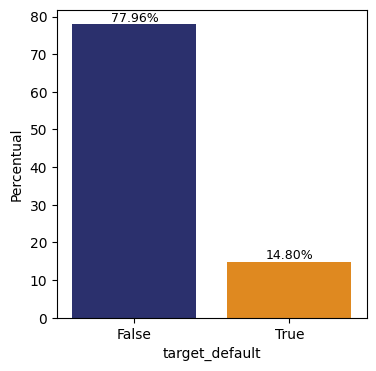

In [11]:
# Calcular a proporção de cada classe na variável target_default
prop_target = df['target_default'].value_counts(normalize=True, dropna=False).mul(100).to_frame(name='percentual')

# Configurar a paleta de cores para o gráfico
paleta = {False: '#202678',
         True: '#FF8C00'}

plt.figure(figsize = (4, 4))
# Criar o gráfico de barras
ax = sns.barplot(data = prop_target, x = prop_target.index, y = 'percentual', 
            hue = prop_target.index, legend = False, palette = paleta)

# Adiciona os valores nas barras
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:.2f}%',
                (p.get_x() + p.get_width()/2, altura),
                ha='center', va='bottom',
                fontsize=9)

plt.ylabel('Percentual')
plt.show()

A variável alvo pode assumir os valores `True`, que representa os clientes inadiplentes e, `False`,  que caracteriza os clientes adimplentes (que cumprem com suas obrigações financeiras). Contudo, temos ainda os valores `nan`, assumindo que não se sabe se o cliente foi inadimplente ou um bom pagador. Observa-se ainda, uma variável resposta é desbalanceada (isto é, proporções significativamente diferentes entre as classes alvo) com predominância da classe `False`, representando 77,96% dos dados.

Do ponto de vista estatístico e de aprendizado de máquina, conjuntos de dados desbalanceados podem levar alguns algoritmos a favorecer a classe majoritária, uma vez que a minimização do erro global tende a privilegiar a classe mais frequente.

### Grupo 2 - Perfil Cadastral e Identificação

- Features: `ids`, `external_data_provider_first_name`, `profile_phone_number`, `email`, `facebook_profile`.

In [12]:
# Definir as variáveis do grupo 2
var_g2 = ['ids','external_data_provider_first_name', 'profile_phone_number', 'email', 'facebook_profile']

# Visualizar as 5 primeiras linhas das variáveis do grupo 2
df[var_g2].head()

,ids,external_data_provider_first_name,profile_phone_number,email,facebook_profile
0,343b7e7b-2cf8-e508-b8fd-0a0285af30aa,leidelaura,514-9840782,outlook.com,True
1,bc2c7502-bbad-0f8c-39c3-94e881967124,diocezio,251-3659293,gmail.com,False
2,669630dd-2e6a-0396-84bf-455e5009c922,veralucia,230-6097993,gmail.com,NaN
3,d235609e-b6cb-0ccc-a329-d4f12e7ebdc1,venice,261-3543751,spgov.com,False
4,9e0eb880-e8f4-3faa-67d8-f5cdd2b3932b,darzisa,102-3660162,gmail.com,True


In [13]:
# Analisar os dados faltantes e únicos do grupo 2   
analyze_missing_and_unique(df[var_g2])

,Type,Missing Count,Missing %,Unique Count
facebook_profile,object,4458,9.91,2
ids,object,0,0.00,45000
external_data_provider_first_name,object,0,0.00,32886
profile_phone_number,object,0,0.00,45000
email,object,0,0.00,6


As variáveis `ids` e `profile_phone_number` possuem registros exclusivos para cada cliente, isto é, um valor diferente para cada linha de dados. A variável `external_data_provider_first_name` também possui alta cardinalidade, totalizando 32.886 valores únicos.

Na sequência, será realizada uma análise mais detalhada da variável `email`.

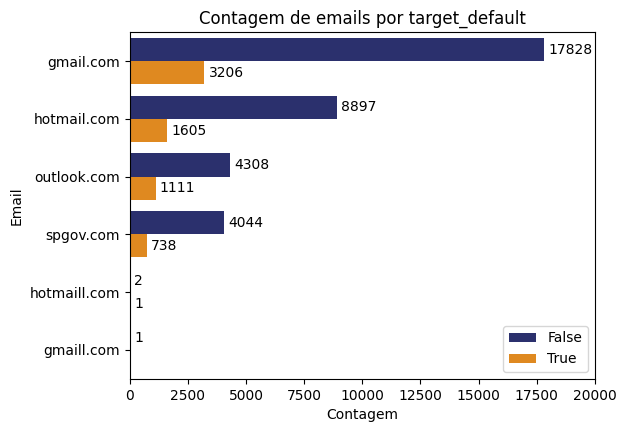

In [14]:
ordem_email = df['email'].value_counts().index

plt.figure(figsize=(6,4.5))
# Criar o gráfico de barras
ax = sns.countplot(data=df[var_g2], y='email', hue= df['target_default'], order=ordem_email, palette=paleta)

# Adiciona os rótulos
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding  = 3)

ax.legend(title=None)
ax.set_xlim((0, 20000))
plt.title('Contagem de emails por target_default')
plt.xlabel('Contagem')
plt.ylabel('Email')
plt.show()

A análise da distribuição dos domínios de e-mail entre bons clientes (False) e clientes inadimplentes (True) mostra que os principais provedores — especialmente gmail.com, hotmail.com e outlook.com — concentram a maior parte da base em ambos os grupos. Observa-se que o domínio gmail.com possui predominância significativa tanto entre clientes adimplentes quanto inadimplentes, refletindo principalmente sua ampla popularidade na base analisada, e não necessariamente uma associação direta com risco de crédito. Além disso, foram identificados com erros de digitação, como `gmaill` e `hotmaill`, indicando a necessidade de padronização dos dados.

Para concluir a análise deste grupo, será avaliada a variável `facebook_profile`.


In [15]:
# Contagem das classes de Facebook 
df['facebook_profile'].value_counts()

facebook_profile
False    24933
True     15609
Name: count, dtype: int64

In [16]:
# Analisar a relação entre facebook_profile e target_default
pd.crosstab(df['facebook_profile'], 
            df['target_default'], 
            normalize='index')

target_default,False,True
facebook_profile,,
False,0.89,0.11
True,0.76,0.24


Observa-se uma predominância de clientes sem perfil do Facebook vinculado na base analisada. Embora não seja possível inferir causalidade, identificou-se uma taxa de inadimplência relativamente superior entre os clientes que possuem perfil associado. Adicionalmente, notou-se que esta variável possui 9,91% de valores missing, aspecto que deverá ser considerado nas etapas de tratamento dos dados.

### Grupo 3 - Variáveis Socioeconômicas e Geográficas

Features: `income`, `reported_income`, `job_name`, `real_state`, `state`, `zip`, `lat_lon`, `shipping_state`, `shipping_zip_code`.

In [17]:
# Definir as variáveis do grupo 3
var_g3 = ['income', 'reported_income', 'job_name', 'real_state', 'state', 'zip', 'lat_lon', 'shipping_state', 'shipping_zip_code']

# Visualizar as 5 primeiras linhas das variáveis do grupo 3
df[var_g3].head()

,income,reported_income,job_name,real_state,state,zip,lat_lon,shipping_state,shipping_zip_code
0,65014.12,57849.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,N5/CE7lSkAfB04hVFFwllw==,sjJbkqJS7cXalHLBFA+EOQ==,Ernn+uVXCMq/6ARrBCcd+A==,"(-29.151545708122246, -51.1386461804385)",BR-MT,17528
1,100018.91,4902.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,N5/CE7lSkAfB04hVFFwllw==,xsd3ZdsI3356I3xMxZeiqQ==,rlWIXTBO+VOa34+SpGyhlQ==,"(-19.687710705798963, -47.94151536525154)",BR-RS,40933
2,65023.65,163679.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,n+xK9CfX0bCn77lClTWviw==,Ygq6MsM98oC8yceExr69Ig==,PjTIDfJsK0DKL9fO7vuW2g==,"(-28.748023890412284, -51.867279334353995)",BR-RR,50985
3,68830.01,1086.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiE56f...,n+xK9CfX0bCn77lClTWviw==,KET/Pmr6rHp1RJ/P9ymztw==,Cc/kWDLQH3dpHv5HU+pLVA==,"(-17.520650158450454, -39.75801139933186)",BR-RN,37825
4,60011.29,198618.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,n+xK9CfX0bCn77lClTWviw==,xsd3ZdsI3356I3xMxZeiqQ==,i036nmJ7rfxo+3EvCD7Jnw==,"(-16.574259446978008, -39.90990074785962)",BR-MT,52827


In [18]:
# Analisar os dados faltantes e únicos do grupo 3
analyze_missing_and_unique(df[var_g3])

,Type,Missing Count,Missing %,Unique Count
job_name,object,3336,7.41,32265
lat_lon,object,1363,3.03,22412
income,float64,562,1.25,41211
state,object,562,1.25,50
real_state,object,562,1.25,5
zip,object,562,1.25,823
reported_income,float64,0,0.00,40025
shipping_state,object,0,0.00,25
shipping_zip_code,int64,0,0.00,28263


In [19]:
# Analisar as estatísticas descritivas das variáveis numéricas do grupo 3
df[var_g3].describe().T

,count,mean,std,min,25%,50%,75%,max
income,44438.00,71607.39,51858.97,4821.18,45010.78,61266.76,86019.23,5000027.83
reported_income,45000.00,inf,NaN,403.00,50948.25,101779.00,151337.25,inf
shipping_zip_code,45000.00,33923.51,12692.41,12001.00,22937.00,33896.00,44910.00,56000.00


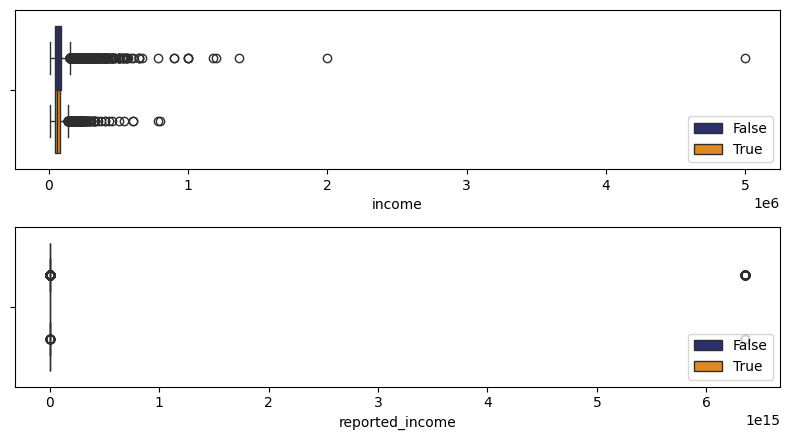

In [20]:
fig, ax = plt.subplots(2,1, figsize = (8,4.5))

# Criar os gráficos de boxplot para as variáveis income e reported_income   
sns.boxplot(data = df[var_g3], x = 'income', hue= df['target_default'], palette=paleta, ax= ax[0])
ax[0].legend(title=None, loc='lower right')

sns.boxplot(data = df[var_g3], x = 'reported_income', hue= df['target_default'], palette=paleta, ax= ax[1])
ax[1].legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()

Observa-se elevada presença de valores extremos nas variáveis `income` e `reported_income`, resultando em forte assimetria positiva nas distribuições.

Para `income`, a análise dos quartis indica concentração da maior parte dos clientes em faixas de renda moderadas, enquanto o valor máximo identificado (5.000.027) evidencia a existência de outliers relevantes. Adicionalmente, o boxplot segmentado por `target_default` demonstra significativa sobreposição entre as distribuições de clientes adimplentes e inadimplentes, sugerindo baixo poder discriminatório da variável de forma isolada.

Já a variável `reported_income` apresentou inconsistências mais severas, incluindo valores extremamente elevados, presença de registros infinitos (`Inf`) e distorções estatísticas que inviabilizam métricas como média e desvio-padrão. Também foram identificados valores mínimos incompatíveis com a realidade esperada, indicando possíveis inconsistências cadastrais ou erros de preenchimento.

Diante desse cenário, ambas as variáveis demandarão etapas adicionais de tratamento, principalmente, para controle de outliers e padronização dos dados.

A seguir, será realizada uma análise visual da distribuição das variáveis considerando apenas observações até o percentil 99, com o objetivo de reduzir o impacto de valores extremos e permitir uma avaliação mais representativa do comportamento da maior parte da base.

In [21]:
# Calcular o percentil 99 para as variáveis income e reported_income
p99_income = df['income'].quantile(0.99)
p99_reported_income = df['reported_income'].quantile(0.99)

p99_income, p99_reported_income

(np.float64(230010.3153), np.float64(199804.04))

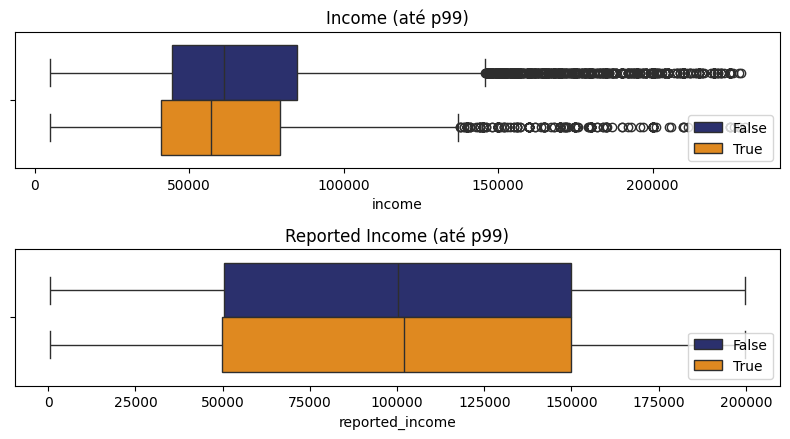

In [22]:
fig, ax = plt.subplots(2,1, figsize = (8,4.5))

# Criar os gráficos de boxplot para as variáveis income e reported_income, limitando os valores até o percentil 99
sns.boxplot(df[df['income'] <= p99_income], x = 'income', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[0])
ax[0].set_title('Income (até p99)')
ax[0].legend(title=None, loc='lower right')

sns.boxplot(df[df['reported_income'] <= p99_reported_income], x='reported_income', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[1])
ax[1].set_title('Reported Income (até p99)')
ax[1].legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()

Ao limitar a análise da variável `income` ao percentil 99, observa-se uma leve distinção entre as classes, com clientes inadimplentes concentrando-se em faixas de renda inferiores. Para a variável `reported_income`, elevada sobreposição entre as distribuições.

Na sequência, será realizada uma comparação entre razão enntre a renda mensal (`income`) e a renda declarada pelo cliente (`reported_income`), com o objetivo de avaliar o nível de consistência entre as informações reportadas.

In [23]:
# comparar a razão entre a renda mensal e a renda reportada
(df['reported_income'] / df['income']).describe()

count   44438.00
mean         inf
std          NaN
min         0.00
25%         0.72
50%         1.50
75%         2.56
max          inf
dtype: float64

Observando os quartis da distribuição da razão, verifica-se que 75% dos valores estão abaixo de 2,56. Isso indica que, para grande parte da base, a renda reportada tende a ser igual ou moderadamente superior à renda verdadeira do cliente. Apesar da concentração da maioria das observações em faixas moderadas, a distribuição apresenta valores extremamente altos (`Inf`), demonstrando inconsistência na renda reportada.

A última variável numérica deste grupo é `shipping_zip_code`, que representa o código postal do cliente.

As variáveis `job_name`, `zip` e `state` são strings de alta cardinalidade, codificadas, com 32.265, 823 e 50 valores únicos, respectivamente. A variável de status do imóvel (`real_state`) também está codificada, porém, com 5 valores únicos. Vamos verificar se existe relação entre suas categorias e a taxa de inadimplentes.

In [24]:
# Analisar a relação entre real_state e target_default  
count_real_state = df['real_state'].value_counts().reset_index()
cross_tab_real_state = pd.crosstab(
    df['real_state'], 
    df['target_default'],
    normalize='index') * 100

count_real_state.merge(cross_tab_real_state, on = 'real_state', how = 'inner').sort_values(by = 'count', ascending = False)

,real_state,count,False,True
0,N5/CE7lSkAfB04hVFFwllw==,22353,85.21,14.79
1,n+xK9CfX0bCn77lClTWviw==,18358,82.68,17.32
2,nSpvDsIsslUaX6GE6m6eQA==,3678,84.05,15.95
3,UX7AdFYgQh+VrVC5eIaU9w==,39,74.36,25.64
4,+qWF9pJpVGtTFn4vFjb/cg==,10,100.00,0.00


Observamos pequenas diferenças nas taxas de **default** entre os grupos com alta representatividade (n > 3,6k). Já as categorias com baixa frequência exibem variações mais acentuadas, porém, apresenta baixa confiabilidade devido ao tamanho amostral reduzido.


Agora vamos verificar as informações para a variável `shipping_state`.

In [25]:
# Remover o prefixo 'BR-' dos valores da coluna 'shipping_state'
df['shipping_state'] = df['shipping_state'].str.replace('BR-', '')

# Verificar os valores únicos da coluna 'shipping_state' após a remoção do prefixo
valores_unicos_shipping_state = df['shipping_state'].unique()

print('\nQuantidade de valores únicos: ', len(valores_unicos_shipping_state))


Quantidade de valores únicos:  25


In [26]:
# Analisar a relação entre shipping_state e target_default
count_state = df['shipping_state'].value_counts().reset_index()
cross_tab_state = (pd.crosstab(
    df['shipping_state'],
    df['target_default'], 
    normalize= 'index') * 100)

count_state.merge(cross_tab_state, on = 'shipping_state', how = 'inner').sort_values(by = 'count', ascending= False).T.style.hide(axis='columns').format(precision=2)

shipping_state,SP,AM,BA,GO,RR,MG,SE,DF,MA,RO,TO,PR,MS,RS,AP,PA,AC,AL,SC,PE,PB,RN,MT,CE,ES
count,6994,4037,2780,2634,1610,1527,1410,1402,1388,1371,1363,1359,1354,1352,1329,1326,1319,1318,1311,1309,1308,1307,1302,1301,1289
False,82.85,84.18,86.08,84.81,77.82,77.14,85.65,83.55,84.01,85.26,83.46,86.09,84.65,87.16,84.14,85.84,84.38,84.63,86.34,83.35,86.04,84.93,83.85,83.61,85.32
True,17.15,15.82,13.92,15.19,22.18,22.86,14.35,16.45,15.99,14.74,16.54,13.91,15.35,12.84,15.86,14.16,15.62,15.37,13.66,16.65,13.96,15.07,16.15,16.39,14.68


Acima temos uma breve ilustração da quantidade de clientes e a proporção de bons e maus pagadores considerando os 25 estados identificados na base de dados. 

A respeito do volume de clientes, o estado de São Paulo aparece no topo, com a maior concentração de clientes, apresentando uma diferença significativa em relação ao segundo colocado (AM). Um fato que chama atenção é a presença do estado do Amazonas na segunda posição, onde seria esperado um outro estado da região Sudeste ou da região Sul. Na sequência, destacam-se os estados da Bahia e de Goiás, ocupando respectivamente a terceira e quarta posições, ambos com volumes expressivos de clientes. Apesar de ser um grande mercado desse setor, aspecto que chamou a atenção foi a inexistência de dados referente ao estado do Rio de Janeiro no dataset, que tradicionalmente representa um mercado relevante para esse tipo de operação. A partir da quarta posição observa-se uma redução gradual no número de clientes entre os estados, com diferenças menos acentuadas entre eles.

Analisando a proporção de inadimplência, o estado de Minas Gerais lidera, com 22,86% dos clientes em situação de não cumprimento de suas obrigações. Roraima aparece na segunda posição, também com um percentual expressivo. A partir da terceira porsição (estado de São Paulo), observa-se uma diferença menos acentuada entre a taxa de inadimplentes dos demais estados.

### Grupo 4 - Comportamento de Crédito e Histórico

Features: `n_bankruptcies`, `n_defaulted_loans`, `n_accounts`, `n_issues`, `ok_since`, `reason`, `last_amount_borrowed`, `last_borrowed_in_months`, `credit_limit`.

In [27]:
# Definir as variáveis do grupo 4
var_g4 = ['n_bankruptcies','n_defaulted_loans','n_accounts','n_issues','ok_since','reason','last_amount_borrowed','last_borrowed_in_months','credit_limit']
# Visualizar as 5 primeiras linhas das variáveis do grupo 4                     
df[var_g4].head()

,n_bankruptcies,n_defaulted_loans,n_accounts,n_issues,ok_since,reason,last_amount_borrowed,last_borrowed_in_months,credit_limit
0,0.00,0.00,18.00,18.00,NaN,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,25033.92,36.00,0.00
1,0.00,0.00,14.00,14.00,50.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,NaN,NaN,39726.00
2,0.00,0.00,10.00,NaN,NaN,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,7207.92,36.00,NaN
3,1.00,0.00,19.00,19.00,NaN,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,NaN,NaN,54591.00
4,0.00,0.00,11.00,NaN,NaN,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,NaN,NaN,NaN


In [28]:
# Analisar os dados faltantes e únicos das variáveis do grupo 4
analyze_missing_and_unique(df[var_g4])

,Type,Missing Count,Missing %,Unique Count
last_borrowed_in_months,float64,29956,66.57,2
last_amount_borrowed,float64,29956,66.57,14325
ok_since,float64,26545,58.99,100
credit_limit,float64,13800,30.67,20928
n_issues,float64,11544,25.65,44
n_bankruptcies,float64,697,1.55,6
n_defaulted_loans,float64,574,1.28,5
reason,object,566,1.26,14874
n_accounts,float64,562,1.25,44


As variáveis `n_bankruptcies` e `n_defaulted_loans`, que representam respectivamente o número de falências registradas e a quantidade de empréstimos com histórico de inadimplência, apresentam baixa cardinalidade, com 6 e 5 valores únicos. 

Dessa forma, será realizada uma análise específica dessas features, visando avaliar sua distribuição e potencial relação com o risco de crédito.

In [29]:
tab1 = pd.crosstab(
    df['n_bankruptcies'],
    df['target_default'],
    normalize=True
) * 100

tab2 = pd.crosstab(
    df['n_defaulted_loans'],
    df['target_default'],
    normalize=True
) * 100

tab1.columns = ['False', 'True']
tab2.columns = ['False', 'True']

display(
    pd.concat(
        [tab1, tab2],
        axis=1,
        keys=['n_bankruptcies', 'n_defaulted_loans']
    )
)

n_bankruptcies       n_defaulted_loans      
              False  True             False  True
0.00          77.86 14.64             83.71 15.90
1.00           6.07  1.30              0.29  0.06
2.00           0.08  0.02              0.04  0.00
3.00           0.01  0.00              0.01  0.00
4.00           0.00  0.00               NaN   NaN
5.00           0.00  0.00              0.00  0.00

In [30]:
# Analisar as estatísticas descritivas das variáveis numéricas do grupo 4
df[var_g4].describe().T

,count,mean,std,min,25%,50%,75%,max
n_bankruptcies,44303.00,0.08,0.27,0.00,0.00,0.00,0.00,5.00
n_defaulted_loans,44426.00,0.00,0.08,0.00,0.00,0.00,0.00,5.00
n_accounts,44438.00,10.70,4.59,0.00,7.00,10.00,13.00,49.00
n_issues,33456.00,11.07,4.60,0.00,8.00,10.00,14.00,49.00
ok_since,18455.00,35.07,21.66,0.00,17.00,32.00,50.00,141.00
last_amount_borrowed,15044.00,13782.34,8077.57,1005.18,7519.50,12023.47,19220.27,35059.60
last_borrowed_in_months,15044.00,41.76,10.25,36.00,36.00,36.00,36.00,60.00
credit_limit,31200.00,34381.95,36586.98,0.00,10000.00,25647.00,47086.75,448269.00


Entre as variáveis comportamentais e de histórico financeiro, indicadores como `n_bankruptcies` e `n_defaulted_loans` apresentam médias e desvios-padrão muito próximas de zero, indicando que a maioria dos clientes da base não possui histórico de falência ou inadimplência registrada, configurando indicadores positivos. Para a primeira variável, 92,5% dos clientes possuem zero histórico de falência, enquanto, para a segunda, 99,61% dos registros válidos não apresentam ocorrências de inadimplência em empréstimos anteriores. 

As variáveis `n_accounts` (n=44.438) e `n_issues` (n=33.456) apresentam distribuições semelhantes, com medianas idênticas, iguais a 10,0 e médias próximas de 11,0. Ambas exibem uma dispersão consistente (desvio-padrão aproximadamente 4,6) e uma concentração de 50% dos dados entre os valores 7 e 14. Algo interessante, é a existência de clientes com elevado valor de contas ativas (operando um total de 49 contas).

A variável `ok_since`, que representa o tempo em que o cliente permanece adimplente. Ela apresenta média de 35 meses e mediana de 32 meses, indicando que grande parte dos clientes com informações válidas permanecem em situação regular por aproximadamente 2 a 3 anos. Observa-se ainda que 75% dos clientes mantêm histórico de adimplência por mais de 4 anos. Além disso, há registros de clientes com períodos significativamente mais longos sem inadimplência, alcançando 141 meses. Contudo, esta variável possui uma taxa elevada de dados ausentes (59%).

Na sequência vamos analisar a variável `reason`.

In [31]:
# Analisar a distribuição das classes da variável reason
df_count_reason = df['reason'].value_counts().reset_index()
df_count_reason['prop_n'] = df_count_reason['count'] / len(df) * 100

df_count_reason.head(15)

,reason,count,prop_n
0,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,4463,9.92
1,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3090,6.87
2,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,1540,3.42
3,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,1025,2.28
4,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,898,2.00
5,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,742,1.65
6,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,482,1.07
7,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,440,0.98
8,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,429,0.95
9,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,402,0.89


In [32]:
# Analisar a relação entre reason e target_default
df_cross_tab_reason = pd.crosstab(
    df['reason'], 
    df['target_default']).reset_index()
df_cross_tab_reason['prop_True'] = df_cross_tab_reason[True] / (df_cross_tab_reason[True] + df_cross_tab_reason[False]) * 100

df_cross_tab_reason.prop_True.describe()

count   14260.00
mean       15.08
std        33.98
min         0.00
25%         0.00
50%         0.00
75%         0.00
max       100.00
Name: prop_True, dtype: float64

A variável `reason` representa o motivo declarado pelo cliente para a solicitação do crédito. Podemos observar que existem motivos que são mais comuns na hora de solicitar o crédito e, que somente as 3 primeiras razões da tabela acima, correspondem a mais de 1/5 da base de dados. Nota-se ainda que, das 14260 razões existentes, pelo menos 75% delas possuem proporção de inadimplentes iguais a zero.  


Na sequência, vamos verificar as variáveis `last_amount_borrowed` e `last_borrowed_in_months`.

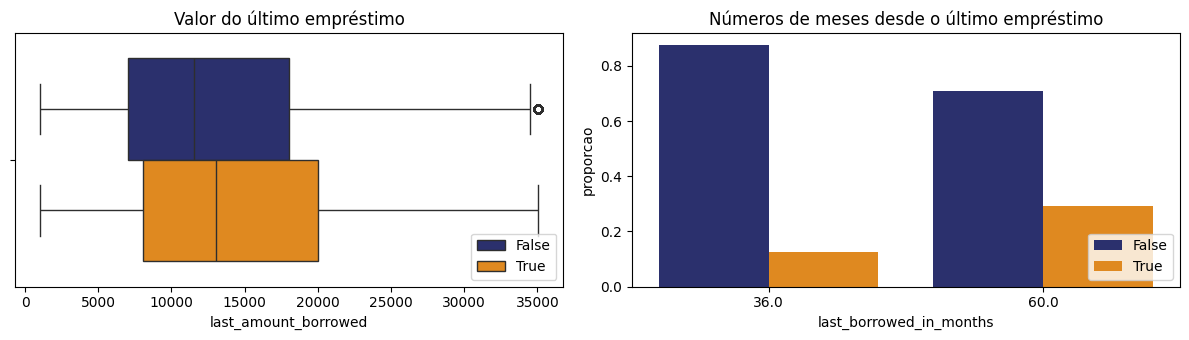

In [33]:
fig, ax = plt.subplots(1,2, figsize = (12,3.5))

# Criar o gráfico de boxplot para a variável last_amount_borrowed
sns.boxplot(df, x = 'last_amount_borrowed', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[0])
ax[0].set_title('Valor do último empréstimo')
ax[0].legend(title=None, loc='lower right')

# Analisar a relação entre last_borrowed_in_months e target_default
tab_last_borrowed_months = pd.crosstab(df['last_borrowed_in_months'],
                                       df['target_default'], 
                                      normalize = 'index')

tab_last_borrowed_months_plot = tab_last_borrowed_months.reset_index().melt(
    id_vars='last_borrowed_in_months',
    var_name='target_default',
    value_name='proporcao'
)

# Criar um gráfico de barras para a variável last_borrowed_in_months
sns.barplot(data = tab_last_borrowed_months_plot, 
            x = 'last_borrowed_in_months', 
            y = 'proporcao', 
            hue = 'target_default', palette=paleta, ax= ax[1])
ax[1].set_title('Números de meses desde o último empréstimo')
ax[1].legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()

As variáveis `last_amount_borrowed` e `last_borrowed_in_months` possuem 66,57% de registros ausentes. Ao comparar os valores dos últimos empréstimos entre clientes inadimplentes e não inadimplentes, tem-se a impressão de que os valores de empréstimos são ligeiramente maiores entre os inadimplentes, embora a diferença entre as distribuições seja relativamente pequena. Considerando o número de meses desde o último emprestimo, observa-se que clientes com empréstimos mais recentes (36 meses) apresentam maior proporção de bons pagadores, enquanto clientes com maior período sem operações de crédito (60 meses) demonstram aumento significativo na taxa de inadimplência.

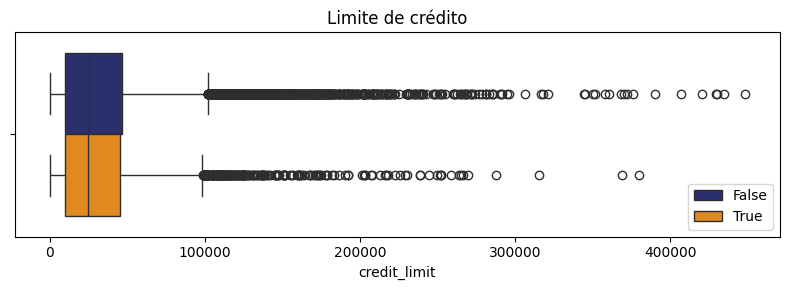

In [34]:
plt.figure(figsize = (8,3))

# Criar o gráfico de boxplot para a variável credit_limit
sns.boxplot(df, x='credit_limit', hue= 'target_default', orient = 'h', palette= paleta)
plt.title('Limite de crédito')
plt.legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()


In [35]:
# Comparar a razão entre o limite de crédito e a renda
(df['credit_limit'] / df['income']).describe()

count   31200.00
mean        0.50
std         0.50
min         0.00
25%         0.16
50%         0.40
75%         0.69
max         8.54
dtype: float64

A variável `credit_limit` apresenta média de 34.382 e desvio-padrão de 36.587, indicando elevada dispersão dos valores. A distribuição é fortemente assimétrica à direita, com presença de outliers relevantes, evidenciada pelo valor máximo (448.269) significativamente superior ao terceiro quartil.

A análise do boxplot segmentado por `target_default` demonstra elevada sobreposição entre clientes adimplentes e inadimplentes, sugerindo baixo poder discriminatório da variável de forma isolada. Adicionalmente, foram identificados registros com limite de crédito igual a zero, indicando clientes sem limite ativo.

Em relação à razão entre `credit_limit` e `income`, observa-se que 75% dos clientes possuem limite inferior a 69% da renda mensal, embora existam casos extremos em que o limite supera em até 8,54 vezes a renda observada.

Por fim, a variável apresenta aproximadamente 31% de valores ausentes, aspecto relevante para as etapas posteriores de tratamento dos dados.

### Grupo 5 - Scores e Avaliações de Risco (External Data)

Features: `score_1`, `score_2`, `score_3`, `score_4`, `score_5`, `score_6`, `risk_rate`, `external_data_provider_fraud_score`, `external_data_provider_credit_checks_last_month`,
`external_data_provider_credit_checks_last_year`, `external_data_provider_credit_checks_last_2_year`, `external_data_provider_email_seen_before`.

In [36]:
# Definir as variáveis do grupo 5
var_g5 = ['score_1','score_2', 'score_3', 'score_4', 'score_5', 'score_6', 'risk_rate', 'external_data_provider_fraud_score', 
            'external_data_provider_credit_checks_last_month', 'external_data_provider_credit_checks_last_year', 
            'external_data_provider_credit_checks_last_2_year', 'external_data_provider_email_seen_before']
# Visualizar as 5 primeiras linhas das variáveis do grupo 5
df[var_g5].head()

,score_1,score_2,score_3,score_4,score_5,score_6,risk_rate,external_data_provider_fraud_score,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_year,external_data_provider_credit_checks_last_2_year,external_data_provider_email_seen_before
0,1Rk8w4Ucd5yR3KcqZzLdow==,IOVu8au3ISbo6+zmfnYwMg==,350.00,101.80,0.26,108.43,0.40,645,2,0.00,NaN,51.00
1,DGCQep2AE5QRkNCshIAlFQ==,SaamrHMo23l/3TwXOWgVzw==,370.00,97.06,0.94,92.00,0.24,243,1,0.00,0.00,17.00
2,DGCQep2AE5QRkNCshIAlFQ==,Fv28Bz0YRTVAT5kl1bAV6g==,360.00,100.03,0.35,112.89,0.29,65,2,NaN,NaN,9.00
3,1Rk8w4Ucd5yR3KcqZzLdow==,dCm9hFKfdRm7ej3jW+gyxw==,510.00,101.60,0.99,94.90,0.32,815,3,NaN,NaN,38.00
4,8k8UDR4Yx0qasAjkGrUZLw==,+CxEO4w7jv3QPI/BQbyqAA==,500.00,98.47,0.53,118.13,0.18,320,2,1.00,0.00,46.00


In [37]:
# Analisar os dados faltantes e únicos das variáveis do grupo 5
analyze_missing_and_unique(df[var_g5])

,Type,Missing Count,Missing %,Unique Count
external_data_provider_credit_checks_last_2_year,float64,22628,50.28,1
external_data_provider_credit_checks_last_year,float64,15124,33.61,2
external_data_provider_email_seen_before,float64,2233,4.96,62
score_1,object,562,1.25,7
score_2,object,562,1.25,35
score_3,float64,562,1.25,88
risk_rate,float64,562,1.25,82
score_4,float64,0,0.00,45000
external_data_provider_fraud_score,int64,0,0.00,1001
score_6,float64,0,0.00,45000


Neste grupo, a análise será iniciada pela variável `score_1`, que apresenta 7 categorias anônimas distintas.

In [38]:
# Analisar a relação entre score_1 e target_default
count_score_1 = df['score_1'].value_counts().reset_index()
cross_tab_score_1 = pd.crosstab(
    df['score_1'], 
    df['target_default'], 
    normalize='index')

count_score_1.merge(cross_tab_score_1, on = 'score_1', how = 'inner').sort_values(by = True, ascending = False)

,score_1,count,False,True
6,fyrlulOiZ+5hoFqLa6UbDQ==,300,0.55,0.45
5,smzX0nxh5QlePvtVf6EAeg==,1307,0.61,0.39
4,e4NYDor1NOw6XKGE60AWFw==,3015,0.70,0.30
3,8k8UDR4Yx0qasAjkGrUZLw==,6458,0.77,0.23
1,1Rk8w4Ucd5yR3KcqZzLdow==,11376,0.82,0.18
0,DGCQep2AE5QRkNCshIAlFQ==,14523,0.88,0.12
2,4DLlLW62jReXaqbPaHp1vQ==,7459,0.94,0.06


A variável `score_1` apresenta categorias com taxas de inadimplência variando desde 6% até 45%, indicando boa capacidade discriminatória em relação a **default**. Apesar de algumas categorias possuírem menor volume amostral — o que pode impactar a estabilidade estatística — o comportamento geral sugere que a variável apresenta boa capacidade preditiva.


Na sequência, será analisada a variável `score_2`, outro indicador anonimizado de score de crédito.

In [39]:
# Analisar a relação entre score_2 e target_default
count_score_2 = df['score_2'].value_counts().reset_index()
cross_tab_score_2 = pd.crosstab(
    df['score_2'], 
    df['target_default'], 
    normalize='index')

merge_score_2 = count_score_2.merge(cross_tab_score_2, on = 'score_2', how = 'inner')
merge_score_2.sort_values(by = True, ascending = False).head(15)

,score_2,count,False,True
30,wjdj2vxjWoDsEIk0l09ynw==,120,0.46,0.54
34,5/uMrqKj3OL/Xk5OrGx9fg==,15,0.50,0.50
29,6J1ZMTzN5GKHXnhM4J1JbA==,147,0.55,0.45
32,55UK234RR1d7HIWJjmq9tw==,55,0.58,0.42
27,vJyc9xom9v7hwFMPTIpmKw==,278,0.60,0.40
31,+2hzpeP1RWr8PEvL1WTUdw==,82,0.62,0.38
26,tHpS8e9F8d9zg3iOQM9tsA==,315,0.62,0.38
25,bopP0NxW3+r8tn9xIHTaOw==,361,0.62,0.38
28,O4i7FxcROACMVTCgI0WXuA==,206,0.62,0.38
23,cdpgyOyZS04uXerMNu7uCw==,540,0.67,0.33


In [40]:
# Analisar as estatísticas descritivas da variável score_2 para os clientes que deram default
merge_score_2[True].describe()

count   35.00
mean     0.25
std      0.14
min      0.03
25%      0.14
50%      0.24
75%      0.35
max      0.54
Name: True, dtype: float64

A variável `score_2` demonstra boa capacidade discriminatória em relação à inadimplência, apresentando taxas que variam de 3% a 54% entre suas categorias. No entanto, observa-se que algumas das categorias com maiores taxas de inadimplência possuem baixo volume amostral, o que pode comprometer a robustez e a estabilidade dessas estimativas.

Adicionalmente, há categorias com diferenças pouco expressivas na taxa de **default**, bem como grupos com proporções bastante semelhantes entre si. Esse comportamento sugere a possibilidade de realizar agrupamentos (binning) entre categorias com perfis similares, visando reduzir a variabilidade, aumentar a representatividade amostral e melhorar a capacidade preditiva da variável.


Vamos dar sequência analisando as variáveis `score_3`, `score_4`, `score_5` e `score_6`.

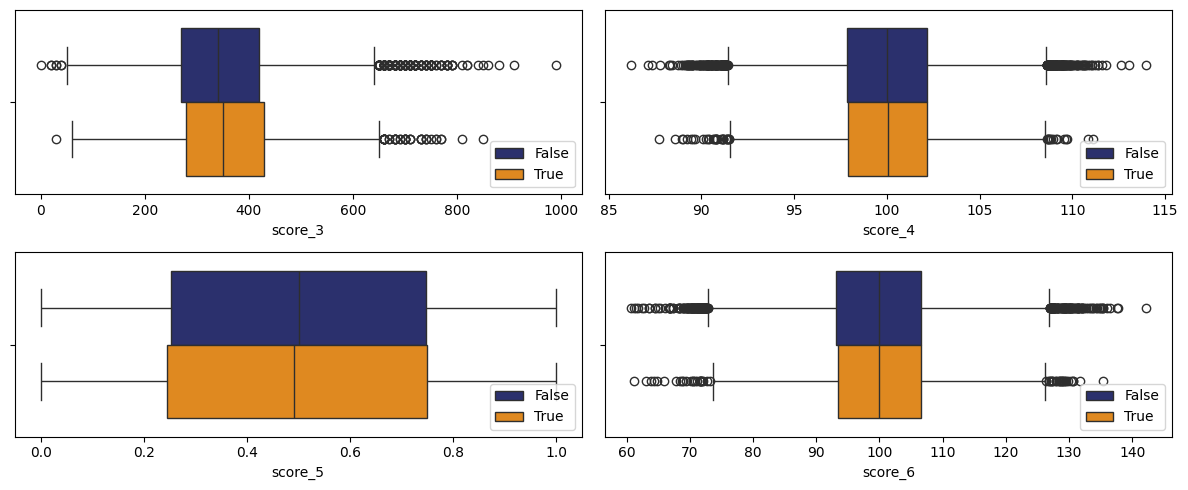

In [41]:
fig, ax = plt.subplots(2,2, figsize = (12,5))

# Criar os gráficos de boxplot para as variáveis score_3, score_4, score_5 e score_6
sns.boxplot(df, x = 'score_3', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[0,0])
ax[0,0].legend(title=None, loc='lower right')

sns.boxplot(df, x = 'score_4', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[0,1])
ax[0,1].legend(title=None, loc='lower right')

sns.boxplot(df, x = 'score_5', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[1,0])
ax[1,0].legend(title=None, loc='lower right')

sns.boxplot(df, x = 'score_6', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[1,1])
ax[1,1].legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()

A análise dos boxplots dos scores (`score_3`, `score_4`, `score_5` e `score_6`) mostra que as distribuições entre bons clientes (False) e clientes inadimplentes (True) são bastante semelhantes, com forte sobreposição entre medianas, quartis e dispersões. Esse comportamento sugere que, individualmente, essas variáveis possuem baixo poder discriminatório para separar claramente os grupos de risco. Apesar disso, observa-se presença significativa de outliers em alguns scores, principalmente em `score_3`, `score_4` e `score_6`, indicando possível existência de perfis extremos que podem carregar informação relevante para modelos preditivos.



Ainda avaliando os Scores e Indicadores de Riscos, vamos verificar as variáveis `risk_rate` e `external_data_provider_fraud_score`.

In [42]:
# Analisar as estatísticas descritivas das variáveis risk_rate e external_data_provider_fraud_score
df[['risk_rate','external_data_provider_fraud_score']].describe().T

,count,mean,std,min,25%,50%,75%,max
risk_rate,44438.00,0.30,0.10,0.00,0.22,0.29,0.36,0.90
external_data_provider_fraud_score,45000.00,500.40,287.97,0.00,252.00,503.00,747.00,1000.00


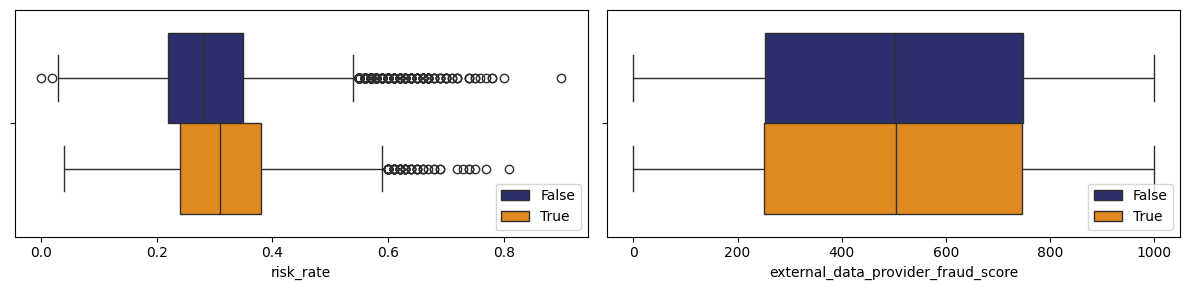

In [43]:
fig, ax = plt.subplots(1,2, figsize = (12,3))

# Criar os gráficos de boxplot para as variáveis risk_rate e external_data_provider_fraud_score
sns.boxplot(df, x = 'risk_rate', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[0])
ax[0].legend(title=None, loc='lower right')

sns.boxplot(df, x = 'external_data_provider_fraud_score', hue= 'target_default', orient = 'h', palette= paleta, ax= ax[1])
ax[1].legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()

Observando a taxa de risco atribuída ao cliente (`risk_rate`) e a variável de score de fraude fornecida por provedor externo (`external_data_provider_fraud_score`), nota-se certa similaridade de escalas com as variáveis `score_5` e `score_3`, respectivamente, podendo ser features da mesma natureza.  

Na variável `risk_rate`, observa-se uma leve diferença entre as distribuições, com clientes inadimplentes apresentando mediana discretamente superior e maior concentração em faixas de risco mais elevadas, sugerindo potencial preditivo moderado para identificação de inadimplência. Além disso, a presença de outliers em ambos os grupos pode indicar perfis específicos de maior risco que merecem investigação adicional.

Por outro lado, a variável `external_data_provider_fraud_score` apresenta distribuições praticamente idênticas entre as classes, com forte sobreposição entre medianas, quartis e dispersão dos dados. Esse comportamento sugere baixo poder discriminatório isolado para separação entre bons e maus clientes.

As demais variáveis serão analisadas a seguir:

In [44]:
df[['external_data_provider_credit_checks_last_month', 'external_data_provider_credit_checks_last_year', 
       'external_data_provider_credit_checks_last_2_year', 'external_data_provider_email_seen_before']].head()

,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_year,external_data_provider_credit_checks_last_2_year,external_data_provider_email_seen_before
0,2,0.00,NaN,51.00
1,1,0.00,0.00,17.00
2,2,NaN,NaN,9.00
3,3,NaN,NaN,38.00
4,2,1.00,0.00,46.00


In [45]:
# Analisar as estatísticas descritivas
df[['external_data_provider_credit_checks_last_month', 'external_data_provider_credit_checks_last_year', 
       'external_data_provider_credit_checks_last_2_year', 'external_data_provider_email_seen_before']].describe().T

,count,mean,std,min,25%,50%,75%,max
external_data_provider_credit_checks_last_month,45000.00,1.50,1.11,0.00,1.00,2.00,2.00,3.00
external_data_provider_credit_checks_last_year,29876.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
external_data_provider_credit_checks_last_2_year,22372.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
external_data_provider_email_seen_before,42767.00,12.53,126.53,-999.00,11.00,27.00,43.00,59.00


A variável `external_data_provider_credit_checks_last_2_year` apresenta valor constante em todos os registros da base, resultando em variância nula e ausência de capacidade discriminatória em relação à variável resposta.

Já a feature `external_data_provider_email_seen_before` contém valores mínimos iguais a `-999`, indicando a possível utilização de códigos especiais para representar dados ausentes ou indisponíveis. Essa inconsistência impacta diretamente as estatísticas descritivas da variável, provocando distorções na média e inflando o desvio-padrão.

In [46]:
# Analisar a relação entre external_data_provider_credit_checks_last_year e target_default
pd.crosstab(
    df['external_data_provider_credit_checks_last_year'], 
    df['target_default'], 
    normalize='index')

target_default,False,True
external_data_provider_credit_checks_last_year,,
0.00,0.85,0.15
1.00,0.84,0.16


A variável `external_data_provider_credit_checks_last_year` apresenta taxas de inadimplência semelhantes entre os grupos analisados. Essa pequena diferença indica fraca associação com a variável alvo, sugerindo baixo poder preditivo. Além disso, possui 33,61% de valores ausentes.

In [47]:
# Analisar a relação entre external_data_provider_credit_checks_last_month e target_default
count_checks_last_month = df['external_data_provider_credit_checks_last_month'].value_counts().reset_index()
tab_checks_last_month = pd.crosstab(
    df['external_data_provider_credit_checks_last_month'],
    df['target_default'],
    normalize='index')

count_checks_last_month.merge(tab_checks_last_month, 
                              on = 'external_data_provider_credit_checks_last_month', 
                              how = 'inner').sort_values(by = 'count', ascending = False)


,external_data_provider_credit_checks_last_month,count,False,True
0,2,11451,0.85,0.15
1,1,11205,0.84,0.16
2,0,11197,0.84,0.16
3,3,11147,0.83,0.17


A variável `external_data_provider_credit_checks_last_month` apresenta distribuição relativamente equilibrada entre suas categorias. Entretanto, as diferenças observadas nas taxas de inadimplência são pouco expressivas, sugerindo baixo poder discriminatório quando analisada de forma isolada.

### Grupo 6 - Comportamento de Aquisição e Digital

Features: `channel`, `marketing_channel`, `application_time_applied`, `application_time_in_funnel`, `user_agent`, `profile_tags`.

In [48]:
# Definir as variáveis do grupo 6
var_g6 = ['channel', 'marketing_channel','application_time_applied', 'application_time_in_funnel', 'user_agent', 'profile_tags']
# Visualizar as 5 primeiras linhas das variáveis do grupo 6    
df[var_g6].head()

,channel,marketing_channel,application_time_applied,application_time_in_funnel,user_agent,profile_tags
0,NCqL3QBx0pscDnx3ixKwXg==,Invite-email,07:52:34,444,Mozilla/5.0 (Linux; Android 6.0.1; SGP771 Buil...,"{'tags': ['n19', 'n8']}"
1,NCqL3QBx0pscDnx3ixKwXg==,Radio-commercial,02:34:29,346,Mozilla/5.0 (Linux; Android 5.0.2; SAMSUNG SM-...,"{'tags': ['n6', 'n7', 'nim']}"
2,NCqL3QBx0pscDnx3ixKwXg==,Waiting-list,00:60:02,6,Mozilla/5.0 (Linux; Android 6.0.1; SGP771 Buil...,"{'tags': ['n0', 'n17', 'nim', 'da']}"
3,NCqL3QBx0pscDnx3ixKwXg==,Waiting-list,11:20:49,406,Mozilla/5.0 (Linux; Android 6.0; HTC One X10 B...,{'tags': ['n4']}
4,NCqL3QBx0pscDnx3ixKwXg==,Invite-email,13:39:03,240,Mozilla/5.0 (Linux; Android 7.0; Pixel C Build...,"{'tags': ['pro+aty', 'n19', 'da', 'b19']}"


In [49]:
# Analisar os dados faltantes e únicos das variáveis do grupo 6
analyze_missing_and_unique(df[var_g6])

,Type,Missing Count,Missing %,Unique Count
marketing_channel,object,3578,7.95,9
user_agent,object,722,1.60,297
channel,object,562,1.25,1
application_time_applied,object,0,0.00,35543
application_time_in_funnel,int64,0,0.00,501
profile_tags,object,0,0.00,26131


Observa-se que a variável `channel` possui valor constante para todos os registros (variância nula), além deste estar codificado. Adicionalmente, a coluna `user_agent` contem informações do navegador, sistema operacional, dispositivo, dentre outras informações e, `profile_tags`, contém tags de descrição.

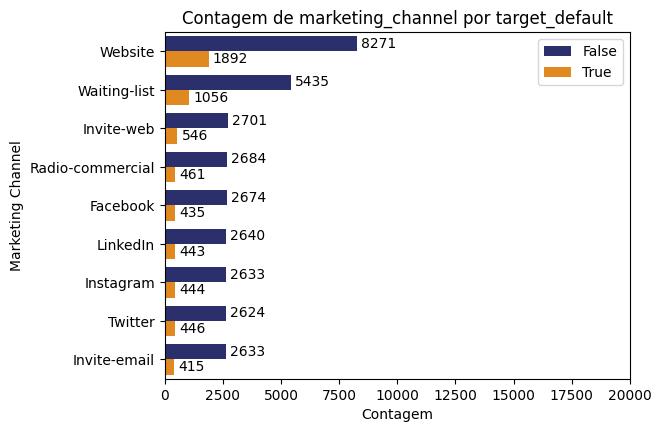

In [50]:
ordem_marketing_channel = df['marketing_channel'].value_counts().index

# Criar o gráfico de barras para a variável marketing_channel
plt.figure(figsize=(6,4.5))
ax = sns.countplot(data=df, y='marketing_channel', hue= 'target_default', order=ordem_marketing_channel, palette=paleta)


# Adiciona os rótulos
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding  = 3)

ax.legend(title=None)
ax.set_xlim((0, 20000))
plt.title('Contagem de marketing_channel por target_default')
plt.xlabel('Contagem')
plt.ylabel('Marketing Channel')
plt.show()

A variável `marketing_channel` representa o canal de aquisição dos clientes. Observa-se predominância dos canais "Website", "Waiting List" e "Web Invite", indicando que grande parte dos clientes foi captada por meios digitais e estratégias online de aquisição.

In [51]:
df['application_time_applied'].describe()

count        45000
unique       35543
top       18:02:09
freq             6
Name: application_time_applied, dtype: object

A variável `application_time_applied`, que representa o horário de solicitação da proposta, apresenta 35.543 valores distintos e requer conversão para formato temporal adequado, a fim de viabilizar análises consistentes relacionadas ao comportamento transacional e padrões temporais.

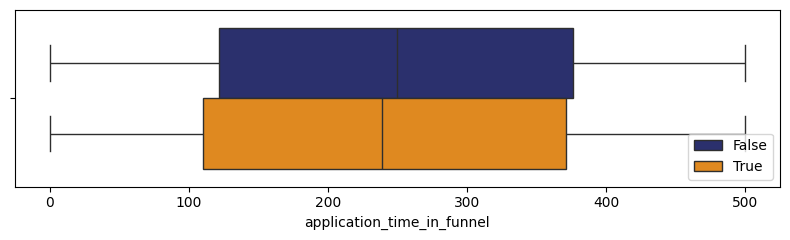

In [52]:
plt.figure(figsize = (8,2.5))

# Criar o gráfico de boxplot para a variável application_time_in_funnel
sns.boxplot(df, x='application_time_in_funnel', hue= 'target_default', orient = 'h', palette= paleta)
plt.legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()

A análise da variável `application_time_in_funnel` demonstra que bons clientes (False) e clientes inadimplentes (True) apresentam distribuições bastante semelhantes em relação ao tempo gasto no funil de aplicação. Observa-se forte sobreposição entre medianas, quartis e amplitude dos dados, indicando baixo poder discriminatório isolado dessa variável para diferenciação entre os grupos. Ainda assim, nota-se uma leve tendência de clientes inadimplentes apresentarem tempos ligeiramente menores no processo de aplicação, o que pode sugerir diferenças comportamentais sutis durante a jornada de crédito.

# 3. Data cleaning inicial (nível dataset)

A etapa de Data cleaning inicial foi definida para tratar inconsistências estruturais do dataset, assegurando uma base de dados consistente antes da divisão entre treino e teste.

Abaixo foi criada uma cópia do dataset original para preservar a integridade dos dados brutos durante as etapas de limpeza, garantindo maior segurança, rastreabilidade e reprodutibilidade.


In [53]:
# Criar uma cópia do DataFrame para limpeza
df_clean = df.copy()

As observações com valores nulos na variável alvo serão removidas, pois o problema em questão depende da presença de rótulos para aprender a relação entre as variáveis explicativas e a variável resposta. A imputação da variável alvo (criação artificial de rótulos) introduziria viés e pode comprometer a validade do modelo. Dessa forma, a exclusão dessas observações garante consistência metodológica e evita distorções no processo de modelagem.

In [54]:
# Remover valores ausentes da variável target_default
df_clean = df_clean.dropna(subset=['target_default'], axis=0)

Utilizarei esta etapa para removar algumas variáveis que não agregam valor preditivo ao modelo, incluindo identificadores únicos (como, `ids` e `profile_phone_number`), variáveis com variância nula (valores constantes, como, `channel` e `external_data_provider_credit_checks_last_2_year`) e atributos não relacionados ao objetivo do estudo (como, `target_fraud`, que não é variável alvo do problema atual e possui 97% de missing). Essas remoções são independentes da distribuição dos dados e visam simplificar o dataset, evitando ruídos e possíveis problemas na modelagem.

In [55]:
# Remover as colunas que não serão utilizadas na análise
df_clean.drop(columns=['ids', 'profile_phone_number', 'channel', 'external_data_provider_credit_checks_last_2_year', 'target_fraud'], inplace=True)

- **Conversão dos tipos de dados**

Foi realizada a conversão dos tipos das variáveis para formatos compatíveis com suas características e com os requisitos dos algoritmos de machine learning, permitindo tratamento adequado de variáveis.

In [56]:
# Ajuste de tipagem das variáveis
df_clean['facebook_profile'] = df_clean['facebook_profile'].astype('Int64')
df_clean['last_borrowed_in_months'] = df_clean['last_borrowed_in_months'].astype('Int64')
df_clean['ok_since'] = df_clean['ok_since'].astype('Int64')
df_clean['n_bankruptcies'] = df_clean['n_bankruptcies'].astype('Int64')
df_clean['n_defaulted_loans'] = df_clean['n_defaulted_loans'].astype('Int64')
df_clean['n_accounts'] = df_clean['n_accounts'].astype('Int64')
df_clean['n_issues'] = df_clean['n_issues'].astype('Int64')
df_clean['external_data_provider_credit_checks_last_year'] = df_clean['external_data_provider_credit_checks_last_year'].astype('Int64')
df_clean['external_data_provider_email_seen_before'] = df_clean['external_data_provider_email_seen_before'].astype('Int64')

- **Tratar valores inválidos**

Nesta etapa, inconsistências e valores inválidos foram identificados e substituídos por valores ausentes (NaN), com o objetivo de centralizar o tratamento dessas ocorrências em uma etapa posterior de imputação, garantindo maior consistência e rastreabilidade.

In [57]:
# Substituir valores Inf de reported_income por nan
df_clean['reported_income'] = df_clean['reported_income'].replace([np.inf, -np.inf], np.nan)

# Substituir valores -999 e -1 de external_data_provider_email_seen_before por nan
df_clean['external_data_provider_email_seen_before'] = df_clean['external_data_provider_email_seen_before'].replace([-999, -1], np.nan)

Considerando que um valor de 5.000.027 (5e6) já é extremamente elevado para a renda declarada (`income`) do cliente, irei considerar que valores de `reported_income` acima de 6.355.500.000 (percentil 99,8) são inválidos e também serão substituídos por "NaN".

In [58]:
# Calcular o percentil 99.8 de reported_income (limite superior)
percentil_9980 = df_clean['reported_income'].quantile(0.9980)  

# Substituir valores de reported_income maiores ou iguais a percentil_9980 (6.355.500.000) por nan
df_clean['reported_income'] = df_clean['reported_income'].where(lambda x: x < percentil_9980, np.nan)

- **Tratar inconsistência nos intervalos de valores de horas, minutos e segundos**

In [59]:
# Corrigir inconsistências de intervalos em minutos e segundos 
df_clean['application_time_applied'] = df_clean['application_time_applied'].str.replace(':60', ':59', regex=False)
# Corrigir horas fora do intervalo
df_clean['application_time_applied'] = df_clean['application_time_applied'].str.replace(r'^24:', '00:', regex=True )

# Converter para tipo datatime
df_clean['application_time_applied'] = pd.to_datetime(df_clean['application_time_applied'], format='%H:%M:%S', errors='coerce')

In [60]:
print('Número de linhas após limpeza: ', df_clean.shape[0])
print('Número de colunas após limpeza: ', df_clean.shape[1])

Número de linhas após limpeza:  41741
Número de colunas após limpeza:  38


# 4. Train-Test Split — divisão dos dados em treino e teste


O train-test split foi realizado antes das etapas de tratamento e transformação dos dados com o objetivo de evitar vazamento de informação (data leakage). Algumas etapas de pré-processamento, como imputação de valores ausentes, padronização, normalização e tratamento de outliers, dependem de estatísticas calculadas a partir dos dados, como média, mediana, desvio padrão ou quantis.

Caso essas transformações fossem ajustadas antes da separação entre treino e teste, informações do conjunto de teste poderiam ser incorporadas indiretamente ao processo de treinamento, resultando em uma avaliação excessivamente otimista do desempenho do modelo.

Dessa forma, as etapas de pré-processamento foram ajustadas exclusivamente no conjunto de treino e posteriormente aplicadas ao conjunto de teste, garantindo uma avaliação mais realista da capacidade de generalização dos modelos.

In [61]:
df_train_clean, df_test_clean = train_test_split(
    df_clean, 
    test_size=0.2, 
    stratify=df_clean['target_default'], 
    random_state=123)

A divisão dos dados foi estruturada de forma a priorizar um maior volume de observações no conjunto de treino, permitindo que o modelo tenha acesso a uma quantidade mais representativa de padrões durante o processo de aprendizado. O conjunto de teste foi reservado exclusivamente para a avaliação final, garantindo uma mensuração mais confiável da capacidade de generalização do modelo em dados não vistos.

Além disso, técnicas de validação cruzada (cross-validation) serão aplicadas sobre o conjunto de treino com o objetivo de maximizar o aproveitamento dos dados disponíveis, reduzir variabilidade nas métricas de avaliação e obter estimativas mais robustas e consistentes de desempenho do modelo.

In [62]:
df_train_clean.shape, df_test_clean.shape

((33392, 38), (8349, 38))

# 5. Data Cleaning e tratamento lógico dos dados

Esta etapa teve como objetivo realizar o tratamento dos dados de maneira estatisticamente consistente, garantindo maior qualidade e confiabilidade para as etapas posteriores de modelagem. A partir deste ponto, passam a ser aplicadas transformações dependentes da distribuição dos dados, como imputação de valores ausentes e tratamento de outliers, cujos parâmetros são ajustados exclusivamente com base no conjunto de treino.

Essa abordagem evita vazamento de informação (data leakage), assegurando que informações do conjunto de teste não influenciem indiretamente o processo de treinamento e avaliação dos modelos.

In [63]:
df_train_clean.head(3)

,target_default,score_1,score_2,score_3,score_4,score_5,score_6,risk_rate,last_amount_borrowed,last_borrowed_in_months,credit_limit,reason,income,facebook_profile,state,zip,job_name,real_state,ok_since,n_bankruptcies,n_defaulted_loans,n_accounts,n_issues,application_time_applied,application_time_in_funnel,email,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_year,external_data_provider_email_seen_before,external_data_provider_first_name,external_data_provider_fraud_score,lat_lon,marketing_channel,reported_income,shipping_state,shipping_zip_code,profile_tags,user_agent
280,True,smzX0nxh5QlePvtVf6EAeg==,tHpS8e9F8d9zg3iOQM9tsA==,430.00,95.26,0.32,101.93,0.32,NaN,<NA>,59538.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,100038.31,1,TYC58USu+Tq7c/WS4YLnuQ==,rNXFOEsmFlof8Vwo9dYFmw==,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,N5/CE7lSkAfB04hVFFwllw==,<NA>,0,0,12,12,1900-01-01 19:40:30,448,gmail.com,0,<NA>,34,dieverti,55,"(-14.215743924081616, -51.960294295857594)",Invite-web,191849.00,AP,12832,"{'tags': ['dfa', 'a15', 'n17', 'aty']}",Mozilla/5.0 (iPhone; CPU iPhone OS 11_0 like M...
14986,False,1Rk8w4Ucd5yR3KcqZzLdow==,rJZgTmANW3PjOCQLCcp4iQ==,390.00,102.50,0.43,87.66,0.30,11324.86,36,24603.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,143077.09,1,82aTqSzrTImY+SbAOBQzGQ==,x5kBDICFmcIF0+YeiaW07Q==,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,N5/CE7lSkAfB04hVFFwllw==,<NA>,1,0,8,8,1900-01-01 23:57:56,113,hotmail.com,3,1,37,joniel,296,"(-21.581673721807668, -42.17833938709809)",Website,26512.00,PR,34592,"{'tags': ['pro+aty', 'aty', 'n1', 'n3']}",Mozilla/5.0 (Apple-iPhone7C2/1202.466; U; CPU ...
36122,True,1Rk8w4Ucd5yR3KcqZzLdow==,IOVu8au3ISbo6+zmfnYwMg==,350.00,100.19,0.88,111.71,0.23,NaN,<NA>,42238.00,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,42018.92,1,1xxlFOWSFxK0/J2VdCKP3g==,Q+Tnwq8amUZWt+/HIeGlwg==,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,N5/CE7lSkAfB04hVFFwllw==,45,0,0,14,14,1900-01-01 08:22:43,416,hotmail.com,1,1,1,leozenir,287,"(-5.132412887671175, -38.50288563713081)",Waiting-list,187386.00,TO,28544,"{'tags': ['n5', 'n3', 'n12', 'n11']}",Mozilla/5.0 (Linux; Android 6.0.1; SM-G920V Bu...


### Tratar valores ausentes no conjutos de treino e teste

Os transformadores foram ajustados (fit) apenas no conjunto de treino e posteriormente aplicados (transform) aos conjuntos de treino e teste.

- **Imputar valores no conjunto de treino**

In [64]:
# Variáveis imputadas com a mediana
imputer_median_vars = ['last_amount_borrowed', 'last_borrowed_in_months', 'ok_since', 'credit_limit', 'n_issues', 
                       'external_data_provider_email_seen_before', 'reported_income', 'n_bankruptcies', 'n_defaulted_loans']

# Variáveis imputadas com a moda
imputer_mode_vars = ['external_data_provider_credit_checks_last_year', 'facebook_profile', 'marketing_channel', 
                     'job_name', 'lat_lon', 'user_agent', 'reason']

In [65]:
# Imputar valores ausentes de variáveis numéricas com a mediana
imputer_median = SimpleImputer(strategy='median')
imputer_median = imputer_median.fit(df_train_clean[imputer_median_vars])

df_train_clean[imputer_median_vars] = imputer_median.transform(df_train_clean[imputer_median_vars])

In [66]:
# Imputar valores ausentes de variáveis categóricas com a moda
df_train_clean[imputer_mode_vars] = (
    df_train_clean[imputer_mode_vars]
    .astype('object')
    .where(lambda x: x.notna(), np.nan)
)


imputer_mode = SimpleImputer(strategy='most_frequent')
imputer_mode = imputer_mode.fit(df_train_clean[imputer_mode_vars])

df_train_clean[imputer_mode_vars] = imputer_mode.transform(df_train_clean[imputer_mode_vars])

- **Imputar valores no conjunto de teste**

Para o conjunto de teste, foram utilizados exclusivamente os parâmetros aprendidos no treino, evitando vazamento de informação (data leakage).

In [67]:
# Imputar valores ausentes de variáveis numéricas com a mediana no conjunto de teste
df_test_clean[imputer_median_vars] = imputer_median.transform(df_test_clean[imputer_median_vars])

# Imputar valores ausentes de variáveis categóricas com a moda no conjunto de teste
df_test_clean[imputer_mode_vars] = (
    df_test_clean[imputer_mode_vars]
    .astype('object')
    .where(lambda x: x.notna(), np.nan)
)

df_test_clean[imputer_mode_vars] = imputer_mode.transform(df_test_clean[imputer_mode_vars])

Ao fazer a imputação anterior, as variáveis `facebook_profile` e `external_data_provider_credit_checks_last_year` foram convertidas para object, vou transformá-las novamente para o tipo numérico.

In [68]:
# converter variáveis para tipo inteiro no conjunto de treino
df_train_clean['facebook_profile'] = df_train_clean['facebook_profile'].astype('Int64')
df_train_clean['external_data_provider_credit_checks_last_year'] = df_train_clean['external_data_provider_credit_checks_last_year'].astype('Int64')

# converter variáveis para tipo inteiro no conjunto de treino
df_test_clean['facebook_profile'] = df_test_clean['facebook_profile'].astype('Int64')
df_test_clean['external_data_provider_credit_checks_last_year'] = df_test_clean['external_data_provider_credit_checks_last_year'].astype('Int64')

### Tratamento de outliers

Nesta etapa, foram aplicadas técnicas de tratamento de outliers para reduzir o impacto de observações extremas que poderiam influenciar negativamente o ajuste dos modelos, especialmente em algoritmos sensíveis à escala e à distribuição dos dados.


- **Analisar a distribuição da variável `income`**

In [69]:
display(df_train_clean[['income']].describe(percentiles=[0.1,0.25,0.75,0.90, 0.95, 0.99]).T)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
income,33392.00,70968.17,52274.95,4821.18,32030.82,44020.10,60045.42,85032.42,119025.41,143026.72,225028.73,5000027.83


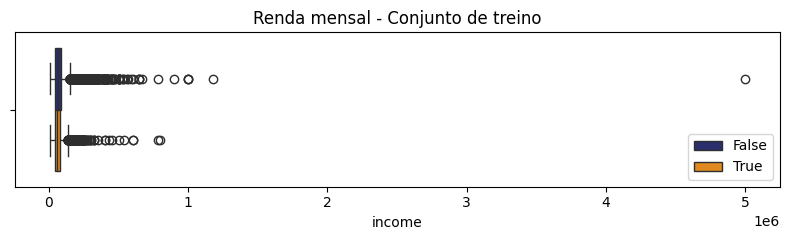

In [70]:
fig, ax = plt.subplots(figsize = (8,2.5))

# Criar o gráfico de boxplot para a variável income no conjunto de treino
sns.boxplot(df_train_clean, x = 'income', hue= 'target_default', orient = 'h', palette= paleta, ax= ax)
ax.set_title('Renda mensal - Conjunto de treino')
ax.legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()

A variável de renda apresenta forte assimetria à direita, com presença de valores extremamente elevados. Diferentemente de outras variáveis financeiras, esses extremos podem refletir tanto casos legítimos quanto possíveis inconsistências nos dados. Dado o potencial impacto desses valores na modelagem, optou-se por aplicar técnicas de tratamento de outliers, como winsorização baseada em percentis, preservando a informação sem permitir que valores extremos distorçam o modelo.

In [71]:
valor = 1000023.87

# Calcular o percentil do valor 1000023.87 na variável income do conjunto de treino
percentil_income = stats.percentileofscore(df_train_clean['income'], valor, kind='weak')
percentil_income = percentil_income/100
print(percentil_income)

0.9998802108289411


Aplicar winsorização na variável `income`  para o conjunto de treino e teste.

In [72]:
# Aplicar winsorização na variável income do conjunto de treino
income_upper_cap = df_train_clean['income'].quantile(percentil_income)
df_train_clean['income'] = np.clip(df_train_clean['income'], None, income_upper_cap)

In [73]:
# Aplicar winsorização na variável income do conjunto de teste
df_test_clean['income'] = np.clip(df_test_clean['income'], None, income_upper_cap)

- **Analisar a distribuição da variável `reported_income`** 

In [74]:
display(df_train_clean[['reported_income']].describe(percentiles=[0.1,0.25,0.75,0.90, 0.95, 0.99]).T)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
reported_income,33392.00,194923.26,2248005.84,403.00,20544.80,51087.50,101252.00,150360.50,180654.90,190822.90,198907.72,55500000.00


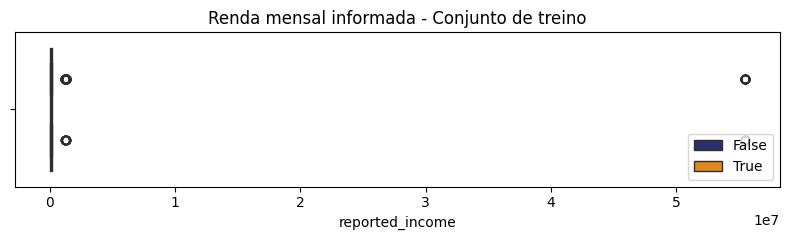

In [75]:
fig, ax = plt.subplots(figsize = (8,2.5))

# Criar o gráfico de boxplot para a variável reported_income no conjunto de treino
sns.boxplot(df_train_clean, x = 'reported_income', hue= 'target_default', orient = 'h', palette= paleta, ax= ax)
ax.set_title('Renda mensal informada - Conjunto de treino')
ax.legend(title=None, loc='lower right')

plt.tight_layout()
plt.show()

In [76]:
df_train_clean[df_train_clean['reported_income'] > 1e6]['reported_income'].value_counts()

reported_income
55500000.00    55
1300000.00     50
1200000.00     48
Name: count, dtype: int64

A variável `reported_income` apresentou valores extremamente discrepantes em relação à distribuição principal, com concentração de dados abaixo de 200 mil e presença de valores máximos de até 55,5 milhões. A análise de frequência revelou que esses valores elevados não são casos isolados, mas sim ocorrências repetidas e padronizadas, indicando possíveis inconsistências sistêmicas, valores default ou problemas de captura. Diante disso, esses valores serão tratados como dados suspeitos, sendo substituídos por valores ausentes e posteriormente imputados, garantindo maior consistência e robustez ao modelo.

Na sequência, será feito a substituição desses valores por "NaN" e, em seguida, tratados por meio da imputação utilizando a mediana, nos conjuntos de treino e teste. Neste processo foi usado apenas o método "transform()", garantindo consistência no processo de preparação dos dados, evitando vazamento de informação (*data leakage*).

In [77]:
# Substituir valores suspeitos de reported_income por nan
valores_suspeitos = [55500000, 1300000, 1200000]

df_train_clean['reported_income'] = df_train_clean['reported_income'].replace(valores_suspeitos, np.nan)
df_test_clean['reported_income'] = df_test_clean['reported_income'].replace(valores_suspeitos, np.nan)

In [78]:
# Imputar valores ausentes da variável reported_income com a mediana no conjunto de treino e teste
imputer_median = SimpleImputer(strategy='median')
imputer_median = imputer_median.fit(df_train_clean['reported_income'].values.reshape(-1,1))

df_train_clean['reported_income'] = imputer_median.transform(df_train_clean['reported_income'].values.reshape(-1,1)).ravel()
df_test_clean['reported_income'] = imputer_median.transform(df_test_clean['reported_income'].values.reshape(-1,1)).ravel()

# 6. Feature Engineering

O processo de feature engineering tem como objetivo construir atributos capazes de capturar padrões comportamentais e relações relevantes para a previsão de inadimplência, contribuindo para maior capacidade discriminativa e desempenho preditivo dos modelos.

Nesta etapa, foi gerada uma cópia do DataFrame anterior com o objetivo de isolar as transformações de feature engineering, garantindo rastreabilidade, reprodutibilidade e evitando modificações diretas feitas em etapas anteriores.

In [79]:
# Criar uma cópia do DataFrame para feature engineering
df_train_eng = df_train_clean.copy()
df_test_eng = df_test_clean.copy()

- **Análise sobre a variável `score_1`**

In [80]:
# Analisar a relação entre score_1 e target_default no conjunto de treino
count_score_1 = df_train_eng['score_1'].value_counts().reset_index()
tab_score_1 = pd.crosstab(df_train_eng['score_1'],
                         df_train_eng['target_default'], normalize = 'index') * 100


merge_score_1 = count_score_1.merge(tab_score_1, how = 'inner', on = 'score_1')

display(merge_score_1.sort_values(by = True))

,score_1,count,False,True
2,4DLlLW62jReXaqbPaHp1vQ==,5903,93.78,6.22
0,DGCQep2AE5QRkNCshIAlFQ==,11333,88.20,11.80
1,1Rk8w4Ucd5yR3KcqZzLdow==,8225,82.13,17.87
3,8k8UDR4Yx0qasAjkGrUZLw==,4809,76.98,23.02
4,e4NYDor1NOw6XKGE60AWFw==,2086,69.65,30.35
5,smzX0nxh5QlePvtVf6EAeg==,844,61.61,38.39
6,fyrlulOiZ+5hoFqLa6UbDQ==,192,52.60,47.40


A feature `score_1` possui 7 categorias anônimos distintas e, para melhor entendimento, vamos utilizar a proporção de inadimplentes para fazer agrupamento de classes. Vamos agrupar as categorias usando os intervalos de taxas de inadimplência abaixo: 

<div align="center">

| Faixa | % Inadimplência | Interpretação     |
|:-----:|:---------------:|:-------------:|
| A     | 0 – 8%         | Muito baixo risco |
| B     | 8 – 15%        | Baixo risco       |
| C     | 15 – 25%        | Médio risco       |
| D     | 25 – 35%        | Alto risco        |
| E     | 35%+            | Muito alto risco  |

</div>

In [81]:
# Definir os intervalos (bins) e os respectivos rótulos
bins_sc1 = [0, 8, 15, 25, 35, 100]
labels_sc1 = ['A', 'B', 'C', 'D', 'E']

# Criação da nova variável (risk_bin)
merge_score_1['risk_bin'] = pd.cut(merge_score_1[True], bins=bins_sc1, labels=labels_sc1)
display(merge_score_1.head(10))

,score_1,count,False,True,risk_bin
0,DGCQep2AE5QRkNCshIAlFQ==,11333,88.20,11.80,B
1,1Rk8w4Ucd5yR3KcqZzLdow==,8225,82.13,17.87,C
2,4DLlLW62jReXaqbPaHp1vQ==,5903,93.78,6.22,A
3,8k8UDR4Yx0qasAjkGrUZLw==,4809,76.98,23.02,C
4,e4NYDor1NOw6XKGE60AWFw==,2086,69.65,30.35,D
5,smzX0nxh5QlePvtVf6EAeg==,844,61.61,38.39,E
6,fyrlulOiZ+5hoFqLa6UbDQ==,192,52.60,47.40,E


In [82]:
# criar um dicionário de mapeamento
dict_risk_1 = dict(zip(merge_score_1['score_1'], merge_score_1['risk_bin']))

# Mapping de variável categórica baseado em risco
df_train_eng['score_1_bin'] = df_train_eng['score_1'].map(dict_risk_1)

In [83]:
# Função para calcular o Weight of Evidence (WOE) e Information Value (IV)
def calculate_woe_iv(df, feature, target, epsilon=1e-6):
    
    # Validação básica
    if not set(df[target].dropna().unique()).issubset({0, 1}):
        raise ValueError("Target deve ser binário (0 e 1).")

    # Agrupamento
    # - count: total de registros por bin
    # - sum: total de inadimplentes (target_default = 1)
    df_woe = df.groupby(feature, observed=False)[target].agg(['count', 'sum'])
    df_woe.columns = ['total', 'bad']
    
    # Calcula a quantidade de bons (não inadimplentes)
    df_woe['good'] = df_woe['total'] - df_woe['bad']

    # Totais globais
    total_good = df_woe['good'].sum()
    total_bad = df_woe['bad'].sum()

    # Distribuições (já com proteção)
    df_woe['dist_good'] = (df_woe['good'] / total_good).clip(lower=epsilon)
    df_woe['dist_bad'] = (df_woe['bad'] / total_bad).clip(lower=epsilon)
    
    df_woe['dist_good'] = pd.to_numeric(df_woe['dist_good'], errors='coerce')
    df_woe['dist_bad'] = pd.to_numeric(df_woe['dist_bad'], errors='coerce')

    # Calcula o Weight of Evidence (WOE) para cada bin
    # WOE = log( proporção de bons / proporção de maus )
    # Mede o poder de separação de cada grupo em relação à inadimplência
    df_woe['woe'] = np.log(df_woe['dist_good'] / df_woe['dist_bad'])

    # Calcula o Information Value (IV) por bin
    # IV = (dist_good - dist_bad) * WOE
    # Mede a contribuição de cada bin na separação entre bons e maus
    df_woe['iv'] = (df_woe['dist_good'] - df_woe['dist_bad']) * df_woe['woe']

    return df_woe

**Cálculo do Weight of Evidence (WOE) e Information Value (IV) e suas classificações**

O Weight of Evidence (WOE) mede a relação entre a distribuição de eventos e não eventos em cada categoria ou faixa de uma variável, permitindo avaliar o comportamento preditivo dos atributos em problemas de classificação binária.

WOE > 0 → maior concentração de indivíduos não inadimplentes (bons pagadores), indicando menor risco de inadimplência; \
WOE < 0 → maior concentração de indivíduos inadimplentes (maus pagadores), indicando maior risco de inadimplência; \
WOE ≈ 0 → distribuição semelhante entre as classes, indicando baixo poder discriminativo para aquela faixa da variável.


O Information Value (IV) foi utilizado para avaliar o poder preditivo das variáveis, permitindo identificar atributos com maior capacidade de separação entre as classes de inadimplência e não inadimplência.

Se IV total < 0.02: sem poder preditivo \
Se 0.02 <= IV total < 0.1: Fraco \
Se 0.1 <= IV total < 0.3: Médio \
Se 0.3 <= IV total < 0.5: Forte \
Se IV total <= 0.5: Muito forte (ou suspeito)

In [84]:
# Calcular o WOE e IV para a variável score_1_bin
woe_score_1_bin = calculate_woe_iv(df = df_train_eng, feature = 'score_1_bin', target = 'target_default', epsilon=1e-6)
woe_score_1_bin

,total,bad,good,dist_good,dist_bad,woe,iv
score_1_bin,,,,,,,
A,5903,367,5536,0.20,0.07,1.05,0.14
B,11333,1337,9996,0.36,0.25,0.35,0.04
C,13034,2577,10457,0.37,0.48,-0.26,0.03
D,2086,633,1453,0.05,0.12,-0.83,0.06
E,1036,415,621,0.02,0.08,-1.26,0.07


In [85]:
# Calcula o Information Value (IV) total da variável
iv_total_woe_score_1_bin = woe_score_1_bin['iv'].round(2).sum()
iv_total_woe_score_1_bin

np.float64(0.34)

A variável `score_1_bin` apresentou comportamento monotônico consistente nos valores de Weight of Evidence (WOE), com redução progressiva do indicador à medida que o risco de inadimplência aumenta, evidenciando boa capacidade de separação entre bons e maus pagadores. As faixas A e B concentraram maior proporção de clientes adimplentes, enquanto as faixas D e E apresentaram maior concentração de inadimplentes, indicando aumento do risco de crédito.

O Information Value (IV) total de `score_1_bin` foi igual a 0.34, caracterizando forte poder preditivo e indicando que a variável possui elevada relevância para os modelos de risco de crédito.


Como passo seguinte, será incluído o WOE da variável `score_1` no dataset.

In [86]:
# Mapear os valores de WOE para a variável score_1_bin no conjunto de treino
df_train_eng['score_1_woe'] = df_train_eng['score_1_bin'].map(woe_score_1_bin['woe'])

Aplicar o mapeamento do WOE de `score_1`, feito no conjunto de treino, para o conjunto de teste.

In [87]:
# Aplicar o mesmo mapeamento de WOE do conjunto de treino no conjunto de teste
df_test_eng['score_1_bin'] = df_test_eng['score_1'].map(dict_risk_1)
df_test_eng['score_1_woe'] = df_test_eng['score_1_bin'].map(woe_score_1_bin['woe'])

 - **Análise sobre a variável `score_2`**

In [88]:
count_score_2 = df_train_eng['score_2'].value_counts().reset_index()
tab_score_2 = pd.crosstab(df_train_eng['score_2'],
                         df_train_eng['target_default'], normalize = 'index') * 100

merge_score_2 = count_score_2.merge(tab_score_2, how = 'inner', on = 'score_2')

merge_score_2.sort_values(by = True, ascending=False).head(15)

,score_2,count,False,True
30,wjdj2vxjWoDsEIk0l09ynw==,78,43.59,56.41
34,5/uMrqKj3OL/Xk5OrGx9fg==,11,54.55,45.45
29,6J1ZMTzN5GKHXnhM4J1JbA==,86,54.65,45.35
32,55UK234RR1d7HIWJjmq9tw==,38,55.26,44.74
31,+2hzpeP1RWr8PEvL1WTUdw==,49,57.14,42.86
27,vJyc9xom9v7hwFMPTIpmKw==,180,59.44,40.56
26,tHpS8e9F8d9zg3iOQM9tsA==,202,62.87,37.13
25,bopP0NxW3+r8tn9xIHTaOw==,249,63.05,36.95
28,O4i7FxcROACMVTCgI0WXuA==,127,64.57,35.43
23,cdpgyOyZS04uXerMNu7uCw==,372,67.74,32.26


A variável `score_2` possui 35 categorias distintas. Para reduzir a cardinalidade, será aplicado agrupamento baseado na taxa de inadimplência, formando bins mais informativos.

In [89]:
# Definir os intervalos (bins) e os respectivos rótulos
bins_sc2 = [0, 8, 15, 25, 35, 100]
labels_sc2 = ['A', 'B', 'C', 'D', 'E']

# Criação da nova variável (risk_bin)
merge_score_2['risk_bin'] = pd.cut(merge_score_2[True], bins=bins_sc2, labels=labels_sc2)
merge_score_2.head(10)

,score_2,count,False,True,risk_bin
0,osCzpM4hJrxugqWWuZmMWw==,2775,88.50,11.50,B
1,SaamrHMo23l/3TwXOWgVzw==,2522,86.28,13.72,B
2,RO7MTL+j4PH2gNzbhNTq/A==,2385,90.40,9.60,B
3,/tdlnWjXoZ3OjdtBXzdOJQ==,2002,84.97,15.03,C
4,Fv28Bz0YRTVAT5kl1bAV6g==,1827,90.15,9.85,B
5,7h+tk4z7O9brtBSe1rNjxA==,1824,85.58,14.42,B
6,rJZgTmANW3PjOCQLCcp4iQ==,1767,84.55,15.45,C
7,pAzpxkhjPsjWldgSX21+zg==,1655,91.42,8.58,B
8,IOVu8au3ISbo6+zmfnYwMg==,1604,81.61,18.39,C
9,tQUTfUyeuGkhRotd+6WjVg==,1499,92.93,7.07,A


In [90]:
# criar um dicionário de mapeamento
dict_risk_2 = dict(zip(merge_score_2['score_2'], merge_score_2['risk_bin']))

# Mapping de variável categórica baseado em risco
df_train_eng['score_2_bin'] = df_train_eng['score_2'].map(dict_risk_2)

In [91]:
# Calcular o WOE e IV para a variável score_2_bin
woe_score_2_bin = calculate_woe_iv(df_train_eng, feature = 'score_2_bin', target = 'target_default', epsilon=1e-6)
woe_score_2_bin

,total,bad,good,dist_good,dist_bad,woe,iv
score_2_bin,,,,,,,
A,4248,225,4023,0.14,0.04,1.22,0.12
B,12988,1479,11509,0.41,0.28,0.39,0.05
C,12333,2391,9942,0.35,0.45,-0.24,0.02
D,2803,823,1980,0.07,0.15,-0.78,0.07
E,1020,411,609,0.02,0.08,-1.27,0.07


In [92]:
# Calcula o Information Value (IV) total da variável
iv_total_score_2_bin = woe_score_2_bin['iv'].round(2).sum()
iv_total_score_2_bin

np.float64(0.33)

Para a variável `score_2`, houve redução significativa de cardinalidade, passando de 35 para 5 categorias, com comportamento monotônico dos valores de WOE em relação ao aumento do risco. As categorias superiores concentram maior proporção de clientes adimplentes, enquanto as inferiores apresentam maior incidência de inadimplência.

O Information Value (IV) de aproximadamente 0,33 classifica a variável como altamente preditiva, evidenciando elevada capacidade discriminatória e relevância para o modelo de risco de crédito.

Na sequência, os valores de WOE da variável `score_2` serão incorporados ao conjunto de treino e teste.

In [93]:
# Mapear os valores de WOE para a variável score_2_bin no conjunto de treino
df_train_eng['score_2_woe'] = df_train_eng['score_2_bin'].map(woe_score_2_bin['woe'])

In [94]:
# Aplicar o mesmo mapeamento de WOE do conjunto de treino no conjunto de teste
df_test_eng['score_2_bin'] = df_test_eng['score_2'].map(dict_risk_2)
df_test_eng['score_2_woe'] = df_test_eng['score_2_bin'].map(woe_score_2_bin['woe'])

- **Análise sobre a variável `application_time_applied`**

Agora, vamos verificar o horário em que a proposta de crédito foi aplicada pelos clientes.

In [95]:
# Criar variável de hora a partir da variável application_time_applied
df_train_eng['hour'] = df_train_eng['application_time_applied'].dt.hour

In [96]:
# Definir os intervalos (bins) e os respectivos rótulos
# Criação da nova variável (time_of_day_bin)
df_train_eng['time_of_day_bin'] = pd.cut(
        df_train_eng['hour'],                
        bins=[0, 6, 12, 18, 24],                        
        labels=['madrugada', 'manha', 'tarde', 'noite'],    
        right=False)

# Tabela com a taxa de adimplentes e inadimplentes por 
tab_time_of_day_risk = pd.crosstab(    
    df_train_eng['time_of_day_bin'], 
    df_train_eng['target_default'],
    normalize = 'index').reset_index()

tab_time_of_day_risk

target_default,time_of_day_bin,False,True
0,madrugada,0.80,0.20
1,manha,0.85,0.15
2,tarde,0.86,0.14
3,noite,0.87,0.13


A inadimplência apresenta redução ao longo do dia, sendo maior na madrugada (20%), intermediária na manhã e tarde (15%) e menor à noite (13%). Esse padrão sugere que horários fora do padrão comercial estão associados a maior risco, enquanto períodos mais tardios indicam comportamento mais estável.

In [97]:
# Calcular o WOE e IV para a variável time_of_day_bin
woe_time_of_day_bin = calculate_woe_iv(df = df_train_eng, feature = 'time_of_day_bin', target = 'target_default', epsilon=1e-6)
woe_time_of_day_bin

,total,bad,good,dist_good,dist_bad,woe,iv
time_of_day_bin,,,,,,,
madrugada,10295,2022,8273,0.29,0.38,-0.25,0.02
manha,7991,1234,6757,0.24,0.23,0.04,0.00
tarde,7574,1089,6485,0.23,0.20,0.12,0.00
noite,7532,984,6548,0.23,0.18,0.23,0.01


In [98]:
iv_total_time_of_day_bin = woe_time_of_day_bin['iv'].round(2).sum()
iv_total_time_of_day_bin

np.float64(0.03)

A variável `time_of_day_bin` apresentou baixo poder discriminativo em relação à inadimplência, com valores de Weight of Evidence (WOE) próximos de zero na maior parte das categorias. Observa-se apenas uma leve tendência de maior risco no período da madrugada, que apresentou WOE negativo e maior proporção relativa de inadimplentes. 

O Information Value (IV) total de 0.03 classifica a variável como pouco preditiva, sugerindo contribuição limitada para os modelos de risco de crédito. Apesar disso, optou-se por manter a variável na base de dados, uma vez que pode contribuir marginalmente para a performance sem introduzir complexidade adicional.

In [99]:
# Mapear os valores de WOE para a variável time_of_day_bin no conjunto de treino
df_train_eng['time_of_day_woe'] = df_train_eng['time_of_day_bin'].map(woe_time_of_day_bin['woe'])

Fazer os mesmos procedimentos realizados acima no conjunto de teste. Isto é, extrair a hora de aplicação da proposta e incluir valores de WOE para a variável time_of_day_bin no conjunto de teste.

In [100]:
# Criar variável de hora a partir da variável application_time_applied
df_test_eng['hour'] = df_test_eng['application_time_applied'].dt.hour

# Definir os intervalos (bins) e os respectivos rótulos
# Criação da nova variável (time_of_day_bin)
df_test_eng['time_of_day_bin'] = pd.cut(
        df_test_eng['hour'],                
        bins=[0, 6, 12, 18, 24],                        
        labels=['madrugada', 'manha', 'tarde', 'noite'],    
        right=False)

# Aplicar o mesmo mapeamento de WOE do conjunto de treino no conjunto de teste
df_test_eng['time_of_day_woe'] = df_test_eng['time_of_day_bin'].map(woe_time_of_day_bin['woe'])

- **Análise sobre a variável `reason`**

Vamos aprofundar o nosso entendimento sobre a variável `reason`. A princípio destaca-se que foram identificados um total de 14.874 razões pelas quais os clientes estão solicitando de crédito. Essa amplitude pode trazer desafios ao analisar e agrupar essas razões de maneira eficaz, sendo que os motivos estão anonimizados, mas também pode fornecer insights valiosos sobre as necessidades variadas dos clientes. 

In [101]:
# Contar a quantidade de registros por classe de reason
count_reason =  df_train_eng['reason'].value_counts().reset_index()

# Selecionar grupos com mais de 1 registro
count_reason_greater_1 = count_reason[count_reason['count'] > 1]

# Realizar um merge entre o data frame de treino e o data frame de contagem para obter as linhas correspondentes
df_reason_greater_1 = df_train_eng[['reason', 'target_default']].merge(count_reason_greater_1, how = 'inner', on = 'reason')


# Obter a proporção de bons e maus pagadores de cada classe
tab_reason_risk = pd.crosstab(df_reason_greater_1['reason'], 
                              df_reason_greater_1['target_default'], 
                              normalize= 'index')
tab_reason_risk = tab_reason_risk.reset_index()


# Realizar um merge entre o data frame de contagem e o data frame de proporção para obter as linhas correspondentes
merge_reason_risk = df_reason_greater_1[['reason', 'count']].merge(tab_reason_risk, how = 'inner', on = 'reason')
merge_reason_risk.sort_values(by = 'count', ascending = False).head(10)

,reason,count,False,True
11,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
23276,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
0,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
1,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
2,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
10,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
6811,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
6790,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
6796,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17
6797,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17


In [102]:
# Definir os intervalos (bins) e os respectivos rótulos
bins_reason_risk = [0, 0.08, 0.15, 0.25, 100]
labels_reason_risk = ['Baixo Risco', 'Medio risco', 'Alto Risco', 'Muito Alto Risco']

# Criação da nova variável (risk_bin)
merge_reason_risk['risk_bin'] = pd.cut(merge_reason_risk[True], bins=bins_reason_risk, labels=labels_reason_risk)

merge_reason_risk.head(10)

,reason,count,False,True,risk_bin
0,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17,Alto Risco
1,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17,Alto Risco
2,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,3289,0.83,0.17,Alto Risco
3,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,77,0.92,0.08,Baixo Risco
4,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,1119,0.87,0.13,Medio risco
5,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,24,0.79,0.21,Alto Risco
6,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,47,0.79,0.21,Alto Risco
7,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,33,0.94,0.06,Baixo Risco
8,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,89,0.85,0.15,Medio risco
9,mLVIVxoGY7TUDJ1FyFoSIZi1SFcaBmO01AydRchaEiGYtU...,280,0.83,0.17,Alto Risco


In [103]:
# criar um dicionário de mapeamento
dict_reason_risk = dict(zip(merge_reason_risk['reason'], merge_reason_risk['risk_bin']))

# Mapping de variável categórica baseado em risco
df_train_eng['reason_bin'] = df_train_eng['reason'].map(dict_reason_risk)
df_train_eng['reason_bin'] = df_train_eng['reason_bin'].fillna('Outro')

In [104]:
# # Calcular o WOE e IV para a variável reason_bin
woe_reason = calculate_woe_iv(df = df_train_eng, feature = 'reason_bin', target = 'target_default', epsilon=1e-06)
woe_reason

,total,bad,good,dist_good,dist_bad,woe,iv
reason_bin,,,,,,,
Alto Risco,11260,2017,9243,0.33,0.38,-0.14,0.01
Baixo Risco,674,41,633,0.02,0.01,1.08,0.02
Medio risco,6111,784,5327,0.19,0.15,0.25,0.01
Muito Alto Risco,2711,987,1724,0.06,0.19,-1.10,0.14
Outro,12636,1500,11136,0.40,0.28,0.34,0.04


In [105]:
iv_total_reason = woe_reason['iv'].round(2).sum()
iv_total_reason.round(2)

np.float64(0.22)

A variável `reason`, originalmente composta por alta cardinalidade (mais de 14 mil categorias), foi agrupada em cinco classes com base em similaridade de risco, reduzindo significativamente sua complexidade. 

A análise de Weight of Evidence (WOE) indica boa capacidade discriminatória, com destaque para a categoria “Muito Alto Risco”, que apresentou WOE fortemente negativo, indicando maior concentração de clientes inadimplentes e forte associação com maior risco de crédito. Em contrapartida, a categoria "Baixo Risco" concentra a maior proporção de bons clientes e menor risco de inadimplência. Conforme calculado, o Information Value (IV = 0.22) classifica a variável como moderadamente preditiva, indicando relevância significativa para a composição de modelos de risco de crédito.

Desta forma, vamos adicionar os valores de WOE da variável `reason` em nosso conjunto de dados de treino e de teste.

In [106]:
# Mapear os valores de WOE para a variável reason_bin no conjunto de treino
df_train_eng['reason_woe'] = df_train_eng['reason_bin'].map(woe_reason['woe'])

As features obtidas acima serão adicionadas também ao conjunto de teste.

In [107]:
# Mapping de variável categórica baseado em risco para o conjunto de teste
df_test_eng['reason_bin'] = df_test_eng['reason'].map(dict_reason_risk)
df_test_eng['reason_bin'] = df_test_eng['reason_bin'].fillna('Outro')


# Aplicar o mesmo mapeamento de WOE do conjunto de treino no conjunto de teste
df_test_eng['reason_woe'] = df_test_eng['reason_bin'].map(woe_reason['woe'])

- **Razão entre `income` e `reported_income`**

A seguir vamos comparar a razão entre a renda verdadeira (`income`) e a renda informada (`reported_income`) pelo cliente. A análise da razão entre as rendas permite avaliar o nível de consistência entre as informações.

In [108]:
# comparar renda declarada com renda reportada (razão)
(df_train_eng['reported_income'] / df_train_eng['income']).describe(percentiles=[0.1,0.25,0.75,0.90, 0.95, 0.99])

count   33392.00
mean        1.86
std         1.62
min         0.00
10%         0.29
25%         0.73
50%         1.50
75%         2.53
90%         3.81
95%         4.79
99%         7.48
max        22.60
dtype: float64

Essa variável mostra se a renda informada pelo cliente é coerente com a renda registrada. Quando há muita diferença — principalmente quando o cliente declara mais do que realmente ganha — o risco de inadimplência tende a ser maior. Observando estatísticas a respeito da razão entre as rendas é notado que 25% das pessoas são mais conservadoras e informam ganhos inferiores ao seu ganho real, contudo, existem casos em que os clientes inflam muito os seus ganhos, informando renda superior a 22 vezes o seu ganho real.

Essa variável pode ter poder preditivo real em modelos de crédito e, desta forma, vamos inclui-la aos dados de treino e teste.

In [109]:
# Incluir razão entre renda declarada e renda reportada no conjunto de treino e teste
df_train_eng['ratio_reported_income'] = df_train_eng['reported_income'] / df_train_eng['income']
df_test_eng['ratio_reported_income'] = df_test_eng['reported_income'] / df_test_eng['income']

- **Razão entre `credit_limit` e `income`**

De forma análoga, vamos analisar a razão entre o limite de crédito disponível para o cliente e a sua renda real.

In [110]:
(df_train_eng['credit_limit'] / df_train_eng['income']).describe(percentiles=[0.1,0.25,0.75,0.90, 0.95, 0.99])

count   33392.00
mean        0.50
std         0.45
min         0.00
10%         0.00
25%         0.22
50%         0.42
75%         0.67
90%         0.99
95%         1.26
99%         2.06
max         8.54
dtype: float64

A análise da razão entre `credit_limit` e `income` demonstra que 90% dos clientes possuem limite de crédito inferior à renda mensal observada. 

Entretanto, existem casos em que o limite concedido alcança até 8,54 vezes a renda do cliente, indicando níveis elevados de alavancagem financeira. Essa variável representa a relação entre capacidade de pagamento e crédito disponibilizado, sendo potencialmente relevante para identificação de maior risco de inadimplência.

Diante de sua relevância analítica, a feature será incorporada ao conjunto de dados para utilização na modelagem preditiva.


In [111]:
# Incluir razão entre renda declarada e renda reportada no conjunto de treino e teste
df_train_eng['ratio_credit_limit_income'] = df_train_eng['credit_limit'] / df_train_eng['income']
df_test_eng['ratio_credit_limit_income'] = df_test_eng['credit_limit'] / df_test_eng['income']

- **Análise sobre a variável `lat_lon`**

Extrair latitude e longitude e explorar visualmente relações geográficas.

In [112]:
# Extrair latitude e longitude
df_train_eng[['latitude', 'longitude']] = (
    df_train_eng['lat_lon']
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
    .str.split(',', expand=True)
    .astype(float)
)

df_train_eng[['latitude', 'longitude']].head()

,latitude,longitude
280,-14.22,-51.96
14986,-21.58,-42.18
36122,-5.13,-38.50
36013,-22.92,-45.29
34317,-19.75,-44.03


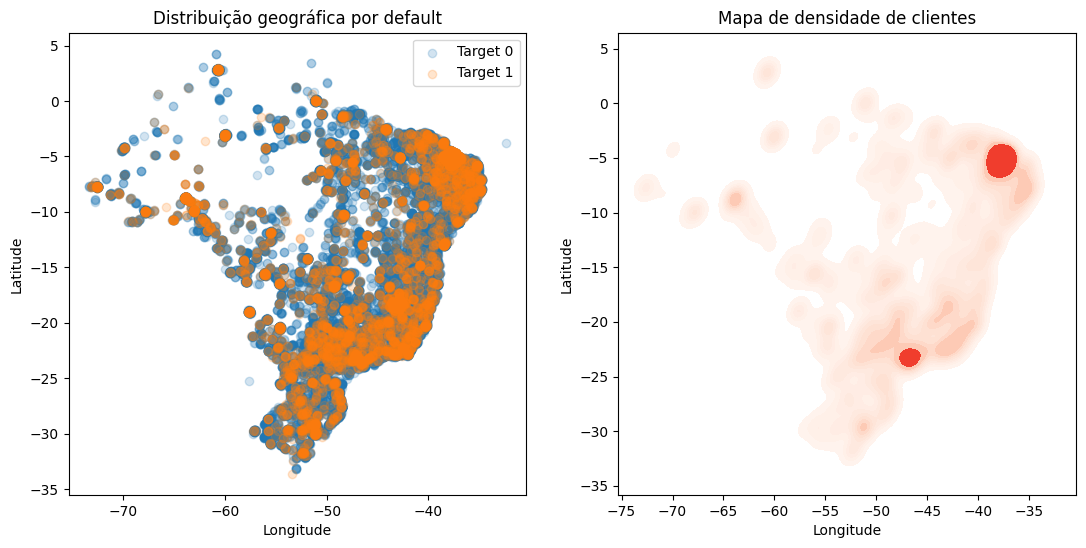

In [113]:
plt.figure(figsize=(13,6))

# Scatter plot com target
plt.subplot(1,2,1)
for label, color in zip([0,1], ['#202678','#FF8C00']):
    subset = df_train_eng[df_train_eng['target_default'] == label]
    plt.scatter(
        subset['longitude'], 
        subset['latitude'], 
        alpha=0.2, 
        label=f'Target {label}'
    )

plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Distribuição geográfica por default')

# Heatmap de densidade
plt.subplot(1,2,2)
sns.kdeplot(
    x=df_train_eng['longitude'],
    y=df_train_eng['latitude'],
    fill=True,
    cmap='Reds',
    bw_adjust=0.5
)

plt.title('Mapa de densidade de clientes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


Observa-se a existência de agrupamentos geográficos relevantes entre os clientes, reforçando a importância das variáveis de localização na modelagem de risco. Determinadas regiões apresentam maior concentração de clientes e níveis mais elevados de inadimplência, sugerindo padrões regionais de comportamento financeiro.

As visualizações evidenciam a presença de dependência espacial nos dados, justificando a aplicação de técnicas como clusterização geográfica e engenharia de variáveis derivadas para captura desses padrões.

In [114]:
# Clusterização geográfica
kmeans = KMeans(n_clusters=8, random_state=42)
df_train_eng['geo_cluster'] = kmeans.fit_predict(df_train_eng[['latitude','longitude']])


df_train_eng = df_train_eng.reset_index(drop=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

df_train_eng['cluster_risk'] = np.nan

for train_idx, val_idx in kf.split(df_train_eng):
    train_fold = df_train_eng.iloc[train_idx]
    val_fold = df_train_eng.iloc[val_idx]
    
    cluster_risk_map = train_fold.groupby('geo_cluster')['target_default'].mean()
    global_mean = train_fold['target_default'].mean()
    
    df_train_eng.loc[val_idx, 'cluster_risk'] = (
        val_fold['geo_cluster'].map(cluster_risk_map)
        .astype(float)
        .fillna(global_mean)
    )

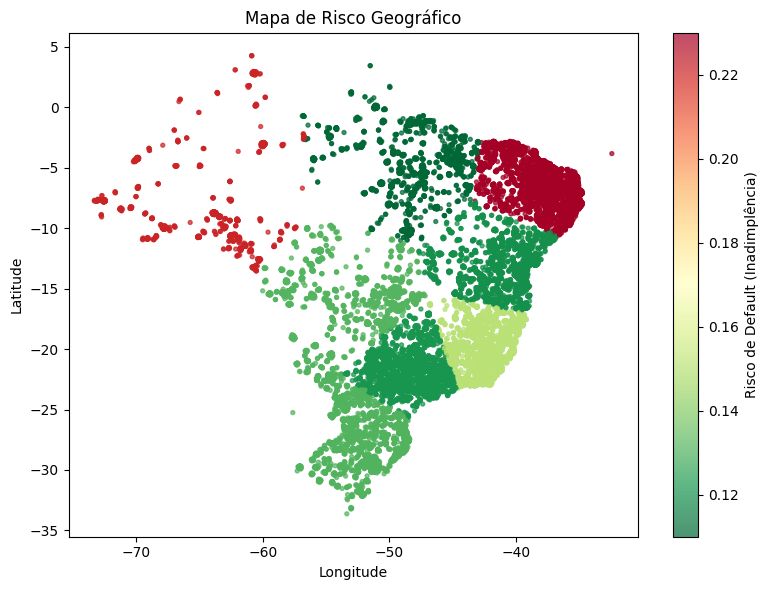

In [115]:
# Mapear risco por cluster e colorir pelo risco no scatter plot geográfico
df_train_eng['cluster_risk'] = df_train_eng['geo_cluster'].map(cluster_risk_map)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df_train_eng['longitude'],
    df_train_eng['latitude'],
    c=df_train_eng['cluster_risk'],
    cmap='RdYlGn_r',
    vmin=0.11,
    vmax=0.23,
    alpha=0.7,
    s=8
)

plt.colorbar(scatter, label='Risco de Default (Inadimplência)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Mapa de Risco Geográfico')

plt.tight_layout()
plt.show()


A análise confirma que a localização geográfica é um driver relevante de risco de inadimplência, e que a engenharia de atributos baseada em clusterização espacial é eficaz para transformar coordenadas brutas em variáveis com alto valor e interpretabilidade.


Incluir features no conjunto de teste.

In [116]:
# Extrair latitude e longitude da variável lat_lon para o conjunto de teste
df_test_eng[['latitude', 'longitude']] = (
    df_test_eng['lat_lon']
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
    .str.split(',', expand=True)
    .astype(float)
)


In [117]:
# Aplicar o modelo de clusterização geográfica do conjunto de treino no conjunto de teste
df_test_eng['geo_cluster'] = kmeans.predict(df_test_eng[['latitude','longitude']])

# Mapear risco por cluster
df_test_eng['cluster_risk'] = df_test_eng['geo_cluster'].map(cluster_risk_map)

- **Análise sobre a variável `profile_tags`**


A seguir, será realizada a extração das tags que apresentam uma frequência superior a 100.

In [118]:
# Analisar a variável profile_tags
tab_profile_tags = pd.crosstab(df_train_eng['profile_tags'], df_train_eng['target_default'], normalize=False).reset_index()

# Calcular o total de registros e a proporção por classe de profile_tags
tab_profile_tags['total'] = tab_profile_tags[0] + tab_profile_tags[1]
tab_profile_tags['prop_1'] = tab_profile_tags[1] / tab_profile_tags['total'] * 100

tab_profile_tags.sort_values(by= 'total', ascending=False).head()

target_default,profile_tags,False,True,total,prop_1
20005,{'tags': ['pro+aty']},227,52,279,18.64
3596,{'tags': ['c55']},228,42,270,15.56
4287,{'tags': ['da']},219,45,264,17.05
747,{'tags': ['a15']},205,55,260,21.15
1479,{'tags': ['aty']},223,34,257,13.23


In [119]:
# Converter a coluna 'profile_tags' de string para dicionário usando ast.literal_eval
tab_profile_tags['tags'] = tab_profile_tags['profile_tags'].apply(ast.literal_eval)

# Extrair a lista de tags do dicionário e armazenar em uma nova coluna
tab_profile_tags['tags'] = tab_profile_tags['tags'].apply(lambda x: x['tags'])

# Converter a lista de tags em uma string separada por vírgula para facilitar a visualização
tab_profile_tags['tags'] = tab_profile_tags['tags'].apply(lambda x: ', '.join(x))


for i in range(len(tab_profile_tags)):

    # Definir um limite mínimo de registros para manter as tags específicas
    if tab_profile_tags.loc[i, 'total'] > 100:
        tab_profile_tags.loc[i, 'tags_final'] = tab_profile_tags.loc[i, 'tags']
    else:
        tab_profile_tags.loc[i, 'tags_final'] = 'Outro'

In [120]:
tab_profile_tags.sort_values(by='total', ascending=False).head(30)

target_default,profile_tags,False,True,total,prop_1,tags,tags_final
20005,{'tags': ['pro+aty']},227,52,279,18.64,pro+aty,pro+aty
3596,{'tags': ['c55']},228,42,270,15.56,c55,c55
4287,{'tags': ['da']},219,45,264,17.05,da,da
747,{'tags': ['a15']},205,55,260,21.15,a15,a15
1479,{'tags': ['aty']},223,34,257,13.23,aty,aty
9831,{'tags': ['n14']},217,36,253,14.23,n14,n14
4962,{'tags': ['dfa']},205,46,251,18.33,dfa,dfa
17210,{'tags': ['n7']},221,29,250,11.60,n7,n7
19317,{'tags': ['nim']},199,49,248,19.76,nim,nim
9142,{'tags': ['n13']},215,32,247,12.96,n13,n13


In [121]:
# criar um dicionário de mapeamento
dict_profile_tags = dict(zip(tab_profile_tags['profile_tags'], tab_profile_tags['tags_final']))

# Mapping de variável categórica
df_train_eng['tags_bin'] = df_train_eng['profile_tags'].map(dict_profile_tags)

Adicionar variável `tags_bin` ao conjunto de teste.

In [122]:
# Adicionar "tags_bin" ao conjunto de teste

# Mapping de variável categórica
df_test_eng['tags_bin'] = df_test_eng['profile_tags'].map(dict_profile_tags)
df_test_eng['tags_bin'] = df_test_eng['tags_bin'].fillna('Outro')

- **Análise sobre a variável `user_agent`**


A seguir, vamos extrair o tipo de sistema operacional usado pelo cliente.

In [123]:
def extract_os(df, var):
    import re

    os_regex = re.compile(r'linux|iphone|windows|x11|mac', re.IGNORECASE)
    linux_regex = re.compile(r'linux|x11', re.IGNORECASE)
    iphone_regex = re.compile(r'iphone', re.IGNORECASE)
    windows_regex = re.compile(r'windows', re.IGNORECASE)
    mac_regex = re.compile(r'(?<!i)mac', re.IGNORECASE)

    os_info = []
    for user_agent in df[var]:
        if isinstance(user_agent, str):
            if re.search(linux_regex, user_agent):
                os_info.append('Linux')
            elif re.search(iphone_regex, user_agent):
                os_info.append('iPhone')
            elif re.search(windows_regex, user_agent):
                os_info.append('Windows')
            elif re.search(mac_regex, user_agent):
                os_info.append('Mac')
            else:
                os_info.append('Other')
        else:
            os_info.append('Other')

    return os_info



os_info_train = extract_os(df = df_train_eng, var  = 'user_agent')
df_train_eng['os_info'] = os_info_train

In [124]:
df_train_eng['os_info'].value_counts()

os_info
Linux      22493
iPhone      6859
Windows     2676
Mac         1364
Name: count, dtype: int64

Extrair o sistema operacional para o conjunto de teste.

In [125]:
# Extrair o sistema operacional para o conjunto de teste
os_info_test = extract_os(df = df_test_eng, var  = 'user_agent')
df_test_eng['os_info'] = os_info_test

# 7. Pré-processamento dos dados


Nesta etapa, foram aplicadas transformações de pré-processamento com o objetivo de adequar os dados às premissas e requisitos dos algoritmos de machine learning. Para as variáveis numéricas, foram utilizadas técnicas de padronização (StandardScaler) e transformação de distribuição (PowerTransformer com método Yeo-Johnson), buscando reduzir assimetrias e estabilizar a variância dos dados. Para as variáveis categóricas, foi aplicada codificação One-Hot Encoding (OneHotEncoder), permitindo representação numérica adequada das categorias para os modelos preditivos.


Dividir os datasets de treino e teste em variáveis explicativas e variável resposta. Porém, antes da divisão, a variável alvo será convertida para representação binária numérica, utilizando valores 1 para inadimplência e 0 para adimplência.

In [126]:
# Codificação binária da variável alvo
df_train_eng['target_default'] = df_train_eng['target_default'].map({True: 1, False: 0})
df_test_eng['target_default'] = df_test_eng['target_default'].map({True: 1, False: 0})

Dividir, de fato, os conjuntos de treinamento e teste em variáveis explicativas e variável resposta.

In [127]:
# Criar uma cópia do DataFrame para preparação dos dados de treino
df_train_prep = df_train_eng.copy()

# Preparar os dados de treino
X_train_prep = df_train_prep.drop(columns=['target_default'])
y_train = df_train_prep['target_default']

X_train_prep.shape, y_train.shape

((33392, 54), (33392,))

In [128]:
# Criar uma cópia do DataFrame para preparação dos dados de teste
df_test_prep = df_test_eng.copy()

# Preparar os dados de teste
X_test_prep = df_test_prep.drop(columns=['target_default'])         
y_test = df_test_prep['target_default']

X_test_prep.shape, y_test.shape

((8349, 54), (8349,))

O dataset contém variáveis categóricas e numéricas com diferentes escalas e padrões de distribuição. Para as variáveis numéricas com forte assimetria à direita, será aplicada a transformação de Yeo-Johnson, visando reduzir a assimetria e aproximar a distribuição da normalidade. Já para variáveis com distribuição mais próxima da normal, será utilizado o StandardScaler, promovendo padronização de escala e maior estabilidade para os algoritmos de machine learning. As variáveis categóricas serão transformadas utilizando OneHotEncoder, permitindo sua representação numérica adequada para os modelos preditivos. Por fim, variáveis derivadas de cálculos específicos, como WOE (*Weight of Evidence*), além de features já normalizadas ou limitadas ao intervalo entre 0 e 1, não passarão por transformações adicionais.

In [129]:
# listas de variáveis
vars_standardizar = ['score_3', 'score_4', 'score_6', 'last_amount_borrowed', 'last_borrowed_in_months', 'ok_since','n_bankruptcies', 'n_defaulted_loans',                   
                     'n_accounts', 'n_issues','application_time_in_funnel', 'external_data_provider_credit_checks_last_year', 
                     'external_data_provider_email_seen_before', 'external_data_provider_fraud_score', 'external_data_provider_credit_checks_last_month', 
                     'reported_income', 'geo_cluster', 'hour', 'latitude', 'longitude']

vars_pt = ['credit_limit','income', 'ratio_reported_income', 'ratio_credit_limit_income']

cat_oe = ['real_state','email', 'tags_bin', 'os_info', 'shipping_state']


# transformadores
preprocessador = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), vars_standardizar),
        ('power', PowerTransformer(method='yeo-johnson'), vars_pt),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_oe)

    ],
    remainder='drop' 
)

# aplicar no treino
X_train_transformed = preprocessador.fit_transform(X_train_prep)

# aplicar no teste
X_test_transformed = preprocessador.transform(X_test_prep)

In [130]:
# Obter os nomes das colunas após transformação
colunas_finais = preprocessador.get_feature_names_out()
colunas_finais = [col.split('__')[-1] for col in colunas_finais]

# Criar DataFrames com os dados transformados e os nomes das colunas
X_train_transformed = pd.DataFrame(    
    X_train_transformed,
    columns=colunas_finais,
    index=X_train_prep.index
)

X_test_transformed = pd.DataFrame(    
    X_test_transformed, 
    columns=colunas_finais,
    index=X_test_prep.index
)

In [131]:
# Listar as variáveis processadas para remoção das colunas originais
vars_processadas = vars_standardizar + vars_pt + cat_oe

# Concatenar os dados transformados com as colunas restantes do conjunto de treino e teste
X_train_prep = pd.concat([X_train_prep.drop(columns=vars_processadas), X_train_transformed], axis=1)
X_test_prep = pd.concat([X_test_prep.drop(columns=vars_processadas), X_test_transformed], axis=1)

In [132]:
X_train_prep.shape, X_test_prep.shape

((33392, 119), (8349, 119))

Como as variáveis categóricas relevantes já foram devidamente codificadas e incorporadas ao conjunto de dados, as demais features categóricas que não serão utilizadas na modelagem serão removidas, visando reduzir dimensionalidade, complexidade e redundância da base.

In [133]:
# Seleciona variáveis categóricas (variáveis intermediárias ou redundantes após feature engineering e pre-processamento)
variaveis_eliminar = (
    X_train_prep
    .select_dtypes(include=['object', 'string'])
    .columns
    .union(['time_of_day_bin', 'application_time_applied', 'shipping_zip_code', 'geo_cluster'])
)

# Eliminar as variáveis selecionadas do conjunto de treino e teste
X_train_prep.drop(columns = variaveis_eliminar, inplace=True)
X_test_prep.drop(columns = variaveis_eliminar, inplace=True)

In [134]:
for col in X_train_prep.columns:
    print(f'{col}: {X_train_prep[col].dtype}')

score_5: float64
risk_rate: float64
facebook_profile: Int64
score_1_woe: float64
score_2_woe: float64
time_of_day_woe: category
reason_woe: float64
score_3: float64
score_4: float64
score_6: float64
last_amount_borrowed: float64
last_borrowed_in_months: float64
ok_since: float64
n_bankruptcies: float64
n_defaulted_loans: float64
n_accounts: float64
n_issues: float64
application_time_in_funnel: float64
external_data_provider_credit_checks_last_year: float64
external_data_provider_email_seen_before: float64
external_data_provider_fraud_score: float64
external_data_provider_credit_checks_last_month: float64
reported_income: float64
hour: float64
latitude: float64
longitude: float64
credit_limit: float64
income: float64
ratio_reported_income: float64
ratio_credit_limit_income: float64
real_state_+qWF9pJpVGtTFn4vFjb/cg==: float64
real_state_N5/CE7lSkAfB04hVFFwllw==: float64
real_state_UX7AdFYgQh+VrVC5eIaU9w==: float64
real_state_n+xK9CfX0bCn77lClTWviw==: float64
real_state_nSpvDsIsslUaX6GE6

In [135]:
# Ajustar tipos de variáveis processadas para o tipo adequado
X_train_prep['time_of_day_woe'] = X_train_prep['time_of_day_woe'].astype('float64')

# Ajustar tipos de variáveis processadas para o tipo adequado
X_test_prep['time_of_day_woe'] = X_test_prep['time_of_day_woe'].astype('float64')

A seguir, serão visualizadas as primeiras observações do conjunto de treino após a etapa de pré-processamento, com o objetivo de validar a estrutura final dos dados.

In [136]:
print(X_train_prep.shape, X_test_prep.shape)

X_train_prep.head()

(33392, 100) (8349, 100)


,score_5,risk_rate,facebook_profile,score_1_woe,score_2_woe,time_of_day_woe,reason_woe,score_3,score_4,score_6,last_amount_borrowed,last_borrowed_in_months,ok_since,n_bankruptcies,n_defaulted_loans,n_accounts,n_issues,application_time_in_funnel,external_data_provider_credit_checks_last_year,external_data_provider_email_seen_before,external_data_provider_fraud_score,external_data_provider_credit_checks_last_month,reported_income,hour,latitude,longitude,credit_limit,income,ratio_reported_income,ratio_credit_limit_income,real_state_+qWF9pJpVGtTFn4vFjb/cg==,real_state_N5/CE7lSkAfB04hVFFwllw==,real_state_UX7AdFYgQh+VrVC5eIaU9w==,real_state_n+xK9CfX0bCn77lClTWviw==,real_state_nSpvDsIsslUaX6GE6m6eQA==,email_gmail.com,email_gmaill.com,email_hotmail.com,email_hotmaill.com,email_outlook.com,email_spgov.com,tags_bin_Outro,tags_bin_a15,tags_bin_aty,tags_bin_b19,tags_bin_c1,tags_bin_c55,tags_bin_da,tags_bin_dfa,tags_bin_n0,tags_bin_n1,tags_bin_n10,tags_bin_n11,tags_bin_n12,tags_bin_n13,tags_bin_n14,tags_bin_n15,tags_bin_n16,tags_bin_n17,tags_bin_n18,tags_bin_n19,tags_bin_n2,tags_bin_n3,tags_bin_n4,tags_bin_n5,tags_bin_n6,tags_bin_n7,tags_bin_n8,tags_bin_n9,tags_bin_nim,tags_bin_pro+aty,os_info_Linux,os_info_Mac,os_info_Windows,os_info_iPhone,shipping_state_AC,shipping_state_AL,shipping_state_AM,shipping_state_AP,shipping_state_BA,shipping_state_CE,shipping_state_DF,shipping_state_ES,shipping_state_GO,shipping_state_MA,shipping_state_MG,shipping_state_MS,shipping_state_MT,shipping_state_PA,shipping_state_PB,shipping_state_PE,shipping_state_PR,shipping_state_RN,shipping_state_RO,shipping_state_RR,shipping_state_RS,shipping_state_SC,shipping_state_SE,shipping_state_SP,shipping_state_TO
0,0.32,0.32,1,-1.26,-1.27,0.23,-0.14,0.75,-1.49,0.20,-0.10,-0.26,-0.08,-0.28,-0.06,0.30,0.31,1.37,0.70,0.33,-1.55,-1.35,1.60,1.17,0.04,-0.72,1.01,0.94,0.35,0.51,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.43,0.30,1,-0.26,-0.24,0.23,-0.14,0.39,0.78,-1.23,-0.24,-0.26,-0.08,3.37,-0.06,-0.58,-0.69,-0.92,0.70,0.51,-0.71,1.35,-1.29,1.72,-0.85,0.56,0.08,1.60,-1.61,-0.85,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.88,0.23,1,-0.26,-0.24,0.04,-0.14,0.03,0.06,1.18,-0.10,-0.26,0.81,-0.28,-0.06,0.73,0.82,1.15,0.70,-1.61,-0.74,-0.45,1.52,-0.37,1.14,1.04,0.61,-0.73,1.50,1.29,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
3,0.94,0.44,1,-0.26,-0.24,0.04,1.08,-0.34,0.14,1.03,-1.13,-0.26,-1.05,-0.28,-0.06,2.26,2.59,1.42,0.70,0.68,1.32,0.45,0.15,-0.37,-1.02,0.15,0.72,-0.39,0.52,1.17,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
4,0.51,0.02,0,1.05,1.22,0.12,0.25,0.30,1.01,1.85,-0.10,-0.26,-0.08,-0.28,-0.06,-0.80,-0.95,-0.22,0.70,1.68,1.57,-0.45,1.55,0.33,-0.63,0.32,0.33,0.39,0.71,0.07,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,

# 8. Feature Selection

Esta etapa tem como objetivo identificar e selecionar os atributos com maior capacidade preditiva em relação à variável alvo, buscando reduzir redundâncias, minimizar ruídos e melhorar a capacidade de generalização dos modelos.

Para fins de comparação e avaliação do impacto da seleção de variáveis no desempenho dos modelos, foram construídos três conjuntos distintos de dados:

- um conjunto completo, contendo todas as variáveis obtidas após as etapas de limpeza, transformação, feature engineering e pré-processamento;
- um conjunto reduzido baseado na correlação de Pearson, considerando tanto a correlação entre variáveis explicativas quanto a relação entre as variáveis explicativas e a variável resposta, utilizando limiares (thresholds) para remoção de atributos redundantes ou pouco relevantes;
- e um terceiro conjunto selecionado por meio do método SelectKBest, com escolha das variáveis mais relevantes com base em métricas estatísticas de associação com a variável alvo.

Essa abordagem permite comparar diferentes estratégias de seleção de atributos e avaliar seus impactos sobre desempenho, complexidade e capacidade de generalização dos modelos preditivos.

In [137]:
# Criar cópias dos conjuntos de treino e teste para seleção de variáveis
X_train_fs = X_train_prep.copy()
X_test_fs = X_test_prep.copy()

### Conjunto completo

O conjunto completo foi mantido com o objetivo de preservar toda a informação disponível após as etapas de limpeza, transformação e feature engineering, servindo como referência (baseline) para comparação com os conjuntos submetidos às técnicas de seleção de variáveis.

Essa abordagem permite avaliar o impacto da redução de dimensionalidade sobre o desempenho dos modelos, verificando se a remoção de atributos redundantes ou pouco informativos resulta em ganhos de generalização, interpretabilidade e eficiência computacional sem perda significativa de capacidade preditiva.

In [138]:
# Conjunto de variáveis selecionadas para o dataset completo 
X_train_complete = X_train_fs.copy()
X_test_complete = X_test_fs.copy()

X_train_complete.shape, X_test_complete.shape

((33392, 100), (8349, 100))

### Seleção usando correlação entre features 


A correlação de Pearson foi utilizada como critério de seleção de variáveis com o objetivo de identificar atributos altamente correlacionados entre si e avaliar o grau de associação linear entre as variáveis explicativas e a variável alvo. Essa abordagem permite reduzir redundâncias no conjunto de dados, minimizar efeitos de multicolinearidade e preservar atributos potencialmente mais relevantes para o processo preditivo, contribuindo para maior interpretabilidade, estabilidade e eficiência dos modelos.

Foram considerados tanto os níveis de correlação entre variáveis explicativas quanto a associação linear entre as variáveis explicativas e a variável alvo, utilizando limiares (thresholds) para remoção de atributos redundantes ou pouco relevantes.

- **Variáveis explicativas altamente correlacionadas entre si**

In [139]:
# Matriz de correlação absoluta
matrix_corr = pd.concat([X_train_fs, y_train], axis=1).corr().abs()

# Identificar pares com correlação alta (triângulo superior)
upper = matrix_corr.where(
    np.triu(np.ones(matrix_corr.shape), k=1).astype(bool)
)

# Colunas com valor acima do limite estabelecido
threshold_upper = 0.8
high_corr = [col for col in upper.columns if any(upper[col] > threshold_upper)
]

In [140]:
# Converte a matriz de correlação (triangular) em formato longo (pares de variáveis)
high_corr_pairs = (
    upper.stack()
    .reset_index()
)

# Renomear colunas
high_corr_pairs.columns = ['var1', 'var2', 'correlation']

# Filtra pares com correlação acima do limite e ordena do maior para o menor
high_corr_pairs = high_corr_pairs[
    high_corr_pairs['correlation'] > threshold_upper
].sort_values(by='correlation', ascending=False)

# Visualiza os principais pares altamente correlacionados
high_corr_pairs

,var1,var2,correlation
297,score_1_woe,score_2_woe,0.95
507,time_of_day_woe,hour,0.93
1395,n_accounts,n_issues,0.87
2636,real_state_N5/CE7lSkAfB04hVFFwllw==,real_state_n+xK9CfX0bCn77lClTWviw==,0.84
2277,credit_limit,ratio_credit_limit_income,0.83


- **Correlação entre variáveis explicativas e a variável alvo**

In [141]:
# Remover colunas pouco correlacionadas com a variável target
matrix_corr = pd.concat([X_train_fs, y_train], axis=1).corr()
threshold_lower = 0.02

matrix_corr[(matrix_corr['target_default'].abs() < threshold_lower) & (matrix_corr['target_default'].index != 'target_default')]['target_default'].sort_values(ascending=False)

os_info_Linux        0.02
os_info_Mac          0.02
shipping_state_SP    0.02
n_issues             0.02
n_bankruptcies       0.01
                     ... 
shipping_state_PR   -0.01
shipping_state_SE   -0.01
shipping_state_SC   -0.01
shipping_state_BA   -0.02
shipping_state_RS   -0.02
Name: target_default, Length: 75, dtype: float64

In [142]:
selected_columns = matrix_corr[(matrix_corr['target_default'].abs() < threshold_lower) & (matrix_corr['target_default'].index != 'target_default')]['target_default'].index.tolist()

len(selected_columns) 

75

Abaixo, são apresentadas as variáveis selecionadas para remoção do conjunto final com base na análise de correlação de Pearson, considerando critérios de redundância entre atributos explicativos e baixa associação linear com a variável alvo.

In [143]:
# Colunas a remover (pouco correlacionadas com target ou altamente correlacionadas entre si)
colunas_remover = list(set(selected_columns + high_corr))
len(colunas_remover)

79

Com base nos critérios de seleção definidos anteriormente, segue os novos subconjuntos de treino e teste contendo apenas as variáveis selecionadas.

In [144]:
# Criar conjuntos de treino e teste com as colunas selecionadas
X_train_corr = X_train_fs.drop(columns = colunas_remover).copy()
X_test_corr = X_test_fs.drop(columns = colunas_remover).copy()

X_train_corr.shape, X_test_corr.shape

((33392, 21), (8349, 21))

### Seleção usando SelectKBest

O SelectKBest realiza uma seleção supervisionada de atributos com base em métricas estatísticas de associação entre as variáveis explicativas e a variável resposta, permitindo identificar os atributos com maior poder discriminativo para o problema de classificação.

A utilização dessa técnica contribui para redução de redundâncias e remoção de variáveis pouco informativas, favorecendo modelos mais estáveis e menos suscetíveis a sobreajuste (overfitting).

In [145]:
# Seletor de variáveis usando mutual_info_classif para classificação
selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), k=10)
# Aplicar o seletor de variáveis no conjunto de treino
X_new = selector.fit_transform(X_train_fs, y_train)

# Obter os nomes das colunas selecionadas após a transformação
selected_mask = selector.get_support()
selected_features = X_train_fs.columns[selected_mask]

# Criar um DataFrame com as variáveis selecionadas
X_new_df = pd.DataFrame(X_new, columns = selected_features, index=X_train_fs.index)

print(selected_features)

Index(['risk_rate', 'facebook_profile', 'score_1_woe', 'score_2_woe',
       'reason_woe', 'n_defaulted_loans', 'latitude', 'longitude',
       'email_gmail.com', 'tags_bin_Outro'],
      dtype='object')


In [146]:
# Criar um DataFrame com as variáveis e seus respectivos scores
feature_scores = pd.DataFrame({
    "Feature": X_train_fs.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print(feature_scores.head(10))

              Feature  Score
25          longitude   0.03
3         score_1_woe   0.03
24           latitude   0.03
4         score_2_woe   0.02
2    facebook_profile   0.01
6          reason_woe   0.01
41     tags_bin_Outro   0.01
35    email_gmail.com   0.01
14  n_defaulted_loans   0.01
1           risk_rate   0.00


A seguir, são apresentados os novos conjuntos de treino e teste contendo apenas as variáveis selecionadas pelo método SelectKBest.

In [147]:
# Criar conjuntos de treino e teste com as colunas selecionadas pelo SelectKBest 
X_train_kbest = X_train_fs[selected_features].copy()
X_test_kbest = X_test_fs[selected_features].copy()

X_train_kbest.shape, X_test_kbest.shape

((33392, 10), (8349, 10))

# 9. Modelagem


Esta etapa tem como objetivo a construção e avaliação de modelos de machine learning supervisionado, utilizando diferentes algoritmos para identificar o que melhor captura os padrões presentes nos dados e apresenta melhor desempenho preditivo.

## 9.1. Modelo Baseline


Em machine learning, um modelo baseline representa uma referência inicial de desempenho, utilizada para comparar modelos mais complexos e avaliar se há ganhos reais de capacidade preditiva, estabilidade e generalização. Neste projeto, a Logistic Regression (em sua configuração padrão) foi utilizada como baseline por ser um modelo amplamente consolidado em aplicações de risco de crédito, devido à sua robustez estatística, simplicidade e elevada interpretabilidade. Além de apresentar boa capacidade de generalização em problemas de classificação binária, o modelo permite estimar diretamente a probabilidade de inadimplência e compreender a influência das variáveis explicativas sobre a variável alvo. Sua ampla utilização em modelos de credit scoring e ambientes regulatórios faz da Regressão Logística uma referência confiável para comparação com algoritmos mais complexos.

Os modelos serão avaliados utilizando as seguintes métricas:

- Recall (taxa de verdadeiros positivos): Mede a capacidade do modelo de identificar corretamente os casos positivos. Em risco de crédito, indica a proporção de inadimplentes corretamente classificados como inadimplentes. Quanto maior o recall, menor a quantidade de falsos negativos.

- Precision: Mede a proporção de previsões positivas que realmente pertencem à classe positiva. Em risco de crédito, indica quantos clientes classificados como inadimplentes realmente são inadimplentes. Quanto maior a precision, menor a quantidade de falsos positivos.

- ROC-AUC (Area Under the ROC Curve): Mede a capacidade global do modelo de separar as classes ao longo de diferentes thresholds de decisão. Avalia o equilíbrio entre True Positive Rate e False Positive Rate. Quanto mais próximo de 1, melhor a capacidade discriminativa do modelo.

- PR-AUC (Area Under the Precision-Recall Curve): Mede o desempenho do modelo considerando simultaneamente Precision e Recall em diferentes thresholds. É especialmente importante em problemas desbalanceados, como risco de crédito, pois avalia melhor a capacidade do modelo em identificar a classe minoritária sem gerar excesso de falsos positivos.

In [148]:
SEED = 42

# Modelo baseline
baseline_model = Pipeline([
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# scoring para avaliação dos modelos
scoring = {
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score),
    "roc_auc": "roc_auc",
    "pr_auc": make_scorer(average_precision_score, response_method="predict_proba")
}

# Validação cruzada
scores = cross_validate(
    baseline_model,
    X_train_complete, 
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# Resultados médios
baseline_results = {
    "Recall_mean": scores["test_recall"].mean().round(4),
    "Precision_mean": scores["test_precision"].mean().round(4),
    "ROC_AUC_mean": scores["test_roc_auc"].mean().round(4),
    "PR_AUC_mean": scores["test_pr_auc"].mean().round(4)
}

baseline_results

{'Recall_mean': np.float64(0.1182),
 'Precision_mean': np.float64(0.5763),
 'ROC_AUC_mean': np.float64(0.7484),
 'PR_AUC_mean': np.float64(0.3869)}

## 9.2. Treinamento dos Algoritmos de Machine Learning



Nesta etapa, são definidos os parâmetros de reprodutibilidade, estratégia de validação cruzada e métricas de avaliação dos modelos. Foi utilizada validação cruzada estratificada (Stratified K-Fold) com 5 divisões, calculados os pesos de classes para lidar com desbalanceamento da variável alvo, além da definição de métricas como recall, precision, ROC-AUC e PR-AUC para avaliação abrangente do desempenho dos modelos. Entre as métricas avaliadas, o recall foi definido como principal critério de seleção para o melhor modelo, devido à maior relevância em minimizar falsos negativos no contexto do problema de negócio, priorizando a correta identificação de clientes potencialmente inadimplentes. As demais métricas nos permite uma análise mais abrangente da capacidade preditiva dos algoritmos.


Para o treinamento, foi definido um conjunto diversificado de algoritmos de machine learning para avaliação comparativa, incluindo modelos lineares, probabilísticos, baseados em distância e ensemble methods. Considerando o desbalanceamento da variável alvo, diversos modelos foram ajustados com técnicas de ponderação de classes, visando melhorar a detecção da classe minoritária. Adiconalmente, os modelos foram configurados com semente fixa para garantir reprodutibilidade dos resultados. 

De outra forma, o pipeline implementado realiza a avaliação comparativa de 13 algoritmos de classificação em um cenário de dados desbalanceados, aplicando validação cruzada estratificada e métricas orientadas à detecção da classe minoritária. O código é estruturado em duas etapas principais: configuração do ambiente experimental e execução da avaliação.

Modelos avaliados:

1. Naive Bayes Gaussiano (GaussianNB) - Modelo probabilístico baseado no Teorema de Bayes, que assume independência condicional entre as variáveis explicativas e distribuição normal (gaussiana) para atributos numéricos contínuos. Destaca-se pela simplicidade, alta eficiência computacional e baixo custo de treinamento, sendo uma alternativa útil em problemas de risco de crédito. Em cenários com boa separabilidade estatística entre as classes, pode apresentar desempenho competitivo mesmo com baixa complexidade computacional.

2. Bernoulli Naive Bayes (BernoulliNB) - Modelo probabilístico baseado no Teorema de Bayes, assume independência condicional entre os atributos e modela a presença ou ausência de características por meio da distribuição de Bernoulli. Em análise de risco de crédito, apresenta boa aplicabilidade em conjuntos com variáveis categóricas codificadas (one-hot encoding), destacando-se pela simplicidade, rapidez de treinamento e eficiência em pipelines de alta dimensionalidade.

3. K-Nearest Neighbors (KNN) - O algoritmo KNN é um método de aprendizado supervisionado baseado na similaridade entre observações. Na análise de risco de crédito, identifica padrões de inadimplência ao comparar novos clientes com perfis históricos semelhantes, destacando-se pela simplicidade, interpretabilidade e eficiência na classificação de risco.

4. Support Vector Classifier (SVC) - O algoritmo SVC é um modelo de aprendizado supervisionado voltado para classificação, capaz de identificar fronteiras ótimas entre classes. Na análise de risco de crédito, destaca-se pela alta capacidade de separação entre perfis adimplentes e inadimplentes, eficiência em dados complexos e robustez na detecção de padrões não lineares.

5. Extreme Gradient Boosting (XGBClassifier) - Este algoritmo é um modelo de ensemble baseado em árvores de decisão e técnicas de gradient boosting. Na análise de risco de crédito, destaca-se pela alta performance preditiva, capacidade de capturar relações complexas entre variáveis e robustez no tratamento de grandes volumes de dados e cenários com desbalanceamento de classes.

6. LightGBM (LGBMClassifier) - O algoritmo LightGBM é um modelo de gradient boosting baseado em árvores de decisão, otimizado para alta velocidade e eficiência computacional. Na análise de risco de crédito, destaca-se pela elevada capacidade preditiva, escalabilidade em grandes bases de dados e eficiência na identificação de padrões de inadimplência em cenários complexos e desbalanceados.

7. Regressão Logística (LogisticRegression) - O algoritmo LogisticRegression é um modelo estatístico de classificação amplamente utilizado em problemas binários. Na análise de risco de crédito, destaca-se pela alta interpretabilidade, transparência dos resultados e eficiência na estimativa de probabilidade de inadimplência, sendo amplamente adotado em modelos de credit scoring e ambientes regulatórios.

8. Random Forest (RandomForestClassifier) - O algoritmo Random Forest é um modelo de ensemble baseado em múltiplas árvores de decisão. Na análise de risco de crédito, destaca-se pela alta capacidade preditiva, robustez contra overfitting e eficiência na identificação de padrões complexos de inadimplência em bases de dados heterogêneas.

9. Decision Tree (DecisionTreeClassifier) - O algoritmo Decision Tree é um modelo de aprendizado supervisionado baseado em regras de decisão hierárquicas para classificação de dados. Na análise de risco de crédito, destaca-se pela alta interpretabilidade, facilidade de explicação dos critérios de decisão e eficiência na identificação de padrões de inadimplência.

10. Gradient Boosting (GradientBoostingClassifier) - O algoritmo Gradient Boosting é um modelo de ensemble baseado na combinação sequencial de árvores de decisão para otimização preditiva. Na análise de risco de crédito, destaca-se pela elevada precisão, capacidade de capturar relações complexas entre variáveis e eficiência na identificação de padrões de inadimplência.

11. Bootstrap Aggregating (BaggingClassifier) - O algoritmo Bootstrap aggregating é um modelo de ensemble que combina múltiplos classificadores treinados em diferentes amostras dos dados para aumentar a estabilidade preditiva. Na análise de risco de crédito, destaca-se pela redução de variância, maior robustez contra overfitting e melhoria na consistência das previsões de inadimplência.

12. Extremely Randomized Trees (ExtraTreesClassifier) - O algoritmo ExtraTrees é um modelo de ensemble baseado em múltiplas árvores de decisão com elevado grau de aleatoriedade na construção dos splits. Na análise de risco de crédito, destaca-se pela alta eficiência computacional, robustez preditiva e capacidade de identificar padrões complexos de inadimplência em grandes volumes de dados.

13. CatBoost (CatBoostClassifier) - O algoritmo CatBoost é um modelo de gradient boosting otimizado para dados categóricos e alta eficiência preditiva. Na análise de risco de crédito, destaca-se pela elevada precisão, robustez contra overfitting e excelente desempenho no tratamento de variáveis categóricas e padrões complexos de inadimplência.

### Pipeline de execução e avaliação de modelos - fase inicial 

In [149]:
# razão de desbalanceamento
classes = np.unique(y_train)
pesos = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

ratio = pesos[1] / pesos[0]  
ratio = float(ratio)

In [150]:
# Modelos
modelos = {
    "NBGaussian": GaussianNB(),
    "NBBernoulli": BernoulliNB(),
    "KNN": KNeighborsClassifier(),
    "SupportVectorMachine": SVC(probability=True,    
                                class_weight='balanced',
                                random_state=SEED),
    "XtremeGradientBoosting": XGBClassifier(scale_pos_weight = ratio,
                                            random_state=SEED),
    "LightGBM": LGBMClassifier(is_unbalance=True,
                               verbose=-1,
                               random_state=SEED), 
    "LogisticRegression": LogisticRegression(max_iter=1000,
                                             class_weight='balanced', 
                                             random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=100, 
                                           class_weight={0:1, 1:ratio}, 
                                           random_state=SEED,
                                           n_jobs=-1),
    "DecisionTree": DecisionTreeClassifier(class_weight={0:1, 1:ratio}, 
                                           random_state=SEED),
    "GradientBoosting": GradientBoostingClassifier(random_state=SEED),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'),    
                                 n_estimators=50, 
                                 random_state=SEED),
    "ExtraTrees": ExtraTreesClassifier(class_weight={0:1, 1:ratio}, 
                                       random_state=SEED),
    "CatBoost": CatBoostClassifier(scale_pos_weight=ratio, 
                                   verbose=0,
                                   random_state=SEED)
}


In [151]:
# Função para rodar a avaliação dos modelos
def run_model_evaluation(modelo, X, y, cv, scoring):
    resultados = []

    for nome, modelo in modelos.items():
        
        pipe = Pipeline([
            ("model", modelo)
        ])
        
        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring=scoring,
            #n_jobs=-1,
            return_train_score=False
        )
        
        resultados.append({
            "Modelo": nome,
            
            "Recall_mean": np.mean(scores["test_recall"]),
            "Precision_mean": np.mean(scores["test_precision"]),
            "ROC_AUC_mean": np.mean(scores["test_roc_auc"]),
            "PR_AUC_mean": np.mean(scores["test_pr_auc"])
        })

    df_resultados = (
        pd.DataFrame(resultados)
        .sort_values(by="Recall_mean", ascending=False)
        .reset_index(drop=True)
    )
    
    return df_resultados

Com o objetivo de avaliar o impacto das estratégias de seleção de variáveis sobre o desempenho dos algoritmos de machine learning, os modelos foram treinados e avaliados em três conjuntos distintos de dados: a base completa, a base reduzida por análise de correlação de Pearson e a base selecionada pelo método SelectKBest. Essa abordagem permite comparar o impacto da redução de dimensionalidade, remoção de redundâncias e seleção supervisionada de atributos sobre a capacidade preditiva dos modelos. Além disso, a análise comparativa entre os diferentes conjuntos possibilita identificar combinações mais eficientes entre representação dos dados e algoritmos de classificação.

A partir dos resultados obtidos, serão selecionadas as bases e os modelos com melhor desempenho para as etapas posteriores de otimização de hiperparâmetros (hyperparameter tuning) e ajuste de limiar de decisão (threshold tuning). 

### Executar modelos na base de dados completa 

In [152]:
# Avaliar os modelos utilizando o dataset completo (com todas as variáveis processadas)
resultados_complete = run_model_evaluation(modelo = modelos, X = X_train_complete, y = y_train, cv = cv, scoring = scoring)

In [153]:
# Criar uma métrica de avaliação combinada (score) com base em Recall e Precision
resultados_complete['score'] = resultados_complete['Recall_mean'] * 0.7 + resultados_complete['Precision_mean'] * 0.3 
resultados_complete = resultados_complete.sort_values(by='score', ascending=False).reset_index(drop=True)

resultados_complete.head()

,Modelo,Recall_mean,Precision_mean,ROC_AUC_mean,PR_AUC_mean,score
0,NBGaussian,0.92,0.16,0.64,0.24,0.69
1,LogisticRegression,0.67,0.29,0.75,0.39,0.56
2,LightGBM,0.62,0.34,0.76,0.44,0.53
3,CatBoost,0.57,0.36,0.76,0.44,0.50
4,SupportVectorMachine,0.59,0.30,0.73,0.36,0.50


### Executar modelos na base de dados com feature selection baseado na correlação de Pearson

In [154]:
# Avaliar os modelos utilizando o dataset com as variáveis selecionadas por correlação
resultados_corr = run_model_evaluation(modelo = modelos, X = X_train_corr, y = y_train, cv = cv, scoring = scoring)

In [155]:
# Criar uma métrica de avaliação combinada (score) com base em Recall e Precision
resultados_corr['score'] = resultados_corr['Recall_mean'] * 0.7 + resultados_corr['Precision_mean'] * 0.3 
resultados_corr = resultados_corr.sort_values(by='score', ascending=False).reset_index(drop=True)

resultados_corr.head()

,Modelo,Recall_mean,Precision_mean,ROC_AUC_mean,PR_AUC_mean,score
0,LogisticRegression,0.67,0.29,0.75,0.38,0.56
1,SupportVectorMachine,0.64,0.30,0.74,0.37,0.54
2,LightGBM,0.62,0.33,0.76,0.44,0.54
3,CatBoost,0.59,0.35,0.76,0.44,0.52
4,XtremeGradientBoosting,0.49,0.35,0.73,0.39,0.45


### Executar modelos na base de dados com feature selection usando o método SelectKbest

In [156]:
# Avaliar os modelos utilizando o dataset com as variáveis selecionadas pelo SelectKBest
resultados_kbest = run_model_evaluation(modelo = modelos, X = X_train_kbest, y = y_train, cv = cv, scoring = scoring)

In [157]:
# Criar uma métrica de avaliação combinada (score) com base em Recall e Precision
resultados_kbest['score'] = resultados_kbest['Recall_mean'] * 0.7 + resultados_kbest['Precision_mean'] * 0.3 
resultados_kbest = resultados_kbest.sort_values(by='score', ascending=False).reset_index(drop=True)

resultados_kbest.head()

,Modelo,Recall_mean,Precision_mean,ROC_AUC_mean,PR_AUC_mean,score
0,SupportVectorMachine,0.68,0.28,0.74,0.35,0.56
1,LogisticRegression,0.65,0.28,0.73,0.35,0.54
2,LightGBM,0.63,0.32,0.76,0.43,0.54
3,CatBoost,0.61,0.32,0.75,0.43,0.52
4,XtremeGradientBoosting,0.55,0.32,0.73,0.39,0.48


Com base nos resultados obtidos, foram selecionados os algoritmos **LightGBM**, **Support Vector Classifier** e **Logistic Regression** utilizando a **base reduzida por análise de correlação de Pearson** para as etapas posteriores de otimização de hiperparâmetros. A escolha da base reduzida por correlação foi motivada pelo equilíbrio entre desempenho preditivo, redução de dimensionalidade e capacidade de generalização dos modelos. Mesmo com a redução significativa do número de variáveis (de 100 para 21 atributos), os algoritmos mantiveram desempenho semelhante — e, em alguns casos, superior — ao observado na base completa. Esse comportamento sugere que a remoção de variáveis redundantes contribuiu para diminuição de ruído e multicolinearidade sem perda significativa de informação relevante para previsão de inadimplência.

A Logistic Regression apresentou o melhor equilíbrio geral entre Recall, ROC-AUC e estabilidade entre os diferentes conjuntos avaliados, mantendo desempenho consistente mesmo após forte redução de dimensionalidade. Esse comportamento indica boa capacidade de generalização e sugere que as variáveis selecionadas preservaram os principais sinais estatísticos relevantes para o problema. Além disso, trata-se de um modelo amplamente utilizado em risco de crédito devido à elevada interpretabilidade. O Support Vector Classifier (SVC) apresentou melhora de desempenho na base reduzida em relação à base completa, indicando que a remoção de atributos redundantes favoreceu a separabilidade das classes no espaço de atributos. Esse comportamento é consistente com a sensibilidade do SVC a alta dimensionalidade e ruído, demonstrando que a seleção por correlação contribuiu positivamente para a capacidade de generalização do modelo. O LightGBM apresentou os melhores resultados nas métricas de separação global, especialmente em ROC-AUC e PR-AUC, mantendo desempenho consistente mesmo após significativa redução do número de variáveis. Esse resultado reforça a robustez de métodos baseados em gradient boosting em problemas de risco de crédito, especialmente pela capacidade de capturar relações não lineares e interações complexas entre atributos. Adicionalmente, o desempenho obtido sugere potencial de melhoria adicional nas etapas posteriores de otimização de hiperparâmetros e ajuste de limiar de decisão (threshold tuning).

Dessa forma, a seleção da base reduzida por correlação e dos modelos escolhidos busca equilibrar desempenho preditivo, robustez estatística, interpretabilidade, eficiência computacional e capacidade de generalização, fornecendo uma base mais consistente para as etapas posteriores de hyperparameter tuning e otimização do processo decisório.

## 9.3. Pipeline de tuning de hiperparâmetros e seleção de modelos 

Nesta etapa, foi implementado um pipeline de otimização e seleção de modelos com o objetivo de identificar as configurações mais eficientes para previsão de inadimplência. O processo combina validação cruzada estratificada, ajuste automatizado de hiperparâmetros com Optuna e tratamento de desbalanceamento por meio de ponderação de classes e aplicação opcional de SMOTE.

Foram avaliados os algoritmos LightGBM, Logistic Regression e Support Vector Classifier (SVC), selecionados previamente com base em desempenho preditivo, capacidade de generalização e aderência ao problema de risco de crédito. Para cada modelo, o Optuna realizou a busca automatizada dos hiperparâmetros mais relevantes utilizando o algoritmo TPE (Tree-structured Parzen Estimator), maximizando prioritariamente a métrica Recall, dada a importância da identificação da classe inadimplente. 
A avaliação dos experimentos foi conduzida utilizando validação cruzada estratificada e múltiplas métricas de desempenho (Recall, Precision, ROC-AUC e PR-AUC), permitindo uma análise mais robusta da capacidade discriminativa dos modelos em um cenário de classes desbalanceadas.

Além disso, a estrutura em pipeline garante que etapas como aplicação de SMOTE ocorram corretamente apenas nos folds de treino, evitando vazamento de informação (data leakage) durante o processo de validação.

In [158]:
# Função para obter o modelo com os hiperparâmetros sugeridos pelo Optuna
def get_model(trial, model_name, use_smote):

    if model_name == "lgbm":

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
            "num_leaves": trial.suggest_int("num_leaves", 20, 200),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "random_state": SEED,
            "n_jobs": -1
        }

        if not use_smote:
            params["scale_pos_weight"] = trial.suggest_float("scale_pos_weight", 0.5 * ratio, 2 * ratio)

        return LGBMClassifier(**params)

    elif model_name == "logreg":

        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
        solver = trial.suggest_categorical("solver", ["liblinear", "saga"])

        params = {
            "C": trial.suggest_float("C", 1e-3, 100, log=True),
            "solver": solver,
            "penalty": penalty,
            "max_iter": 2000
        }

        if not use_smote:
            params["class_weight"] = "balanced"

        return LogisticRegression(**params)

    elif model_name == "svc":

        kernel = trial.suggest_categorical("kernel", ["rbf", "linear"])

        params = {
            "C": trial.suggest_float("C", 0.01, 10, log=True),
            "gamma": trial.suggest_float("gamma", 1e-3, 0.5, log=True),
            "probability": True,
            "random_state": SEED,
            "kernel": kernel
        }

        if not use_smote:
            params["class_weight"] = "balanced"


        return SVC(**params)
    
    else:
        raise ValueError(f"Modelo '{model_name}' não suportado")

In [159]:
# Função para construir o pipeline com ou sem SMOTE
def build_pipeline(model, use_smote):

    if use_smote:
        return ImbPipeline([
            ("smote", SMOTE(random_state=SEED)),
            ("model", model)
        ])
    else:
        return ImbPipeline([
            ("model", model)
        ])

In [160]:
# Função objetivo para o Optuna
from sklearn.model_selection import cross_validate

def objective(trial, model_name, use_smote):

    model = get_model(trial, model_name, use_smote)
    pipeline = build_pipeline(model, use_smote)

    scores = cross_validate(
        pipeline,
        X_train_corr,
        y_train,
        cv=cv,
        scoring={
            "recall": "recall",
            "roc_auc": "roc_auc",
            "precision": "precision",
            "pr_auc": "average_precision" 
        },
        n_jobs=-1
    )

    # médias metricas de validação
    recall_mean = scores["test_recall"].mean()
    roc_auc_mean = scores["test_roc_auc"].mean()
    precision_mean = scores["test_precision"].mean()
    pr_auc_mean = scores["test_pr_auc"].mean()

    # salva no Optuna
    trial.set_user_attr("recall", recall_mean)
    trial.set_user_attr("roc_auc", roc_auc_mean)
    trial.set_user_attr("precision", precision_mean)
    trial.set_user_attr("pr_auc", pr_auc_mean)

    # métrica principal para otimização
    return recall_mean

In [161]:
# Função para rodar o experimento de otimização de hiperparâmetros com Optuna
def run_experiment(model_name, use_smote, n_trials=30):

    print(f"\n Rodando: {model_name} | SMOTE: {use_smote}")

    SEED = 42
    DEBUG = False  # True = ver logs dos trials, False = apenas resultados finais

    if not DEBUG:
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="maximize", sampler=sampler)

    study.optimize(
        lambda trial: objective(trial, model_name, use_smote),
        n_trials=n_trials, show_progress_bar=True
    )

    print(" Melhor score:", study.best_value)
    print(" Melhores parâmetros:", study.best_params)

    # criação do DataFrame com métricas
    df_trials = pd.DataFrame([
        {
            "recall": t.value,
            "roc_auc": t.user_attrs["roc_auc"],
            "precision": t.user_attrs["precision"],
            "pr_auc": t.user_attrs["pr_auc"],
            **t.params  # inclui hiperparâmetros
        }
        for t in study.trials
    ])

    return study, df_trials

## 9.4. Execução do estudo de otimização

In [162]:
# Converter datasets para o tipo float
X_train_corr = X_train_corr.astype(float)
X_test_corr = X_test_corr.astype(float)

### Executar estudo com LightGBM


- **Com Smote:**

In [163]:
# LightGBM com Smote
study_lgbm_smote, trials_lgbm_smote = run_experiment("lgbm", True)


 Rodando: lgbm | SMOTE: True


  0%|          | 0/30 [00:00<?, ?it/s]

 Melhor score: 0.2732209391433026
 Melhores parâmetros: {'n_estimators': 493, 'learning_rate': 0.01023913538328713, 'num_leaves': 103, 'min_child_samples': 32, 'max_depth': 3, 'subsample': 0.9707829963271044, 'colsample_bytree': 0.9871444190856692}


In [164]:
trials_lgbm_smote[['recall', 'precision', 'roc_auc', 'pr_auc']].describe().T


,count,mean,std,min,25%,50%,75%,max
recall,30.00,0.22,0.02,0.19,0.22,0.22,0.23,0.27
precision,30.00,0.57,0.04,0.46,0.55,0.58,0.60,0.61
roc_auc,30.00,0.76,0.01,0.73,0.75,0.76,0.76,0.77
pr_auc,30.00,0.42,0.02,0.38,0.41,0.43,0.44,0.44


- **Sem Smote:**

In [165]:
# LightGBM sem Smote
study_lgbm, trials_lgbm = run_experiment("lgbm", False)


 Rodando: lgbm | SMOTE: False


  0%|          | 0/30 [00:00<?, ?it/s]

 Melhor score: 0.8759583894863867
 Melhores parâmetros: {'n_estimators': 927, 'learning_rate': 0.01053974646602357, 'num_leaves': 145, 'min_child_samples': 11, 'max_depth': 3, 'subsample': 0.775232370984732, 'colsample_bytree': 0.6060576948411027, 'scale_pos_weight': 10.343708203147377}


In [166]:
trials_lgbm[['recall', 'precision', 'roc_auc', 'pr_auc']].describe().T

,count,mean,std,min,25%,50%,75%,max
recall,30.00,0.69,0.15,0.40,0.58,0.74,0.81,0.88
precision,30.00,0.30,0.06,0.23,0.25,0.28,0.33,0.45
roc_auc,30.00,0.76,0.01,0.73,0.75,0.76,0.77,0.77
pr_auc,30.00,0.43,0.02,0.40,0.42,0.44,0.44,0.45


### Executar estudo com Regressão Logística


- **Com Smote:**

In [167]:
# Logistic com Smote
study_log_smote, trials_log_smote = run_experiment("logreg", True)


 Rodando: logreg | SMOTE: True


  0%|          | 0/30 [00:00<?, ?it/s]

 Melhor score: 0.6819265562103075
 Melhores parâmetros: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.001211847637644899}


In [168]:
trials_log_smote[['recall', 'precision', 'roc_auc', 'pr_auc']].describe().T

,count,mean,std,min,25%,50%,75%,max
recall,30.00,0.68,0.00,0.67,0.67,0.67,0.68,0.68
precision,30.00,0.29,0.00,0.29,0.29,0.29,0.29,0.29
roc_auc,30.00,0.75,0.00,0.74,0.75,0.75,0.75,0.75
pr_auc,30.00,0.38,0.00,0.37,0.37,0.38,0.38,0.38


- **Sem Smote:**

In [169]:
# Logistic sem Smote
study_log, trials_log = run_experiment("logreg", False)


 Rodando: logreg | SMOTE: False


  0%|          | 0/30 [00:00<?, ?it/s]

 Melhor score: 0.6860548406134115
 Melhores parâmetros: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.0010907785690006122}


In [170]:
trials_log[['recall', 'precision', 'roc_auc', 'pr_auc']].describe().T

,count,mean,std,min,25%,50%,75%,max
recall,30.00,0.68,0.01,0.67,0.67,0.67,0.68,0.69
precision,30.00,0.29,0.00,0.28,0.29,0.29,0.29,0.29
roc_auc,30.00,0.75,0.00,0.74,0.75,0.75,0.75,0.75
pr_auc,30.00,0.38,0.01,0.36,0.37,0.38,0.38,0.38


### Executar estudo com SVC


- **Com Smote:**

Nesta etapa, a aplicação do SMOTE apresentou elevado custo computacional, especialmente durante o processo de validação cruzada e otimização de hiperparâmetros, sem geração de ganhos consistentes nas métricas de desempenho dos modelos avaliados. Diante disso, optou-se por apenas registrar os resultados obtidos com a técnica e dar continuidade às análises utilizando o conjunto de dados original, preservando o desbalanceamento natural da variável alvo.

In [171]:
# SVC com Smote
#study_svc_smote, trials_svc_smote = run_experiment("svc", True)

study_svc_smote.best_params \
{'kernel': 'linear', 'C': 6.284443032411793, 'gamma': 0.07647438744122631}

Melhor score: 0.6851181636410081

- **Sem Smote:**

In [172]:
# SVC sem Smote
study_svc, trials_svc = run_experiment("svc", False)


 Rodando: svc | SMOTE: False


  0%|          | 0/30 [00:00<?, ?it/s]

 Melhor score: 0.8761507632411103
 Melhores parâmetros: {'kernel': 'rbf', 'C': 0.01748999594834537, 'gamma': 0.45389713382800917}


In [173]:
trials_svc[['recall', 'precision', 'roc_auc', 'pr_auc']].describe().T

,count,mean,std,min,25%,50%,75%,max
recall,30.00,0.69,0.11,0.27,0.66,0.69,0.73,0.88
precision,30.00,0.27,0.03,0.20,0.26,0.29,0.30,0.30
roc_auc,30.00,0.73,0.02,0.66,0.73,0.74,0.75,0.75
pr_auc,30.00,0.36,0.03,0.27,0.34,0.36,0.38,0.39


### Selecionar os melhores modelos

In [174]:
# Função para extrair os melhores resultados de cada estudo do Optuna
def extract_best_result(study, model_name, use_smote):

    best = study.best_trial

    return {
        "model": model_name,
        "smote": use_smote,
        "recall": best.value,
        "precision": best.user_attrs["precision"],
        "roc_auc": best.user_attrs["roc_auc"],
        "pr_auc": best.user_attrs["pr_auc"],
        "params": best.params
    }

In [175]:
# Criar um dicionário para armazenar os estudos e resultados de cada experimento
experiments = {
    ("lgbm", True): study_lgbm_smote[0] if isinstance(study_lgbm_smote, tuple) else study_lgbm_smote,
    ("lgbm", False): study_lgbm[0] if isinstance(study_lgbm, tuple) else study_lgbm,
    ("logreg", True): study_log_smote[0] if isinstance(study_log_smote, tuple) else study_log_smote,
    ("logreg", False): study_log[0] if isinstance(study_log, tuple) else study_log,
#   ("svc", True): study_svc_smote[0] if isinstance(study_svc_smote, tuple) else study_svc_smote,
    ("svc", False): study_svc[0] if isinstance(study_svc, tuple) else study_svc,
}

# Criar um DataFrame com os melhores resultados de cada experimento
df_results = pd.DataFrame([
    extract_best_result(study, model, smote)
    for (model, smote), study in experiments.items()
])

# Score combinado (exemplo: 70% recall + 30% PR AUC)
df_results["score"] = (0.7 * df_results["recall"] + 0.3 * df_results["pr_auc"])

# Selecionar os dois melhores modelos com base no score combinado
top_models = df_results.sort_values("score", ascending=False).head(2)
top_models

,model,smote,recall,precision,roc_auc,pr_auc,params,score
1,lgbm,False,0.88,0.23,0.77,0.44,"{'n_estimators': 927, 'learning_rate': 0.01053...",0.75
4,svc,False,0.88,0.20,0.71,0.31,"{'kernel': 'rbf', 'C': 0.01748999594834537, 'g...",0.71


Com base nos experimentos de otimização realizados, os modelos LightGBM (LGBM) e Support Vector Classifier (SVC) foram selecionados como os mais promissores para a etapa final de modelagem, utilizando a base reduzida por seleção de variáveis baseada na correlação de Pearson e sem aplicação de SMOTE.

Ambos os modelos apresentaram elevado Recall (0.88), demonstrando forte capacidade de identificação da classe inadimplente, métrica prioritária no contexto de risco de crédito. Entretanto, o LightGBM apresentou desempenho superior nas métricas de separação global e equilíbrio preditivo, obtendo maiores valores de Precision (0.23), ROC-AUC (0.77) e PR-AUC (0.44), indicando melhor capacidade discriminativa em cenário de dados desbalanceados.

O SVC também demonstrou desempenho competitivo, especialmente na detecção da classe minoritária, reforçando sua capacidade de generalização após a redução de dimensionalidade promovida pela seleção de atributos por correlação.

Os resultados obtidos indicam que a combinação entre redução de variáveis, ausência de oversampling e ajuste otimizado de hiperparâmetros foi suficiente para maximizar a capacidade preditiva dos modelos, sem necessidade de aplicação de SMOTE.

## 9.5. Recriar modelos LGBM e SVC (ambos sem smote) com os melhores hiperparâmetros e fazer threshold tuning

### Funções de avaliação dos modelos 

In [176]:
# Recriar modelo com os melhores hiperparâmetros encontrados
def build_final_pipeline(model_name, params, use_smote):

    model = get_model(
        optuna.trial.FixedTrial(params),
        model_name,
        use_smote
    )

    if use_smote:
        pipe = ImbPipeline([
            ("smote", SMOTE(random_state=SEED)),
            ("model", model)
        ])
    else:
        pipe = ImbPipeline([
            ("model", model)
        ])

    return pipe

In [177]:
# Gerar probabilidades
def get_cv_probabilities(pipe, X, y, cv):

    y_prob = cross_val_predict(
        pipe,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    return y_prob

In [178]:
# Curva completa de threshold
def threshold_analysis(y_true, y_prob):

    thresholds = np.linspace(0.01, 0.99, 100)

    results = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        score = 0.7 * recall + 0.3 * precision

        results.append({
            "threshold": t,
            "recall": recall,
            "precision": precision,
            "score": score
        })

    df = pd.DataFrame(results)

    return df

In [179]:
# Plot Recall & Precision vs Threshold
def plot_threshold_curves(df, model_name, ax=None):

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(df["threshold"], df["recall"], label="Recall")
    ax.plot(df["threshold"], df["precision"], label="Precision")
    ax.plot(df["threshold"], df["score"], label="Score")

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"{model_name} - Recall vs Precision vs Threshold Curve")
    ax.legend()

In [180]:
# Escolha de threshold com regras definidas pelo usuário
def choose_threshold_by_rule(df, min_recall=0.85, min_precision=0.3):

    
    df_valid = df[
        (df["recall"] >= min_recall) &
        (df["precision"] >= min_precision)
    ].copy()

    if df_valid.empty:
        print("Nenhum threshold atende aos critérios")
        return None

    # escolher o melhor equilíbrio
    df_valid["score"] = (
        0.7 * df_valid["recall"] +
        0.3 * df_valid["precision"]
    )


    return df_valid.sort_values("score", ascending=False).iloc[0]

### Executar avaliação do modelo LGBM e SVC

- **Rodar o modelo LGBM:**

In [181]:
# 1. pipeline com melhores hiperparâmetros
params_lgbm = top_models.params.iloc[0]

pipe_lgbm = build_final_pipeline("lgbm", params_lgbm, use_smote=False)
print(pipe_lgbm)

# 2. Gerar probabilidades com CV
y_prob_lgbm = get_cv_probabilities(pipe_lgbm, X_train_corr, y_train, cv)

# 3. Análise de thresholds
df_thresh_lgbm = threshold_analysis(y_train, y_prob_lgbm)
df_thresh_lgbm

Pipeline(steps=[('model',
                 LGBMClassifier(colsample_bytree=0.6060576948411027,
                                learning_rate=0.01053974646602357, max_depth=3,
                                min_child_samples=11, n_estimators=927,
                                n_jobs=-1, num_leaves=145, random_state=42,
                                scale_pos_weight=10.343708203147377,
                                subsample=0.775232370984732))])


,threshold,recall,precision,score
0,0.01,1.00,0.16,0.75
1,0.02,1.00,0.16,0.75
2,0.03,1.00,0.16,0.75
3,0.04,1.00,0.16,0.75
4,0.05,1.00,0.16,0.75
...,...,...,...,...
95,0.95,0.02,0.88,0.28
96,0.96,0.01,0.88,0.27
97,0.97,0.00,0.78,0.24
98,0.98,0.00,1.00,0.30


- **Rodar o modelo SVC:**

In [182]:
# 1. pipeline com melhores hiperparâmetros
params_svc = top_models.params.iloc[1]

pipe_svc = build_final_pipeline("svc", params_svc, use_smote=False)
print(pipe_svc)

# 2. probabilidades
y_prob_svc = get_cv_probabilities(pipe_svc, X_train_corr, y_train, cv)

# 3. análise
df_thresh_svc = threshold_analysis(y_train, y_prob_svc)
df_thresh_svc

Pipeline(steps=[('model',
                 SVC(C=0.01748999594834537, class_weight='balanced',
                     gamma=0.45389713382800917, probability=True,
                     random_state=42))])


,threshold,recall,precision,score
0,0.01,1.00,0.16,0.75
1,0.02,0.99,0.16,0.74
2,0.03,0.99,0.17,0.74
3,0.04,0.98,0.17,0.74
4,0.05,0.97,0.17,0.73
...,...,...,...,...
95,0.95,0.00,0.00,0.00
96,0.96,0.00,0.00,0.00
97,0.97,0.00,0.00,0.00
98,0.98,0.00,0.00,0.00


- **Comparar os resultados da validação cruzada:**

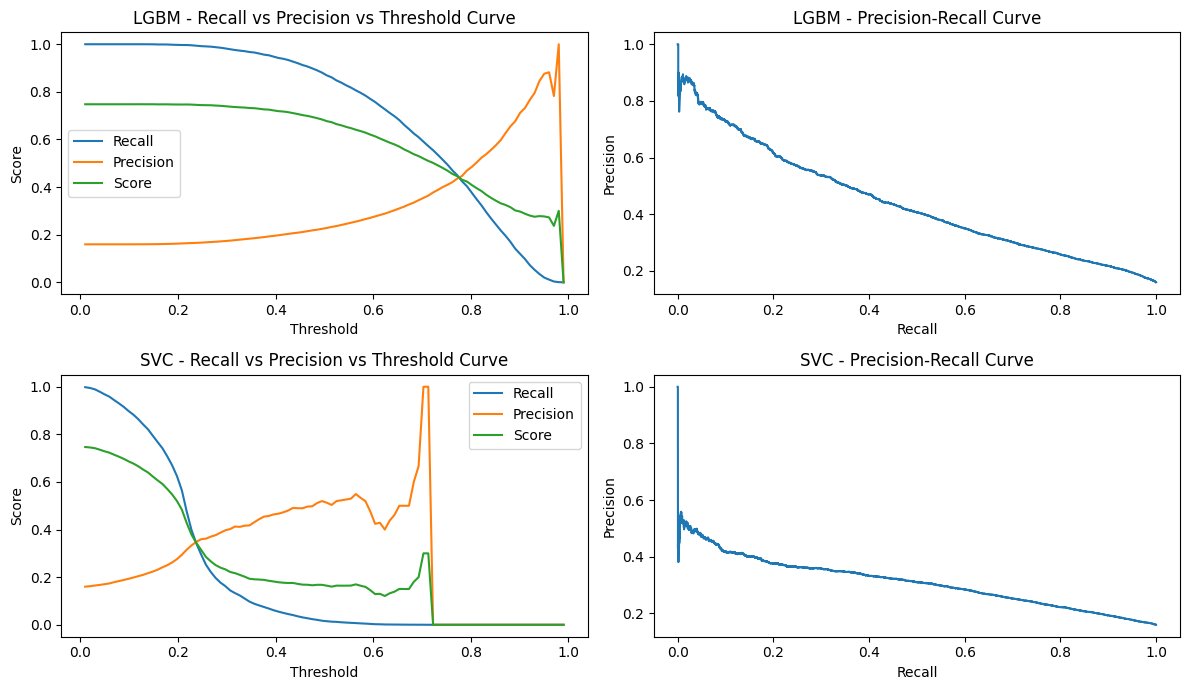

In [183]:
# 4. plot curvas de threshold 
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Threshold Curves LGBMClassifier
plot_threshold_curves(df_thresh_lgbm, "LGBM", ax=axes[0, 0])

# Precision Recall Curve LGBMClassifier
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_train, y_prob_lgbm)

axes[0, 1].plot(recall_lgbm, precision_lgbm, label="LGBM")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title("LGBM - Precision-Recall Curve")


# Threshold Curves SVC
plot_threshold_curves(df_thresh_svc, "SVC", ax=axes[1, 0])

# Precision Recall Curve SVC
precision_svc, recall_svc, _ = precision_recall_curve(y_train, y_prob_svc)

axes[1, 1].plot(recall_svc, precision_svc, label="SVC")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")
axes[1, 1].set_title("SVC - Precision-Recall Curve")

plt.tight_layout()
plt.show()

A análise das curvas de Recall vs Precision vs Threshold e Precision-Recall evidencia diferenças importantes no comportamento dos modelos LightGBM (LGBM) e Support Vector Classifier (SVC) no contexto de classificação desbalanceada para risco de crédito.

O LightGBM apresentou comportamento mais estável ao longo dos diferentes thresholds, mantendo melhor equilíbrio entre Recall e Precision. Observa-se uma redução gradual do Recall conforme o threshold aumenta, acompanhada por crescimento consistente da Precision, indicando maior robustez na separação entre adimplentes e inadimplentes. Além disso, a curva Precision-Recall do LGBM permaneceu superior durante praticamente todo o intervalo de Recall, evidenciando melhor capacidade discriminativa global e maior eficiência na identificação da classe minoritária.

O SVC, por outro lado, demonstrou elevada sensibilidade em thresholds baixos, porém com queda abrupta de Recall à medida que o limiar aumenta. Apesar de apresentar aumento de Precision em regiões específicas, o comportamento das curvas indica maior instabilidade preditiva e menor capacidade de manter equilíbrio entre identificação de inadimplentes e controle de falsos positivos. Esse comportamento também se reflete na curva Precision-Recall, que permaneceu inferior à do LGBM na maior parte do intervalo analisado.

De forma geral, os resultados reforçam o LightGBM como o modelo mais robusto para o problema de risco de crédito avaliado, apresentando melhor equilíbrio entre sensibilidade, precisão e capacidade discriminativa em cenários de classes desbalanceadas. O SVC demonstrou desempenho competitivo em determinados thresholds, mas com menor estabilidade operacional e menor consistência global em comparação ao LGBM.

- **Seleção de Thresholds**

In [184]:
# 5. escolha com regra LGBMClassifier
best_lgbm = choose_threshold_by_rule(
    df_thresh_lgbm,
    min_recall=0.85,
    min_precision=0.2
)

# 5. escolha com regra SVC
best_svc = choose_threshold_by_rule(
    df_thresh_svc,
    min_recall=0.85,
    min_precision=0.18
)

print("Melhor threshold LGBM:", best_lgbm)
print('='*40)
print("Melhor threshold SVC:", best_svc)



Melhor threshold LGBM: threshold   0.42
recall      0.94
precision   0.20
score       0.72
Name: 41, dtype: float64
Melhor threshold SVC: threshold   0.08
recall      0.93
precision   0.18
score       0.71
Name: 7, dtype: float64


## 9.6. Avaliação final dos modelos LGBM e SVC no conjunto de teste com e sem threshold tuning


Nesta etapa, é realizada a avaliação final dos modelos LightGBM (LGBM) e Support Vector Classifier (SVC) no conjunto de teste, utilizando tanto o threshold padrão de classificação quanto thresholds otimizados com foco na melhoria da capacidade de identificação da classe inadimplente. O objetivo dessa análise é de comparar o impacto do ajuste do limiar de decisão sobre as métricas de desempenho, especialmente em um cenário de classes desbalanceadas, no qual o threshold padrão de 0.5 nem sempre representa a melhor estratégia operacional. Além disso, a comparação entre os modelos antes e após o threshold tuning possibilita avaliar os ganhos efetivos de sensibilidade e capacidade discriminativa obtidos na etapa de otimização.

- **LGBMClassifier:**

In [185]:
# Treinar modelo LGBMClassifier no conjunto de treino completo
pipe_lgbm.fit(X_train_corr, y_train)     
print("Modelo treinado com sucesso!")                           

Modelo treinado com sucesso!


In [186]:
# Previsão final sem threshold customizado LGBMClassifier
y_pred_default_lgbm = pipe_lgbm.predict(X_test_corr)

In [187]:
# Previsão final com threshold LGBMClassifier
y_prob_test_lgbm = pipe_lgbm.predict_proba(X_test_corr)[:, 1]

y_pred_threshold_lgbm = (y_prob_test_lgbm >= best_lgbm['threshold']).astype(int)
y_pred_threshold_lgbm

array([1, 1, 1, ..., 1, 1, 1])

- **SVC:**

In [188]:
# Treinar modelo SVC no conjunto de treino completo
pipe_svc.fit(X_train_corr, y_train)
print("Modelo treinado com sucesso!")


Modelo treinado com sucesso!


In [189]:
# Previsão final sem threshold customizado
y_pred_default_svc = pipe_svc.predict(X_test_corr)
y_pred_default_svc

array([0, 1, 1, ..., 1, 0, 0])

In [190]:
# Previsão final com threshold
y_prob_test_svc = pipe_svc.predict_proba(X_test_corr)[:, 1]

y_pred_threshold_svc = (y_prob_test_svc >= best_svc['threshold']).astype(int)
y_pred_threshold_svc

array([0, 1, 1, ..., 1, 0, 1])

- **Resuldatos no conjunto de teste:**

In [191]:
# Resultados finais LGBMClassifier
print("     ==== LGBM - SEM TUNING DO THRESHOLD ====")
print(classification_report(y_test, y_pred_default_lgbm))
print("PR-AUC:", average_precision_score(y_test, y_pred_default_lgbm))

print('\n','=' * 55, '\n')

print("     ==== LGBM - COM TUNING DO THRESHOLD ====")
print(classification_report(y_test, y_pred_threshold_lgbm))
print("PR-AUC:", average_precision_score(y_test, y_pred_threshold_lgbm))

     ==== LGBM - SEM TUNING DO THRESHOLD ====
              precision    recall  f1-score   support

           0       0.94      0.44      0.60      7017
           1       0.22      0.84      0.35      1332

    accuracy                           0.50      8349
   macro avg       0.58      0.64      0.47      8349
weighted avg       0.82      0.50      0.56      8349

PR-AUC: 0.21148302542252573


     ==== LGBM - COM TUNING DO THRESHOLD ====
              precision    recall  f1-score   support

           0       0.95      0.29      0.45      7017
           1       0.20      0.91      0.32      1332

    accuracy                           0.39      8349
   macro avg       0.57      0.60      0.38      8349
weighted avg       0.83      0.39      0.43      8349

PR-AUC: 0.19320153258806955


In [192]:
# Resultados finais SVC
print("     ==== SVC - SEM TUNING DO THRESHOLD ====")
print(classification_report(y_test, y_pred_default_svc))
print("PR-AUC:", average_precision_score(y_test, y_pred_default_svc))
    
print('\n','=' * 55, '\n')

print("     ==== SVC - COM TUNING DO THRESHOLD ====")
print(classification_report(y_test, y_pred_threshold_svc))
print("PR-AUC:", average_precision_score(y_test, y_pred_threshold_svc))


     ==== SVC - SEM TUNING DO THRESHOLD ====
              precision    recall  f1-score   support

           0       0.93      0.36      0.52      7017
           1       0.20      0.85      0.33      1332

    accuracy                           0.44      8349
   macro avg       0.56      0.60      0.42      8349
weighted avg       0.81      0.44      0.49      8349

PR-AUC: 0.19480025085582742


     ==== SVC - COM TUNING DO THRESHOLD ====
              precision    recall  f1-score   support

           0       0.92      0.24      0.38      7017
           1       0.18      0.89      0.30      1332

    accuracy                           0.35      8349
   macro avg       0.55      0.57      0.34      8349
weighted avg       0.80      0.35      0.37      8349

PR-AUC: 0.18024127197874565


Os resultados demonstram que tanto o LightGBM (LGBM) quanto o SVC apresentaram elevada capacidade de identificação da classe inadimplente, alcançando valores de Recall superiores a 0.84 no conjunto de teste. Após o tuning do threshold, o LGBM alcançou um recall de 0,91,  elevando a detecção de inadimplentes a um patamar elevado, porém com redução da precisão para 0,20 e queda do PR-AUC de 0,211 para 0,193 — indicando que o ganho de recall foi obtido à custa de maior contaminação da classe positiva por falsos alarmes. 

Comparativamente, o LGBM apresentou desempenho superior e maior estabilidade em relação ao SVC (detectando 9 em cada 10 inadimplentes), mantendo melhores resultados em Precision, F1-Score e PR-AUC. Os resultados evidenciam o trade-off entre maximizar a detecção de inadimplentes e controlar o custo operacional associado aos falsos positivos.

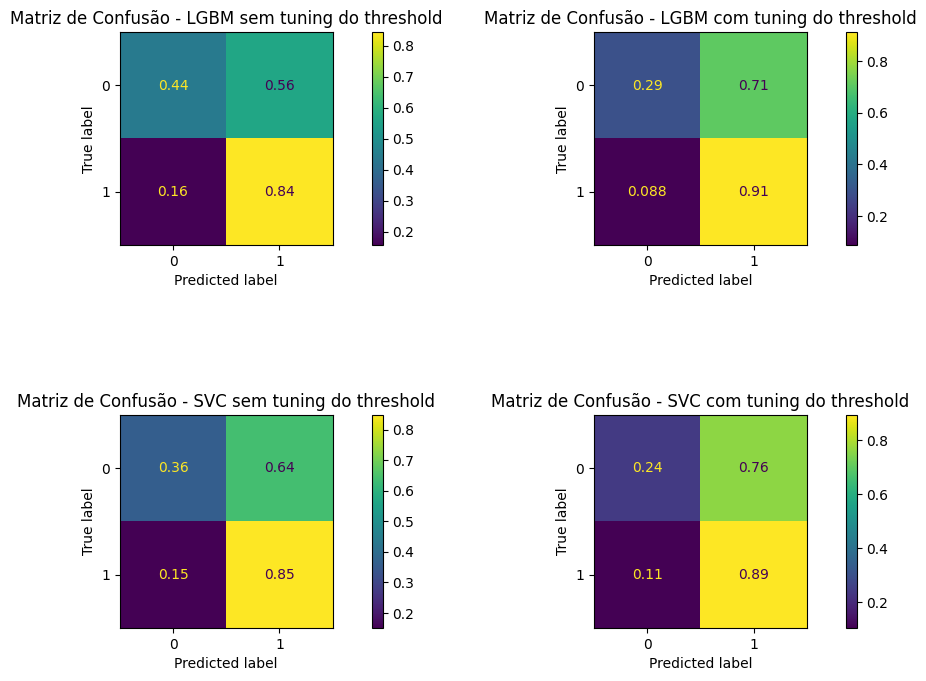

In [193]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Matriz de confusão sem tuning do threshold LGBMClassifier
cm_lgbm_sem_ts = confusion_matrix(y_test, y_pred_default_lgbm, normalize='true')
disp_lgbm_sem_ts = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm_sem_ts, display_labels=pipe_lgbm.classes_)
disp_lgbm_sem_ts.plot(ax=axes[0, 0])
axes[0, 0].set_title("Matriz de Confusão - LGBM sem tuning do threshold")

# Matriz de confusão com tuning do threshold LGBMClassifier
cm_lgbm_com_ts = confusion_matrix(y_test, y_pred_threshold_lgbm, normalize='true')
disp_lgbm_com_ts = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm_com_ts, display_labels=pipe_lgbm.classes_)
disp_lgbm_com_ts.plot(ax=axes[0, 1])
axes[0, 1].set_title("Matriz de Confusão - LGBM com tuning do threshold")



# Matriz de confusão sem tuning do threshold SVC
cm_svc_sem_ts = confusion_matrix(y_test, y_pred_default_svc, normalize='true')
disp_svc_sem_ts = ConfusionMatrixDisplay(confusion_matrix=cm_svc_sem_ts, display_labels=pipe_svc.classes_)
disp_svc_sem_ts.plot(ax=axes[1, 0])
axes[1, 0].set_title("Matriz de Confusão - SVC sem tuning do threshold")

# Matriz de confusão com tuning do threshold SVC
cm_svc_com_ts = confusion_matrix(y_test, y_pred_threshold_svc, normalize='true')
disp_svc_com_ts = ConfusionMatrixDisplay(confusion_matrix=cm_svc_com_ts, display_labels=pipe_svc.classes_)
disp_svc_com_ts.plot(ax=axes[1, 1])
axes[1, 1].set_title("Matriz de Confusão - SVC com tuning do threshold")


plt.tight_layout(pad=5, h_pad=7.5, w_pad=-15)
plt.show()

As matrizes de confusão reforçam que tanto o LightGBM (LGBM) quanto o SVC apresentaram elevada capacidade de identificação da classe inadimplente, mantendo Recall elevado em todos os cenários avaliados. Entretanto, o aumento do Recall obtido após o ajuste de threshold ocorreu acompanhado de crescimento significativo da taxa de falsos positivos, reduzindo consideravelmente a capacidade de identificação correta da classe adimplente. 

No LGBM sem tuning do threshold, o modelo apresentou um equilíbrio mais consistente entre detecção de inadimplentes e controle de falsos positivos, mantendo Recall de aproximadamente 84% para a classe de inadimplência e taxa de acerto de cerca de 44% para clientes adimplentes. Após o threshold tuning, embora o recall tenha aumentado para aproximadamente 91%, a taxa de falsos positivos cresceu de forma relevante, reduzindo a capacidade de aprovação correta de bons pagadores para cerca de 29%. Comportamento semelhante foi observado no SVC, porém com desempenho geral inferior ao LGBM, especialmente na identificação correta da classe majoritária e no equilíbrio operacional entre sensibilidade e precisão.

Considerando o conjunto das métricas avaliadas, o LightGBM sem ajuste agressivo de threshold apresentou o melhor equilíbrio entre capacidade preditiva, estabilidade e eficiência operacional para o problema de risco de crédito, sendo um modelo orientado à rentabilidade. Desta forma, a escolha por um modelo equilibrado é mais adequado em cenários de baixa inadimplência histórica, segmentos de clientes com perfil de risco conhecido ou estratégias de crescimento sustentado de carteira. Em contrapartida, o LightGBM com ajuste de threshold teve uma postura mais conservadora (maior recall), apresentando como uma estratégia de menor risco para a instituição. Modelos com recall mais elevado são, portanto, indicados em portfólios de maior exposição, produtos de ticket elevado ou períodos de maior incerteza macroeconômica.

Portanto, a escolha do threshold ideal deve, portanto, ser orientada pelo apetite de risco e pela função de custo da instituição, e não tratada como um aprimoramento do modelo em si.

# 10. Avaliação final


No contexto econômico brasileiro atual, caracterizado por elevados níveis de endividamento das famílias, taxas de juros ainda restritivas e aumento da pressão sobre a renda da população, torna-se estrategicamente justificável a priorização de modelos com maior recall na identificação da inadimplência. Em cenários macroeconômicos mais instáveis, o custo associado à aprovação de clientes inadimplentes tende a crescer significativamente, impactando diretamente indicadores como perda esperada, provisão para devedores duvidosos (PDD) e qualidade da carteira de crédito. Dessa forma, modelos com maior sensibilidade à classe inadimplente podem atuar como mecanismo mais conservador de mitigação de risco, reduzindo potenciais perdas financeiras em ambientes de maior deterioração do crédito. Sob essa perspectiva, aceitar aumento controlado da taxa de falsos positivos pode ser operacionalmente vantajoso, principalmente em segmentos de maior risco, crédito sem garantia ou carteiras com maior exposição à inadimplência.



Por outro lado, a adoção de modelos mais equilibrados entre recall e precision também possui forte fundamentação estratégica no cenário brasileiro atual. Apesar do aumento do risco de crédito, o mercado financeiro permanece altamente competitivo, com forte disputa por aquisição, retenção e rentabilização de clientes. Nesse contexto, taxas excessivamente elevadas de falsos positivos podem reduzir conversão comercial, limitar expansão da carteira e gerar perda de clientes potencialmente adimplentes para concorrentes. Além disso, políticas de crédito excessivamente restritivas podem impactar negativamente indicadores de crescimento, receita e experiência do cliente, especialmente em instituições com perfil moderado de apetite ao risco. Dessa forma, modelos mais equilibrados tendem a oferecer melhor relação entre mitigação de inadimplência e eficiência operacional, preservando capacidade de concessão sem comprometer de forma excessiva a qualidade da carteira.



Sob a ótica de negócio, ambas as abordagens são válidas e refletem estratégias distintas de concessão de crédito. Modelos orientados a maior recall favorecem uma política mais conservadora e defensiva em períodos de maior instabilidade econômica, enquanto modelos mais equilibrados priorizam sustentabilidade operacional, competitividade comercial e controle mais eficiente dos custos associados à rejeição indevida de bons pagadores. Dessa forma, a definição do threshold ótimo e da estratégia final de modelagem deve considerar não apenas métricas estatísticas, mas também fatores econômicos, regulatórios e estratégicos relacionados ao apetite ao risco e aos objetivos da instituição financeira.

### Simulando custos de decisão em um caso hipotético

In [194]:
# Calcular custo de decisão
def calculate_decision_cost(y_true, y_pred, cost_fp=1, cost_fn=10):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    total_cost = (fp * cost_fp) + (fn * cost_fn)

    return total_cost

In [195]:
print("Custo de decisão - LGBM sem tuning do threshold:", calculate_decision_cost(y_true = y_test, y_pred = y_pred_default_lgbm))
print("Custo de decisão - LGBM com tuning do threshold:", calculate_decision_cost(y_true = y_test, y_pred = y_pred_threshold_lgbm),'\n')

print('=' * 55,'\n')

print("Custo de decisão - SVC sem tuning do threshold:", calculate_decision_cost(y_true = y_test, y_pred = y_pred_default_svc))
print("Custo de decisão - SVC com tuning do threshold:", calculate_decision_cost(y_true = y_test, y_pred = y_pred_threshold_svc))

Custo de decisão - LGBM sem tuning do threshold: 6045
Custo de decisão - LGBM com tuning do threshold: 6140 


Custo de decisão - SVC sem tuning do threshold: 6509
Custo de decisão - SVC com tuning do threshold: 6743


Considerando uma relação de custo hipotética, porém aderente à prática de risco de crédito, na qual o custo de aprovar um cliente inadimplente (False Negative) foi definido como dez vezes superior ao custo de rejeitar um cliente adimplente (False Positive), o modelo LightGBM sem tuning agressivo de threshold apresentou o menor custo operacional total entre os cenários avaliados. Apesar de o ajuste de threshold ter aumentado o recall dos modelos — ampliando a capacidade de identificação da classe inadimplente —, observou-se crescimento significativo da quantidade de falsos positivos, elevando o custo total de decisão. No caso do LGBM, o custo aumentou de 6.045 para 6.140 após o threshold tuning, enquanto no SVC o custo passou de 6.509 para 6.743.

Esses resultados evidenciam, na prática, o trade-off entre maximizar a detecção de inadimplentes e preservar eficiência operacional da política de crédito. Embora modelos mais conservadores, com maior recall, sejam particularmente relevantes no contexto econômico brasileiro atual — marcado por elevado endividamento das famílias, juros restritivos e maior deterioração do risco de crédito —, o aumento excessivo da sensibilidade do modelo pode elevar substancialmente a rejeição de clientes potencialmente adimplentes. Sob a ótica estratégica, isso significa que políticas de crédito excessivamente agressivas podem reduzir conversão comercial, limitar crescimento da carteira e impactar negativamente a rentabilidade da operação. 

# 11. Conclusão

O desenvolvimento deste projeto evidenciou que a construção de modelos preditivos para análise de risco de crédito vai muito além da escolha de algoritmos de machine learning. Os resultados obtidos demonstraram que etapas como tratamento dos dados, engenharia de atributos, pré-processamento e definição adequada da estratégia de avaliação possuem impacto direto na capacidade de generalização e na qualidade preditiva dos modelos. 


Durante o projeto, foram aplicadas práticas fundamentais de data cleaning, incluindo tratamento de inconsistências, valores ausentes, ajuste de tipos de variáveis e mitigação de outliers, garantindo maior consistência estatística à base utilizada. Na etapa de feature engineering, técnicas como binning, Weight of Evidence (WOE), Information Value (IV) e criação de variáveis derivadas contribuíram para aumentar a representatividade dos atributos e melhorar a separação entre bons e maus pagadores. O pré-processamento dos dados, envolvendo padronização, transformações estatísticas e codificação de variáveis categóricas, foi essencial para adequar os dados aos diferentes algoritmos avaliados. Além disso, a comparação entre estratégias de seleção de atributos demonstrou que a redução de dimensionalidade baseada em correlação de Pearson foi capaz de preservar desempenho preditivo com menor complexidade, favorecendo estabilidade e interpretabilidade dos modelos. Na etapa de modelagem, a utilização de validação cruzada estratificada, métricas voltadas à classe minoritária, otimização de hiperparâmetros com Optuna e análise de threshold tuning permitiu avaliar de forma mais realista os impactos operacionais do modelo em cenários de crédito desbalanceado. Os experimentos também mostraram que o uso de SMOTE não gerou ganhos consistentes no problema analisado, reforçando que técnicas de balanceamento devem ser avaliadas de forma criteriosa e dependente do contexto dos dados. 

Entre os modelos avaliados, o LightGBM apresentou o melhor equilíbrio entre capacidade de identificação da inadimplência, estabilidade preditiva e custo operacional, demonstrando maior robustez frente aos diferentes cenários testados. Mesmo sem a utilização de um threshold mais agressivo, o modelo foi capaz de manter elevado poder de detecção da classe inadimplente, preservando simultaneamente melhor controle sobre falsos positivos e maior eficiência operacional. A análise dos thresholds evidenciou, ainda, a importância do trade-off entre recall e precision, especialmente em um contexto econômico desafiador, no qual decisões excessivamente conservadoras podem reduzir perdas com inadimplência, mas também aumentar significativamente a rejeição de bons clientes.

Como oportunidades futuras de evolução, o projeto pode ser aprimorado com novas abordagens de modelagem, estratégias adicionais de avaliação e melhorias relacionadas ao contexto de negócio e operacionalização dos modelos. Além disso, por se tratar de um problema complexo e amplamente explorado na área de risco de crédito, observações, sugestões e contribuições dos leitores e profissionais da área podem agregar novas perspectivas, auxiliar na identificação de pontos de melhoria e contribuir para a evolução contínua da solução proposta.

Por fim, além dos resultados técnicos alcançados, este projeto representou uma experiência extremamente enriquecedora em termos de aprendizado. O processo permitiu aprofundar conhecimentos em modelagem preditiva, engenharia de atributos, avaliação de modelos desbalanceados e interpretação de métricas aplicadas ao contexto de risco de crédito. Mais do que alcançar métricas elevadas, o projeto contribuiu para desenvolver uma visão mais crítica sobre o equilíbrio entre desempenho estatístico, viabilidade operacional e impacto de negócio em aplicações reais de ciência de dados.